The first few pieces of code are fundamental function used for simulation and CI calculations.

999 1225.125 1138 586 2059
999 1225.1196847987515 1138 586 2059
999 1099.7776305914645 1064 686 1585


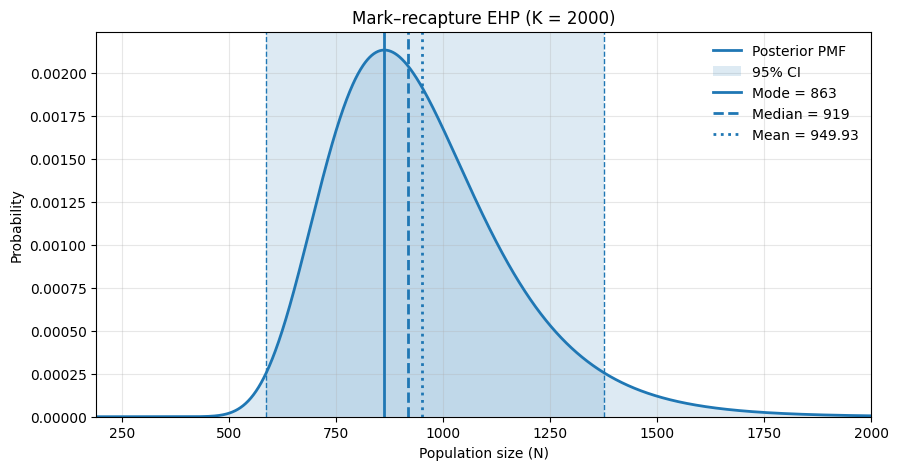

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Mark–recapture EHP (K = 2000)'}, xlabel='Population size (N)', ylabel='Probability'>)

In [ ]:
'''
ehpmarkrecap v 0.1.0
Mirzaee et al., Feb 2026
'''

import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln, logsumexp


# Helpers

def _log_comb_scalar(n: int, k: int) -> float:
    """log( n choose k ) for integers, returns -inf if invalid."""
    if k < 0 or k > n:
        return -np.inf
    return float(gammaln(n + 1) - gammaln(k + 1) - gammaln(n - k + 1))


def _log_comb_vec(n: np.ndarray, k: int) -> np.ndarray:
    """
    Vectorized log( n choose k ) for integer n-array and scalar k.
    Returns -inf where invalid.
    """
    n = np.asarray(n)
    out = np.full(n.shape, -np.inf, dtype=float)
    if k < 0:
        return out
    mask = n >= k
    if np.any(mask):
        nn = n[mask]
        out[mask] = gammaln(nn + 1) - gammaln(k + 1) - gammaln(nn - k + 1)
    return out


# Core MR likelihoods / posteriors

def _log_likelihood_hypergeom(domain: np.ndarray, m: int, C: int, r: int) -> np.ndarray:
    """
    log P(r | N) under the classic hypergeometric model:
      P(r | N) = C(m,r)*C(N-m, C-r) / C(N,C)
    """
    domain = np.asarray(domain, dtype=int)
    log_const = _log_comb_scalar(m, r)
    log_part1 = _log_comb_vec(domain - m, C - r)
    log_part2 = _log_comb_vec(domain, C)
    return log_const + log_part1 - log_part2


def _log_hypergeom_r(domain: np.ndarray, mt: int, C: int, r: int) -> np.ndarray:
    """log P(r | N, mt) where mt is the number of available marked individuals."""
    domain = np.asarray(domain, dtype=int)
    if r < 0 or r > min(mt, C):
        return np.full(domain.shape, -np.inf, dtype=float)
    log_num = _log_comb_scalar(mt, r) + _log_comb_vec(domain - mt, C - r)
    log_den = _log_comb_vec(domain, C)
    return log_num - log_den


def _log_fisher_nchypergeom_r(domain: np.ndarray, mt: int, C: int, r: int, omega: float) -> np.ndarray:
    """
    Fisher's noncentral hypergeometric log pmf:
      P(r | N, mt, C, omega) =
        [C(mt,r)*C(N-mt, C-r)*omega^r] / sum_j [C(mt,j)*C(N-mt, C-j)*omega^j]
    """
    domain = np.asarray(domain, dtype=int)
    if omega <= 0:
        raise ValueError("omega must be > 0")
    if r < 0 or r > min(mt, C):
        return np.full(domain.shape, -np.inf, dtype=float)

    logomega = math.log(omega)

    # numerator
    log_num = _log_comb_scalar(mt, r) + _log_comb_vec(domain - mt, C - r) + r * logomega

    # denominator via stable log-add
    jmax = min(mt, C)
    log_denom = np.full(domain.shape, -np.inf, dtype=float)

    # precompute log C(mt, j)
    logc_mt = [_log_comb_scalar(mt, j) for j in range(jmax + 1)]
    for j in range(jmax + 1):
        log_term = logc_mt[j] + _log_comb_vec(domain - mt, C - j) + j * logomega
        log_denom = np.logaddexp(log_denom, log_term)

    return log_num - log_denom


def _log_binom_pmf_all(m: int, phi: float):
    """Return mt array and log Binom(m,phi) pmf (already normalized)."""
    if not (0 <= phi <= 1):
        raise ValueError("phi must be between 0 and 1")

    mts = np.arange(0, m + 1, dtype=int)

    if phi == 0.0:
        logw = np.full(m + 1, -np.inf, dtype=float)
        logw[0] = 0.0
        return mts, logw

    if phi == 1.0:
        logw = np.full(m + 1, -np.inf, dtype=float)
        logw[m] = 0.0
        return mts, logw

    log_phi = math.log(phi)
    log_1mphi = math.log(1 - phi)

    logw = np.array(
        [_log_comb_scalar(m, mt) + mt * log_phi + (m - mt) * log_1mphi for mt in mts],
        dtype=float,
    )
    return mts, logw


def _log_likelihood_dataset(
    domain: np.ndarray,
    m: int, C: int, r: int,
    phi: float = 1.0,
    omega: float = 1.0,
    mt_tail_cutoff: float = 1e-12,
) -> np.ndarray:
    """
    log L(N; r, m, C, phi, omega):
      Mt ~ Binomial(m, phi)
      r | (N, Mt) ~ Fisher noncentral hypergeometric with odds omega
      L(N) = sum_mt Binom(m,mt;phi) * P(r | N, mt, C, omega)
    """
    domain = np.asarray(domain, dtype=int)

    # mt support
    if phi == 1.0:
        mt_values = [m]
        logw_values = [0.0]
    else:
        mts, logw_all = _log_binom_pmf_all(m, phi)

        if mt_tail_cutoff is None or mt_tail_cutoff <= 0:
            mask = np.ones_like(mts, dtype=bool)
        else:
            mask = logw_all >= math.log(mt_tail_cutoff)
            if not np.any(mask):
                mask[np.argmax(logw_all)] = True  # keep at least one term

        mt_values = mts[mask].tolist()
        logw_values = logw_all[mask].tolist()

    # mixture sum in log space
    logL = np.full(domain.shape, -np.inf, dtype=float)
    for mt, logw in zip(mt_values, logw_values):
        if omega == 1.0:
            logpr = _log_hypergeom_r(domain, mt, C, r)
        else:
            logpr = _log_fisher_nchypergeom_r(domain, mt, C, r, omega)
        logL = np.logaddexp(logL, logw + logpr)

    return logL


# Unbounded (K = infinity) exact posterior

def _log_pmf_unbounded(domain: np.ndarray, m: int, C: int, r: int) -> np.ndarray:
    """
    Unbounded posterior P(N | r) using the closed-form normalization:
      Z = sum_{N=Nmin..inf} P(r|N) = m*C / (r*(r-1)), valid for r>1
    """
    if r <= 1:
        raise ValueError("Unbounded model requires r>1 for proper normalization.")
    domain = np.asarray(domain, dtype=int)
    log_unnorm = _log_likelihood_hypergeom(domain, m, C, r)
    Z = (m * C) / (r * (r - 1))
    return log_unnorm - math.log(Z)


def _find_mode_unbounded(m: int, C: int, r: int) -> int:
    """Find a mode by scanning from Nmin upwards until log-pmf stops increasing."""
    Nmin = m + C - r
    curN = Nmin
    cur_logp = _log_pmf_unbounded(np.array([curN]), m, C, r)[0]
    while True:
        nxtN = curN + 1
        nxt_logp = _log_pmf_unbounded(np.array([nxtN]), m, C, r)[0]
        if nxt_logp > cur_logp + 1e-15:
            curN, cur_logp = nxtN, nxt_logp
        else:
            break
    return curN


def _ci_mode_expand_unbounded(m: int, C: int, r: int, alpha: float = 0.05):
    """
    Greedy CI expansion starting at the mode (contiguous), in log space.
    """
    Nmin = m + C - r
    mode = _find_mode_unbounded(m, C, r)
    L = U = mode

    log_cum = _log_pmf_unbounded(np.array([mode]), m, C, r)[0]
    target = math.log(1 - alpha)

    while log_cum < target - 1e-15:
        log_pl = -np.inf
        if L > Nmin:
            log_pl = _log_pmf_unbounded(np.array([L - 1]), m, C, r)[0]
        log_pr = _log_pmf_unbounded(np.array([U + 1]), m, C, r)[0]

        if log_pl > log_pr:
            L -= 1
            log_cum = np.logaddexp(log_cum, log_pl)
        else:
            U += 1
            log_cum = np.logaddexp(log_cum, log_pr)

    return L, U, mode


def _median_unbounded(m: int, C: int, r: int) -> int:
    """Median from CDF accumulation in log space."""
    Nmin = m + C - r
    target = math.log(0.5)
    log_cum = -np.inf
    N = Nmin
    while True:
        logp = _log_pmf_unbounded(np.array([N]), m, C, r)[0]
        log_cum = np.logaddexp(log_cum, logp)
        if log_cum >= target - 1e-15:
            return N
        N += 1


# CI from a bounded pmf (mode expansion / HPD)

def _ci_mode_expand_from_pmf(domain: np.ndarray, pmf: np.ndarray, alpha: float = 0.05):
    """Contiguous, greedy CI expansion from the pmf array."""
    domain = np.asarray(domain)
    pmf = np.asarray(pmf)
    mode_idx = int(np.argmax(pmf))

    L = U = mode_idx
    cum = float(pmf[mode_idx])
    target = 1 - alpha

    while cum < target - 1e-15:
        pl = pmf[L - 1] if L > 0 else -1.0
        pr = pmf[U + 1] if U < len(pmf) - 1 else -1.0

        if pl > pr:
            L -= 1
            cum += float(pl)
        else:
            U += 1
            cum += float(pr)

        if L == 0 and U == len(pmf) - 1:
            break

    return int(domain[L]), int(domain[U])


def _ci_hpd_interval(domain: np.ndarray, pmf: np.ndarray, alpha: float = 0.05):
    """
    HPD-set interval: take highest pmf values until coverage (1-alpha),
    then return [min(selected), max(selected)].
    """
    idx = np.argsort(pmf)[::-1]
    cum = 0.0
    selected = []
    for i in idx:
        selected.append(int(domain[i]))
        cum += float(pmf[i])
        if cum >= 1 - alpha:
            break
    return min(selected), max(selected)



# Main

def ehp(
    data,
    K=False,
    phi=False,
    omega=False,
    alpha=0.05,
    ci_method="mode_expand",
    mt_tail_cutoff=1e-12,
):
    """
    Comprehensive MR inference function.

    Parameters
    ----------
    data : (m, C, r) OR list of (m, C, r)
    K : int or False/None
        Environmental capacity / upper bound on N.
        REQUIRED if:
          - multiple datasets are provided, OR
          - phi != 1 or omega != 1 (heterogeneity / loss model).
        If K is False/None, only the single-dataset classic model (phi=1, omega=1)
        is allowed, and uses the exact unbounded normalization.
    phi : float or list[float] or False/None
        Retention/availability probability (0..1). False/None => 1.0
    omega : float or list[float] or False/None
        Relative catchability odds (>0). False/None => 1.0
    alpha : float
        CI tail probability (coverage is 1-alpha).
    ci_method : {"mode_expand", "hpd"}
        CI construction method for bounded distributions:
          - "mode_expand": contiguous greedy expansion around the mode
          - "hpd": HPD-set interval (min/max of top-mass set)
    mt_tail_cutoff : float
        Speed/accuracy knob for phi<1 models. Binomial(mt) terms with probability below
        this cutoff are dropped. Set to 0 for maximum accuracy.

    Returns
    -------
    dict with:
      mode, mean, median, ci_low, ci_high,
      plus: domain, pmf, np_values for plotting.
    """

    # --- parse datasets ---
    if isinstance(data, tuple) and len(data) == 3:
        data_sets = [tuple(int(x) for x in data)]
    else:
        data_sets = [tuple(int(x) for x in d) for d in data]

    for (m, C, r) in data_sets:
        if m < 0 or C < 0 or r < 0:
            raise ValueError("m, C, r must be non-negative integers.")
        if r > min(m, C):
            raise ValueError(f"r cannot exceed min(m,C). Got r={r}, m={m}, C={C}.")

    n = len(data_sets)

    # --- normalize phi/omega to per-dataset lists ---
    def _as_list(x, default):
        if x is False or x is None:
            return [default] * n
        if isinstance(x, (int, float, np.number)):
            return [float(x)] * n
        if isinstance(x, (list, tuple, np.ndarray)):
            if len(x) != n:
                raise ValueError(f"Expected a scalar or a list of length {n}.")
            return [float(v) for v in x]
        raise ValueError("phi/omega must be False/None, a scalar, or a list/tuple.")

    phi_list = _as_list(phi, 1.0)
    omega_list = _as_list(omega, 1.0)

    heterogeneity = any(abs(p - 1.0) > 0 for p in phi_list) or any(abs(w - 1.0) > 0 for w in omega_list)

    # --- normalize K ---
    K_val = None if (K is False or K is None) else int(K)

    # Rule
    if (n > 1 or heterogeneity) and K_val is None:
        raise ValueError("K must be provided (finite) for multiple datasets and/or when phi or omega are used.")

    # Unbounded exact case
    if K_val is None:
        (m, C, r) = data_sets[0]
        if r <= 1:
            raise ValueError("Without K, r must be > 1 for CI/PMF normalization.")

        ci_low, ci_high, mode = _ci_mode_expand_unbounded(m, C, r, alpha=alpha)
        median = _median_unbounded(m, C, r)

        # expected value rule you requested (and matches Eq. 8 behavior)
        if r <= 2:
            mean = float("inf")
        else:
            mean = (m - 1) * (C - 1) / (r - 2)

        Nmin = m + C - r
        plot_max = int(2 * ci_high)
        domain = np.arange(Nmin, plot_max + 1, dtype=int)
        pmf = np.exp(_log_pmf_unbounded(domain, m, C, r))
        np_values = list(zip(domain.tolist(), pmf.tolist()))

        return {
            "mode": int(mode),
            "mean": float(mean),
            "median": int(median),
            "ci_low": int(ci_low),
            "ci_high": int(ci_high),
            "alpha": float(alpha),
            "K": None,
            "datasets": data_sets,
            "phi": phi_list,
            "omega": omega_list,
            "ci_method": ci_method,
            "domain": domain,
            "pmf": pmf,
            "np_values": np_values,
        }

    # Bounded (K provided) case
    Nmin = max(m + C - r for (m, C, r) in data_sets)
    if K_val < Nmin:
        raise ValueError(f"K must be >= Nmin={Nmin}. Got K={K_val}.")

    domain = np.arange(Nmin, K_val + 1, dtype=int)
    total_loglik = np.zeros(domain.shape, dtype=float)

    for (m, C, r), ph, om in zip(data_sets, phi_list, omega_list):
        if not (0 <= ph <= 1):
            raise ValueError(f"phi must be in [0,1]. Got {ph}.")
        if om <= 0:
            raise ValueError(f"omega must be > 0. Got {om}.")

        total_loglik += _log_likelihood_dataset(
            domain, m, C, r, phi=ph, omega=om, mt_tail_cutoff=mt_tail_cutoff
        )

    logZ = logsumexp(total_loglik)
    logpost = total_loglik - logZ
    pmf = np.exp(logpost)

    # summary stats
    mode = int(domain[int(np.argmax(pmf))])
    mean = float(np.dot(domain, pmf))
    median = int(domain[np.searchsorted(np.cumsum(pmf), 0.5)])

    ci_method_l = ci_method.lower()
    if ci_method_l in ("mode_expand", "expand", "greedy"):
        ci_low, ci_high = _ci_mode_expand_from_pmf(domain, pmf, alpha=alpha)
    elif ci_method_l in ("hpd", "hpd_set"):
        ci_low, ci_high = _ci_hpd_interval(domain, pmf, alpha=alpha)
    else:
        raise ValueError("ci_method must be 'mode_expand' or 'hpd'.")

    np_values = list(zip(domain.tolist(), pmf.tolist()))
    return {
        "mode": int(mode),
        "mean": float(mean),
        "median": int(median),
        "ci_low": int(ci_low),
        "ci_high": int(ci_high),
        "alpha": float(alpha),
        "K": int(K_val),
        "datasets": data_sets,
        "phi": phi_list,
        "omega": omega_list,
        "ci_method": ci_method,
        "domain": domain,
        "pmf": pmf,
        "np_values": np_values,
    }


def ehp_plot(results, ax=None, title=None, figsize=(10, 5), show=True):
    """
    Minimal professional plot for MR posterior values + Mode/Mean/Median/CI.

    Parameters
    ----------
    results : dict
        Output of Calc_MR(...)
    ax : matplotlib.axes.Axes or None
    title : str or None
    figsize : tuple
    show : bool

    Returns
    -------
    (fig, ax)
    """
    domain = np.asarray(results["domain"])
    pmf = np.asarray(results["pmf"])

    mode = results["mode"]
    mean = results["mean"]
    median = results["median"]
    ci_low = results["ci_low"]
    ci_high = results["ci_high"]
    alpha = results.get("alpha", None)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    ax.plot(domain, pmf, linewidth=2, label="Posterior PMF")
    ax.fill_between(domain, pmf, alpha=0.15)

    # CI shading
    if alpha is not None:
        ax.axvspan(ci_low, ci_high, alpha=0.15, label=f"{int(round((1-alpha)*100))}% CI")
    else:
        ax.axvspan(ci_low, ci_high, alpha=0.15, label="CI")

    # markers
    ax.axvline(mode, linestyle="-", linewidth=2, label=f"Mode = {mode}")
    ax.axvline(median, linestyle="--", linewidth=2, label=f"Median = {median}")
    if math.isfinite(mean):
        ax.axvline(mean, linestyle=":", linewidth=2, label=f"Mean = {mean:.2f}")
    else:
        ax.axvline(mode, linestyle=":", linewidth=2, label="Mean = ∞")

    ax.axvline(ci_low, linestyle="--", linewidth=1)
    ax.axvline(ci_high, linestyle="--", linewidth=1)

    ax.set_xlabel("Population size (N)")
    ax.set_ylabel("Probability")

    if title is None:
        if results.get("K", None) is None:
            title = "Mark–recapture EHP (unbounded)"
        else:
            title = f"Mark–recapture EHP (K = {results['K']})"
    ax.set_title(title)

    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)
    ax.set_xlim(domain[0], domain[-1])
    ax.set_ylim(bottom=0)

    if show:
        plt.show()

    return fig, ax

'''
# Example Usage ------------------------------
#Single"
m, C, r = 100, 100, 10
res = ehp((m, C, r), K=False, phi=False, omega=False, alpha=0.05)
print(res["mode"], res["mean"], res["median"], res["ci_low"], res["ci_high"])

#Single with K
res = ehp((100, 100, 10), K=10000, alpha=0.05)
print(res["mode"], res["mean"], res["median"], res["ci_low"], res["ci_high"])

#Multiple
data_sets = [(100, 100, 10), (100, 100, 10)]
res = ehp(data_sets, K=10000, alpha=0.05)
print(res["mode"], res["mean"], res["median"], res["ci_low"], res["ci_high"])

# With Hetrogeneity
# phi only
res_phi = ehp((20, 20, 5), K=3000, phi=0.5, omega=False, alpha=0.05)
# omega only
res_om = ehp((20, 20, 5), K=3000, phi=False, omega=2.0, alpha=0.05)
# both
res_both = ehp((20, 20, 5), K=3000, phi=0.7, omega=1.5, alpha=0.05)
# multiple
res_multi = ehp(data_sets, K=3000, phi=0.9, omega=1.1, alpha=0.05)
#Per-dataset phi/omega"
res = ehp(data_sets, K=2000, phi=[0.9, 0.8], omega=[1.0, 1.2], alpha=0.05)

# Adjusting Other Inputs
res = ehp(data_sets, K=2000, phi=0.8, omega=1.1, alpha=0.05, ci_method="hpd", mt_tail_cutoff=0)

# Visulaizing
ehp_plot(res)
'''

In [ ]:
# Simulation
import math
from typing import Dict, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt


# Helpers

def _build_log_factorials(n_max: int) -> np.ndarray:
    """logfac[i] = log(i!) for i=0..n_max."""
    logfac = np.zeros(n_max + 1, dtype=np.float64)
    if n_max >= 1:
        logfac[1:] = np.cumsum(np.log(np.arange(1, n_max + 1, dtype=np.float64)))
    return logfac


def _logsumexp(logw: np.ndarray) -> float:
    m = float(np.max(logw))
    return m + float(np.log(np.sum(np.exp(logw - m))))


def _log_choose(logfac: np.ndarray, n: int, k: np.ndarray) -> np.ndarray:
    """Vectorized log(n choose k), assumes k is valid (0<=k<=n)."""
    return logfac[n] - logfac[k] - logfac[n - k]


def _fisher_nch_pmf(
    mt: int,
    N: int,
    C: int,
    omega: float,
    logfac: np.ndarray
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Fisher's noncentral hypergeometric for r:
      P(r | N, mt, C, ω) ∝ comb(mt,r) * comb(N-mt, C-r) * ω^r
    with r in [max(0, C-(N-mt)), min(mt,C)].
    """
    if C > N:
        raise ValueError("C cannot exceed N.")
    if omega <= 0:
        raise ValueError("omega must be > 0.")
    r_min = max(0, C - (N - mt))
    r_max = min(mt, C)
    rs = np.arange(r_min, r_max + 1, dtype=np.int32)
    if rs.size == 0:
        return rs, np.array([], dtype=np.float64)

    logomega = math.log(omega)
    logw = (
        _log_choose(logfac, mt, rs) +
        _log_choose(logfac, N - mt, C - rs) +
        rs * logomega
    )
    logw -= _logsumexp(logw)
    probs = np.exp(logw)
    probs /= probs.sum()  # numerical cleanup
    return rs, probs


# 1) Simulation: r values for each N

def simulate_r_values(
    N_min: int,
    K: int,
    m: int,
    C: int,
    phi: float,
    omega: float,
    Simulations: int,
    Seed: Optional[int] = None,
) -> Dict[int, np.ndarray]:
    """
    Simulate recapture counts r for each candidate N in [N_min, K].

    Model:
      Mt ~ Binomial(m, phi)
      r | (N, Mt=mt, C, omega) ~ Fisher's noncentral hypergeometric (or standard hypergeometric if omega=1)

    Returns:
      dict: {N: np.ndarray of length Simulations containing simulated r values}
    """
    # Basic validation
    if N_min > K:
        raise ValueError("N_min must be <= K.")
    if N_min < max(m, C):
        raise ValueError("For feasibility, require N_min >= max(m, C).")
    if not (0.0 <= phi <= 1.0):
        raise ValueError("phi must be in [0, 1].")
    if omega <= 0.0:
        raise ValueError("omega must be > 0.")
    if Simulations <= 0:
        raise ValueError("Simulations must be positive.")

    rng = np.random.default_rng(Seed)

    # Precompute log-factorials up to K for fast log-choose
    logfac = _build_log_factorials(K)

    out: Dict[int, np.ndarray] = {}
    r_dtype = np.int16 if min(m, C) < 32767 else np.int32

    for N in range(N_min, K + 1):
        if m > N or C > N:
            continue  # infeasible N (shouldn't happen if N_min >= max(m,C))

        # Step 1: number of marked individuals still available at recapture
        if phi == 1.0:
            mt_vec = np.full(Simulations, m, dtype=np.int32)
        elif phi == 0.0:
            mt_vec = np.zeros(Simulations, dtype=np.int32)
        else:
            mt_vec = rng.binomial(m, phi, size=Simulations).astype(np.int32)

        # Group by mt to avoid recomputing pmfs many times
        unique_mt, counts = np.unique(mt_vec, return_counts=True)

        r_vals = np.empty(Simulations, dtype=r_dtype)
        pos = 0

        # Cache pmfs for this N (keyed by mt)
        pmf_cache: Dict[int, Tuple[np.ndarray, np.ndarray]] = {}

        for mt, cnt in zip(unique_mt, counts):
            if cnt == 0:
                continue

            if mt == 0:
                draws = np.zeros(cnt, dtype=r_dtype)

            else:
                # Fast path: omega==1 => standard hypergeometric
                if omega == 1.0:
                    draws = rng.hypergeometric(
                        ngood=int(mt),
                        nbad=int(N - mt),
                        nsample=int(C),
                        size=int(cnt),
                    ).astype(r_dtype)

                else:
                    # Fisher noncentral hypergeometric via pmf + multinomial sampling of counts
                    if mt not in pmf_cache:
                        rs, probs = _fisher_nch_pmf(mt=int(mt), N=int(N), C=int(C), omega=float(omega), logfac=logfac)
                        pmf_cache[mt] = (rs, probs)
                    rs, probs = pmf_cache[mt]

                    # Sample cnt draws efficiently by sampling counts-per-r
                    r_counts = rng.multinomial(int(cnt), probs)
                    draws = np.repeat(rs, r_counts).astype(r_dtype)

            r_vals[pos:pos + cnt] = draws
            pos += cnt

        rng.shuffle(r_vals)  # optional: remove grouping artifacts
        out[N] = r_vals

    return out


# 2) Process: normalized probability of seeing a specific r across N

def normalized_probabilities_for_r(
    r_by_N: Dict[int, np.ndarray],
    r_target: int
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    For each N:
      p_hat(N) = (# times r_target appears in simulations for N) / Simulations

    Then normalize across all N:
      p_norm(N) = p_hat(N) / sum_N p_hat(N)

    Returns:
      Ns      : array of N values
      p_norm  : normalized probabilities (sum to 1 across Ns)
      p_hat   : raw Monte-Carlo estimates of P(r_target | N)
    """
    Ns = np.array(sorted(r_by_N.keys()), dtype=np.int32)
    if Ns.size == 0:
        return Ns, np.array([], dtype=np.float64), np.array([], dtype=np.float64)

    sims = np.array([len(r_by_N[int(N)]) for N in Ns], dtype=np.int32)
    if not np.all(sims == sims[0]):
        raise ValueError("All N must have the same number of simulations.")
    S = int(sims[0])

    counts = np.array([(r_by_N[int(N)] == r_target).sum() for N in Ns], dtype=np.float64)
    p_hat = counts / S

    denom = p_hat.sum()
    p_norm = p_hat / denom if denom > 0 else np.zeros_like(p_hat)

    return Ns, p_norm, p_hat


# Example usage

if __name__ == "__main__":
    r_sims = simulate_r_values(
        N_min=120, K=300,
        m=20, C=20,
        phi=0.9, omega=1.2,
        Simulations=20000,
        Seed=42
    )

    Ns, p_norm, p_hat = normalized_probabilities_for_r(r_sims, r_target=5)


In [ ]:
# Established Methods
"""
Established Mark–recapture (MR) estimators + confidence intervals (CIs)

Covers 6 “doable + essential” categories:

1) Single MR point estimates (m, C, r)
   - Lincoln–Petersen (LP) MLE
   - Chapman (bias-corrected LP)

2) Single MR CIs (m, C, r)
   - Chapman log-normal CI (variance-based)
   - Exact hypergeometric inversion CI (frequentist equal-tail)

3) Multiple MR / combined-PDF point estimates (arrays of m, C, r)
   - Schnabel (classical repeated MR; assumes sequential marking design)
   - Schumacher–Eschmeyer (classical repeated MR; sequential marking design)

4) Multiple MR / combined-PDF CIs
   - Schnabel Poisson (Garwood / chi-square) CI
   - Schumacher–Eschmeyer t-CI on 1/N

5) Single MR with heterogeneity point estimates (m, C, r, omega[, K])
   - Chao lower bound (2-source; no omega needed, but standard heterogeneity-robust comparator)
   - MLE for N under Fisher noncentral hypergeometric (omega)

6) Single MR with heterogeneity CIs
   - Chao normal CI (variance-based)
   - Profile likelihood CI for N under Fisher NCHG (omega)
"""

from __future__ import annotations
import math
from dataclasses import dataclass
from typing import Optional, Sequence, Tuple
import numpy as np
from scipy.special import gammaln, logsumexp
from scipy.stats import chi2, hypergeom, norm, t


# Utilities

def _validate_single(m: int, C: int, r: int) -> None:
    for name, val in [("m", m), ("C", C), ("r", r)]:
        if not (isinstance(val, int) and val >= 0):
            raise ValueError(f"{name} must be a nonnegative integer.")
    if r > m or r > C:
        raise ValueError("Require r <= min(m, C).")


def _validate_multiple(ms: Sequence[int], Cs: Sequence[int], rs: Sequence[int]) -> None:
    if not (len(ms) == len(Cs) == len(rs)):
        raise ValueError("ms, Cs, rs must have the same length.")
    if len(ms) == 0:
        raise ValueError("Need at least one MR event / occasion.")
    for i, (m, C, r) in enumerate(zip(ms, Cs, rs)):
        try:
            _validate_single(int(m), int(C), int(r))
        except Exception as e:
            raise ValueError(f"Invalid counts at index {i}: {e}") from e


def _log_choose(n: int, k: int) -> float:
    """log(n choose k) using gammaln; returns -inf if invalid."""
    if k < 0 or k > n:
        return -math.inf
    return float(gammaln(n + 1) - gammaln(k + 1) - gammaln(n - k + 1))


def _log_binom_pmf(k: int, n: int, p: float) -> float:
    if p < 0 or p > 1:
        return -math.inf
    if k < 0 or k > n:
        return -math.inf
    if p == 0.0:
        return 0.0 if k == 0 else -math.inf
    if p == 1.0:
        return 0.0 if k == n else -math.inf
    return _log_choose(n, k) + k * math.log(p) + (n - k) * math.log(1.0 - p)


def _shortest_credible_interval(domain: np.ndarray, pmf: np.ndarray, alpha: float = 0.05) -> Tuple[int, int]:
    """
    Greedy “shortest contiguous” credible interval builder.
    """
    idx_mode = int(np.argmax(pmf))
    i = j = idx_mode
    cum = float(pmf[idx_mode])
    target = 1.0 - alpha

    while cum < target:
        p_left = pmf[i - 1] if i > 0 else -1.0
        p_right = pmf[j + 1] if j < len(pmf) - 1 else -1.0

        if p_left < 0 and p_right < 0:
            break

        if p_left >= p_right:
            i -= 1
            cum += float(pmf[i])
        else:
            j += 1
            cum += float(pmf[j])

    return int(domain[i]), int(domain[j])


def _pmf_summaries(domain: np.ndarray, pmf: np.ndarray) -> Tuple[int, float, int]:
    idx_mode = int(np.argmax(pmf))
    mode = int(domain[idx_mode])
    mean = float(np.sum(domain * pmf))
    cdf = np.cumsum(pmf)
    median = int(domain[np.searchsorted(cdf, 0.5)])
    return mode, mean, median

# Likelihoods for r | N

def loglik_hypergeom(N: int, m: int, C: int, r: int) -> float:
    """
    log P(r | N,m,C) under standard hypergeometric model.
    R ~ Hypergeom(pop=N, marked=m, draws=C)
    """
    if r > m or r > C:
        return -math.inf
    if N < m or N < C:
        return -math.inf
    if C - r > N - m:
        return -math.inf
    return _log_choose(m, r) + _log_choose(N - m, C - r) - _log_choose(N, C)


def logpmf_fisher_nchypergeom(N: int, m: int, C: int, r: int, omega: float) -> float:
    """
    Fisher's noncentral hypergeometric pmf:
      P(r | N,m,C,omega) ∝ choose(m,r) choose(N-m, C-r) omega^r
      normalized by sum over feasible r.
    """
    if omega <= 0:
        raise ValueError("omega must be > 0.")
    if r > m or r > C:
        return -math.inf
    if N < m or N < C:
        return -math.inf
    if C - r > N - m:
        return -math.inf

    jmin = max(0, C - (N - m))
    jmax = min(m, C)

    log_omega = math.log(omega)
    logw = []
    for j in range(jmin, jmax + 1):
        if C - j > N - m:
            continue
        logw.append(_log_choose(m, j) + _log_choose(N - m, C - j) + j * log_omega)

    if not logw:
        return -math.inf

    logZ = float(logsumexp(logw))
    logr = _log_choose(m, r) + _log_choose(N - m, C - r) + r * log_omega
    return logr - logZ


def loglik_r_given_N(
    N: int,
    m: int,
    C: int,
    r: int,
    omega: float = 1.0,
    phi: float = 1.0,
    integrate_phi: bool = False,
) -> float:
    """
    General likelihood that matches your section 3.1 “option 1” structure:

      - omega: marked/unmarked sampling odds ratio (Fisher NCHG)
      - phi: marked retention/availability probability
      - integrate_phi:
          False: plug-in m_eff = round(m*phi)
          True : marginalize over M_t ~ Binomial(m, phi) and then r | (N, M_t) via (N)CHG

    If omega==1 and phi==1 this reduces to the standard hypergeometric likelihood.
    """
    if integrate_phi:
        terms = []
        for m_t in range(r, m + 1):  # must have at least r marked available
            if N < m_t:
                continue
            lb = _log_binom_pmf(m_t, m, phi)
            if omega == 1.0:
                lh = loglik_hypergeom(N, m_t, C, r)
            else:
                lh = logpmf_fisher_nchypergeom(N, m_t, C, r, omega)
            if math.isfinite(lb) and math.isfinite(lh):
                terms.append(lb + lh)
        return float(logsumexp(terms)) if terms else -math.inf

    # plug-in m_eff
    m_eff = int(round(m * phi))
    m_eff = min(max(m_eff, 0), m)
    if m_eff < r:
        return -math.inf
    return loglik_hypergeom(N, m_eff, C, r) if omega == 1.0 else logpmf_fisher_nchypergeom(N, m_eff, C, r, omega)


# Posterior over N (bounded by K)
@dataclass(frozen=True)
class PosteriorSummary:
    mode: int
    mean: float
    median: int
    ci: Tuple[int, int]
    domain_min: int
    domain_max: int


def posterior_over_N_single(
    m: int,
    C: int,
    r: int,
    K: int,
    *,
    omega: float = 1.0,
    phi: float = 1.0,
    integrate_phi: bool = False,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Posterior pmf for N on [N_min, K] with a uniform prior over that range:
      P(N | data) ∝ L(N)
    """
    _validate_single(m, C, r)
    N_min = m + C - r
    if K < N_min:
        raise ValueError(f"K must be >= N_min = m + C - r = {N_min}.")

    domain = np.arange(N_min, K + 1, dtype=int)
    logL = np.array(
        [loglik_r_given_N(int(N), m, C, r, omega=omega, phi=phi, integrate_phi=integrate_phi) for N in domain],
        dtype=float,
    )

    finite = np.isfinite(logL)
    if not np.any(finite):
        raise ValueError("All likelihood values are -inf; check inputs and omega/phi.")

    logL_max = float(np.max(logL[finite]))
    w = np.exp(logL - logL_max)
    w[~finite] = 0.0
    pmf = w / float(np.sum(w))
    return domain, pmf


def posterior_summary_single(
    m: int,
    C: int,
    r: int,
    K: int,
    *,
    alpha: float = 0.05,
    omega: float = 1.0,
    phi: float = 1.0,
    integrate_phi: bool = False,
) -> PosteriorSummary:
    domain, pmf = posterior_over_N_single(m, C, r, K, omega=omega, phi=phi, integrate_phi=integrate_phi)
    mode, mean, median = _pmf_summaries(domain, pmf)
    L, U = _shortest_credible_interval(domain, pmf, alpha=alpha)
    return PosteriorSummary(
        mode=mode, mean=mean, median=median, ci=(L, U),
        domain_min=int(domain[0]), domain_max=int(domain[-1])
    )



# (1) Single MR: point estimates
# 1.1
def lp_mle_point(m: int, C: int, r: int) -> float:
    """Lincoln–Petersen MLE: m*C/r (undefined when r=0)."""
    _validate_single(m, C, r)
    return math.inf if r == 0 else (m * C) / r

# 1.2
def chapman_point(m: int, C: int, r: int) -> float:
    """Chapman estimator: ((m+1)(C+1)/(r+1)) - 1."""
    _validate_single(m, C, r)
    return ((m + 1) * (C + 1) / (r + 1)) - 1


# (2) Single MR: CIs
# 2.1
def chapman_variance(m: int, C: int, r: int) -> float:
    """
    Approx variance of Chapman estimator:
      Var = ((m+1)(C+1)(m-r)(C-r)) / ((r+1)^2 (r+2))
    """
    _validate_single(m, C, r)
    return ((m + 1) * (C + 1) * (m - r) * (C - r)) / (((r + 1) ** 2) * (r + 2))


def chapman_log_ci(m: int, C: int, r: int, alpha: float = 0.05) -> Tuple[float, float]:
    """Log-normal CI built from Chapman variance (keeps bounds positive)."""
    Nhat = chapman_point(m, C, r)
    var = chapman_variance(m, C, r)
    if not math.isfinite(var) or var < 0 or Nhat <= 0:
        return (math.nan, math.nan)

    z = float(norm.ppf(1 - alpha / 2))
    se = math.sqrt(var)
    se_log = se / Nhat
    lower = Nhat * math.exp(-z * se_log)
    upper = Nhat * math.exp(z * se_log)

    # enforce feasibility
    N_min = m + C - r
    lower = max(lower, float(N_min))
    return lower, upper

# 2.2
def exact_hypergeom_ci(m: int, C: int, r: int, alpha: float = 0.05, K_max: Optional[int] = None) -> Tuple[int, float]:
    """
    Two-sided equal-tail exact CI for N by inversion of the hypergeometric distribution:
      R ~ Hypergeom(N, m, C)

    Returns (N_L, N_U). If r=0 and K_max is None, N_U is +inf.
    """
    _validate_single(m, C, r)
    N_min = m + C - r

    if r == 0:
        return int(N_min), (float(K_max) if K_max is not None else math.inf)

    # choose search ceiling
    if K_max is None:
        Nhat = chapman_point(m, C, r)
        K = max(N_min + 10, int(math.ceil(Nhat * 20 + 1000)))
        while hypergeom.sf(r - 1, K, m, C) > alpha / 2:
            K *= 2
            if K > 10_000_000:
                break
    else:
        K = int(K_max)

    def cdfN(N: int) -> float:
        return float(hypergeom.cdf(r, N, m, C))

    def sfN(N: int) -> float:
        return float(hypergeom.sf(r - 1, N, m, C))  # P(R >= r)

    # Lower: smallest N with CDF(r) >= alpha/2
    lo, hi = int(N_min), int(K)
    if cdfN(lo) >= alpha / 2:
        N_L = lo
    else:
        while hi < 10_000_000 and cdfN(hi) < alpha / 2:
            hi *= 2
        lo = int(N_min)
        while lo < hi:
            mid = (lo + hi) // 2
            if cdfN(mid) >= alpha / 2:
                hi = mid
            else:
                lo = mid + 1
        N_L = lo

    # Upper: largest N with SF >= alpha/2
    if K_max is not None:
        if sfN(K) >= alpha / 2:
            N_U = K
        else:
            lo, hi = N_L, K
            while lo < hi:
                mid = (lo + hi + 1) // 2
                if sfN(mid) >= alpha / 2:
                    lo = mid
                else:
                    hi = mid - 1
            N_U = lo
        return int(N_L), float(N_U)

    # unbounded case
    if sfN(K) >= alpha / 2:
        while K < 10_000_000 and sfN(K) >= alpha / 2:
            K *= 2
        if sfN(K) >= alpha / 2:
            return int(N_L), math.inf

    lo, hi = N_L, int(K)
    while lo < hi:
        mid = (lo + hi + 1) // 2
        if sfN(mid) >= alpha / 2:
            lo = mid
        else:
            hi = mid - 1
    return int(N_L), float(lo)



# (3) Multiple MR / combined-PDF: point estimates
# 3.1

def schnabel_point(ms: Sequence[int], Cs: Sequence[int], rs: Sequence[int], *, bias_correction: bool = False) -> float:
    """
    Schnabel estimate (sequential marking design):
      N_hat = sum(C_t M_t) / sum(R_t)  (or / (sum(R_t)+1) if bias_correction)
    """
    _validate_multiple(ms, Cs, rs)
    ms = np.asarray(ms, dtype=float)
    Cs = np.asarray(Cs, dtype=float)
    rs = np.asarray(rs, dtype=float)
    A = float(np.sum(ms * Cs))
    R = float(np.sum(rs))
    denom = (R + 1.0) if bias_correction else R
    return math.inf if denom <= 0 else (A / denom)

# 3.2
def schumacher_eschmeyer_point(ms: Sequence[int], Cs: Sequence[int], rs: Sequence[int]) -> float:
    """
    Schumacher–Eschmeyer estimate (sequential marking design):
      N_hat = sum(C_t M_t^2) / sum(R_t M_t)
    """
    _validate_multiple(ms, Cs, rs)
    ms = np.asarray(ms, dtype=float)
    Cs = np.asarray(Cs, dtype=float)
    rs = np.asarray(rs, dtype=float)
    num = float(np.sum(Cs * ms**2))
    den = float(np.sum(rs * ms))
    return math.inf if den <= 0 else (num / den)


# (4) Multiple MR / combined-PDF: CIs
# 4.1
def schnabel_poisson_ci(ms: Sequence[int], Cs: Sequence[int], rs: Sequence[int], alpha: float = 0.05) -> Tuple[float, float]:
    """
    Approx CI for Schnabel using Poisson approximation for total recaptures:
      R = sum(R_t) ~ Poisson(lambda),  lambda = A/N,  A = sum(C_t M_t)
    Garwood CI for lambda, then transform to N.
    """
    _validate_multiple(ms, Cs, rs)
    ms = np.asarray(ms, dtype=float)
    Cs = np.asarray(Cs, dtype=float)
    rs = np.asarray(rs, dtype=float)

    A = float(np.sum(ms * Cs))
    R = int(np.sum(rs))
    if A <= 0:
        raise ValueError("sum(C_t * M_t) must be positive.")

    lam_low = 0.0 if R == 0 else 0.5 * float(chi2.ppf(alpha / 2, 2 * R))
    lam_up = 0.5 * float(chi2.ppf(1 - alpha / 2, 2 * (R + 1)))

    N_low = A / lam_up if lam_up > 0 else math.inf
    N_up = (A / lam_low) if lam_low > 0 else math.inf
    return N_low, N_up

# 4.2
def schumacher_eschmeyer_t_ci(ms, Cs, rs, alpha=0.05):
    """
    Approx CI for Schumacher–Eschmeyer via t-interval on 1/N.

    Variance estimator on 1/N:
      Var(1/N_hat) = [ sum(R_t^2 / C_t) - (sum(R_t M_t))^2 / sum(C_t M_t^2) ] / (s-2)

    Then:
      1/N_hat ± t_{1-alpha/2, df=s-2} * sqrt(Var)
    invert to N.
    """
    _validate_multiple(ms, Cs, rs)
    s = len(ms)
    if s < 3:
        raise ValueError("Need at least 3 occasions for Schumacher–Eschmeyer t CI (df=s-2).")

    ms = np.asarray(ms, dtype=float)
    Cs = np.asarray(Cs, dtype=float)
    rs = np.asarray(rs, dtype=float)

    sum_nM2 = float(np.sum(Cs * ms**2))
    sum_mM  = float(np.sum(rs * ms))
    if sum_nM2 <= 0 or sum_mM <= 0:
        return (math.nan, math.inf)

    Nhat = sum_nM2 / sum_mM
    invN = 1.0 / Nhat

    # Weighted SSE for regression through origin
    term1 = float(np.sum((rs**2) / Cs))                 # sum(m^2 / n)
    term2 = (sum_mM ** 2) / sum_nM2
    SSE = term1 - term2

    df = s - 2
    if SSE <= 0:
        # perfect fit (or numerical tie) => zero SE
        return (Nhat, Nhat)

    var_invN = (SSE / df) / sum_nM2
    se_invN = math.sqrt(var_invN)

    tcrit = float(t.ppf(1 - alpha / 2, df=df))
    lo_inv = invN - tcrit * se_invN
    hi_inv = invN + tcrit * se_invN
    lo_inv, hi_inv = min(lo_inv, hi_inv), max(lo_inv, hi_inv)

    if hi_inv <= 0:
        return (math.nan, math.inf)

    N_low = 1.0 / hi_inv
    N_up = math.inf if lo_inv <= 0 else 1.0 / lo_inv
    return N_low, N_up


# (5) Single MR with heterogeneity: point estimates
# 5.1
def chao_point_two_sample(m: int, C: int, r: int) -> float:
    """
    Chao lower bound (two-source) in terms of f1, f2:
      f1 = (m-r) + (C-r) = m + C - 2r
      f2 = r
      n  = observed = m + C - r
      N_hat = n + f1^2 / (4 f2)
    """
    _validate_single(m, C, r)
    if r == 0:
        return math.inf
    f1 = m + C - 2 * r
    n = m + C - r
    return n + (f1 * f1) / (4.0 * r)

# 5.2
def nchypergeom_mle_point(m: int, C: int, r: int, omega: float, K: int, *, phi: float = 1.0, integrate_phi: bool = False) -> int:
    """
    MLE for N under Fisher noncentral hypergeometric likelihood (omega),
    optionally with retention phi (plug-in or integrated).
    """
    _validate_single(m, C, r)
    N_min = m + C - r
    if K < N_min:
        raise ValueError(f"K must be >= N_min = {N_min}.")

    domain = np.arange(N_min, K + 1, dtype=int)
    logL = np.array([loglik_r_given_N(int(N), m, C, r, omega=omega, phi=phi, integrate_phi=integrate_phi) for N in domain])
    if not np.any(np.isfinite(logL)):
        raise ValueError("All likelihood values are -inf; check omega/phi.")
    return int(domain[int(np.argmax(logL))])

# 5.3
def posterior_point_hetero(m: int, C: int, r: int, omega: float, K: int, *, phi: float = 1.0, integrate_phi: bool = False) -> Tuple[int, float, int]:
    """
    Posterior (mode, mean, median) for N under Fisher NCHG (omega),
    optionally with retention phi.
    """
    summ = posterior_summary_single(m, C, r, K, alpha=0.05, omega=omega, phi=phi, integrate_phi=integrate_phi)
    return summ.mode, summ.mean, summ.median


# (6) Single MR with heterogeneity: CIs
# 6.1
def chao_normal_ci_two_sample(m: int, C: int, r: int, alpha: float = 0.05) -> Tuple[float, float]:
    """
    Normal CI for Chao using variance estimator:
      Var(N_hat) = (f1^2/(4 f2)) * (f1/(2 f2) + 1)^2
    """
    _validate_single(m, C, r)
    if r == 0:
        return (float(m + C - r), math.inf)

    f1 = m + C - 2 * r
    f2 = r
    Nhat = chao_point_two_sample(m, C, r)
    var = (f1 * f1) / (4.0 * f2) * ((f1 / (2.0 * f2) + 1.0) ** 2)

    z = float(norm.ppf(1 - alpha / 2))
    se = math.sqrt(max(var, 0.0))
    lower = max(float(m + C - r), Nhat - z * se)
    upper = Nhat + z * se
    return lower, upper

# 6.2
def nchypergeom_profile_ci(m: int, C: int, r: int, omega: float, K: int, alpha: float = 0.05, *, phi: float = 1.0, integrate_phi: bool = False) -> Tuple[int, int]:
    """
    Likelihood-ratio CI for N under Fisher NCHG likelihood (omega):
      2*(logL_max - logL(N)) <= chi2_{1,1-alpha}.
    Domain is [N_min, K].
    """
    _validate_single(m, C, r)
    N_min = m + C - r
    if K < N_min:
        raise ValueError(f"K must be >= N_min = {N_min}.")

    domain = np.arange(N_min, K + 1, dtype=int)
    logL = np.array([loglik_r_given_N(int(N), m, C, r, omega=omega, phi=phi, integrate_phi=integrate_phi) for N in domain])
    finite = np.isfinite(logL)
    if not np.any(finite):
        raise ValueError("All likelihood values are -inf; check omega/phi.")

    logL_max = float(np.max(logL[finite]))
    cutoff = logL_max - 0.5 * float(chi2.ppf(1 - alpha, df=1))
    ok = logL >= cutoff
    Ns = domain[ok]
    return int(Ns[0]), int(Ns[-1])


def posterior_ci_hetero(m: int, C: int, r: int, omega: float, K: int, alpha: float = 0.05, *, phi: float = 1.0, integrate_phi: bool = False) -> Tuple[int, int]:
    """Shortest (1-alpha) posterior credible interval for N under Fisher NCHG likelihood (omega)."""
    summ = posterior_summary_single(m, C, r, K, alpha=alpha, omega=omega, phi=phi, integrate_phi=integrate_phi)
    return summ.ci



# Example quick run
if __name__ == "__main__":
    m, C, r = 50, 40, 10
    K = 2000

    print("Single MR points:")
    print("  LP MLE:", lp_mle_point(m, C, r))
    print("  Chapman:", chapman_point(m, C, r))

    print("\nSingle MR CIs:")
    print("  Chapman log CI:", chapman_log_ci(m, C, r))
    print("  Exact hypergeom CI:", exact_hypergeom_ci(m, C, r))

    ms, Cs, rs = [10, 20, 30, 40], [15, 15, 15, 15], [1, 2, 3, 4]
    print("\nMultiple MR points:")
    print("  Schnabel:", schnabel_point(ms, Cs, rs))
    print("  Schumacher–Eschmeyer:", schumacher_eschmeyer_point(ms, Cs, rs))

    print("\nMultiple MR CIs:")
    print("  Schnabel Poisson CI:", schnabel_poisson_ci(ms, Cs, rs))
    print("  Schumacher–Eschmeyer t CI:", schumacher_eschmeyer_t_ci(ms, Cs, rs))

    omega = 1.2
    print("\nSingle MR with heterogeneity:")
    print("  Chao:", chao_point_two_sample(m, C, r))
    print("  NCHG MLE:", nchypergeom_mle_point(m, C, r, omega, K))

    print("\nSingle MR with heterogeneity CIs:")
    print("  Chao normal CI:", chao_normal_ci_two_sample(m, C, r))
    print("  NCHG profile CI:", nchypergeom_profile_ci(m, C, r, omega, K))

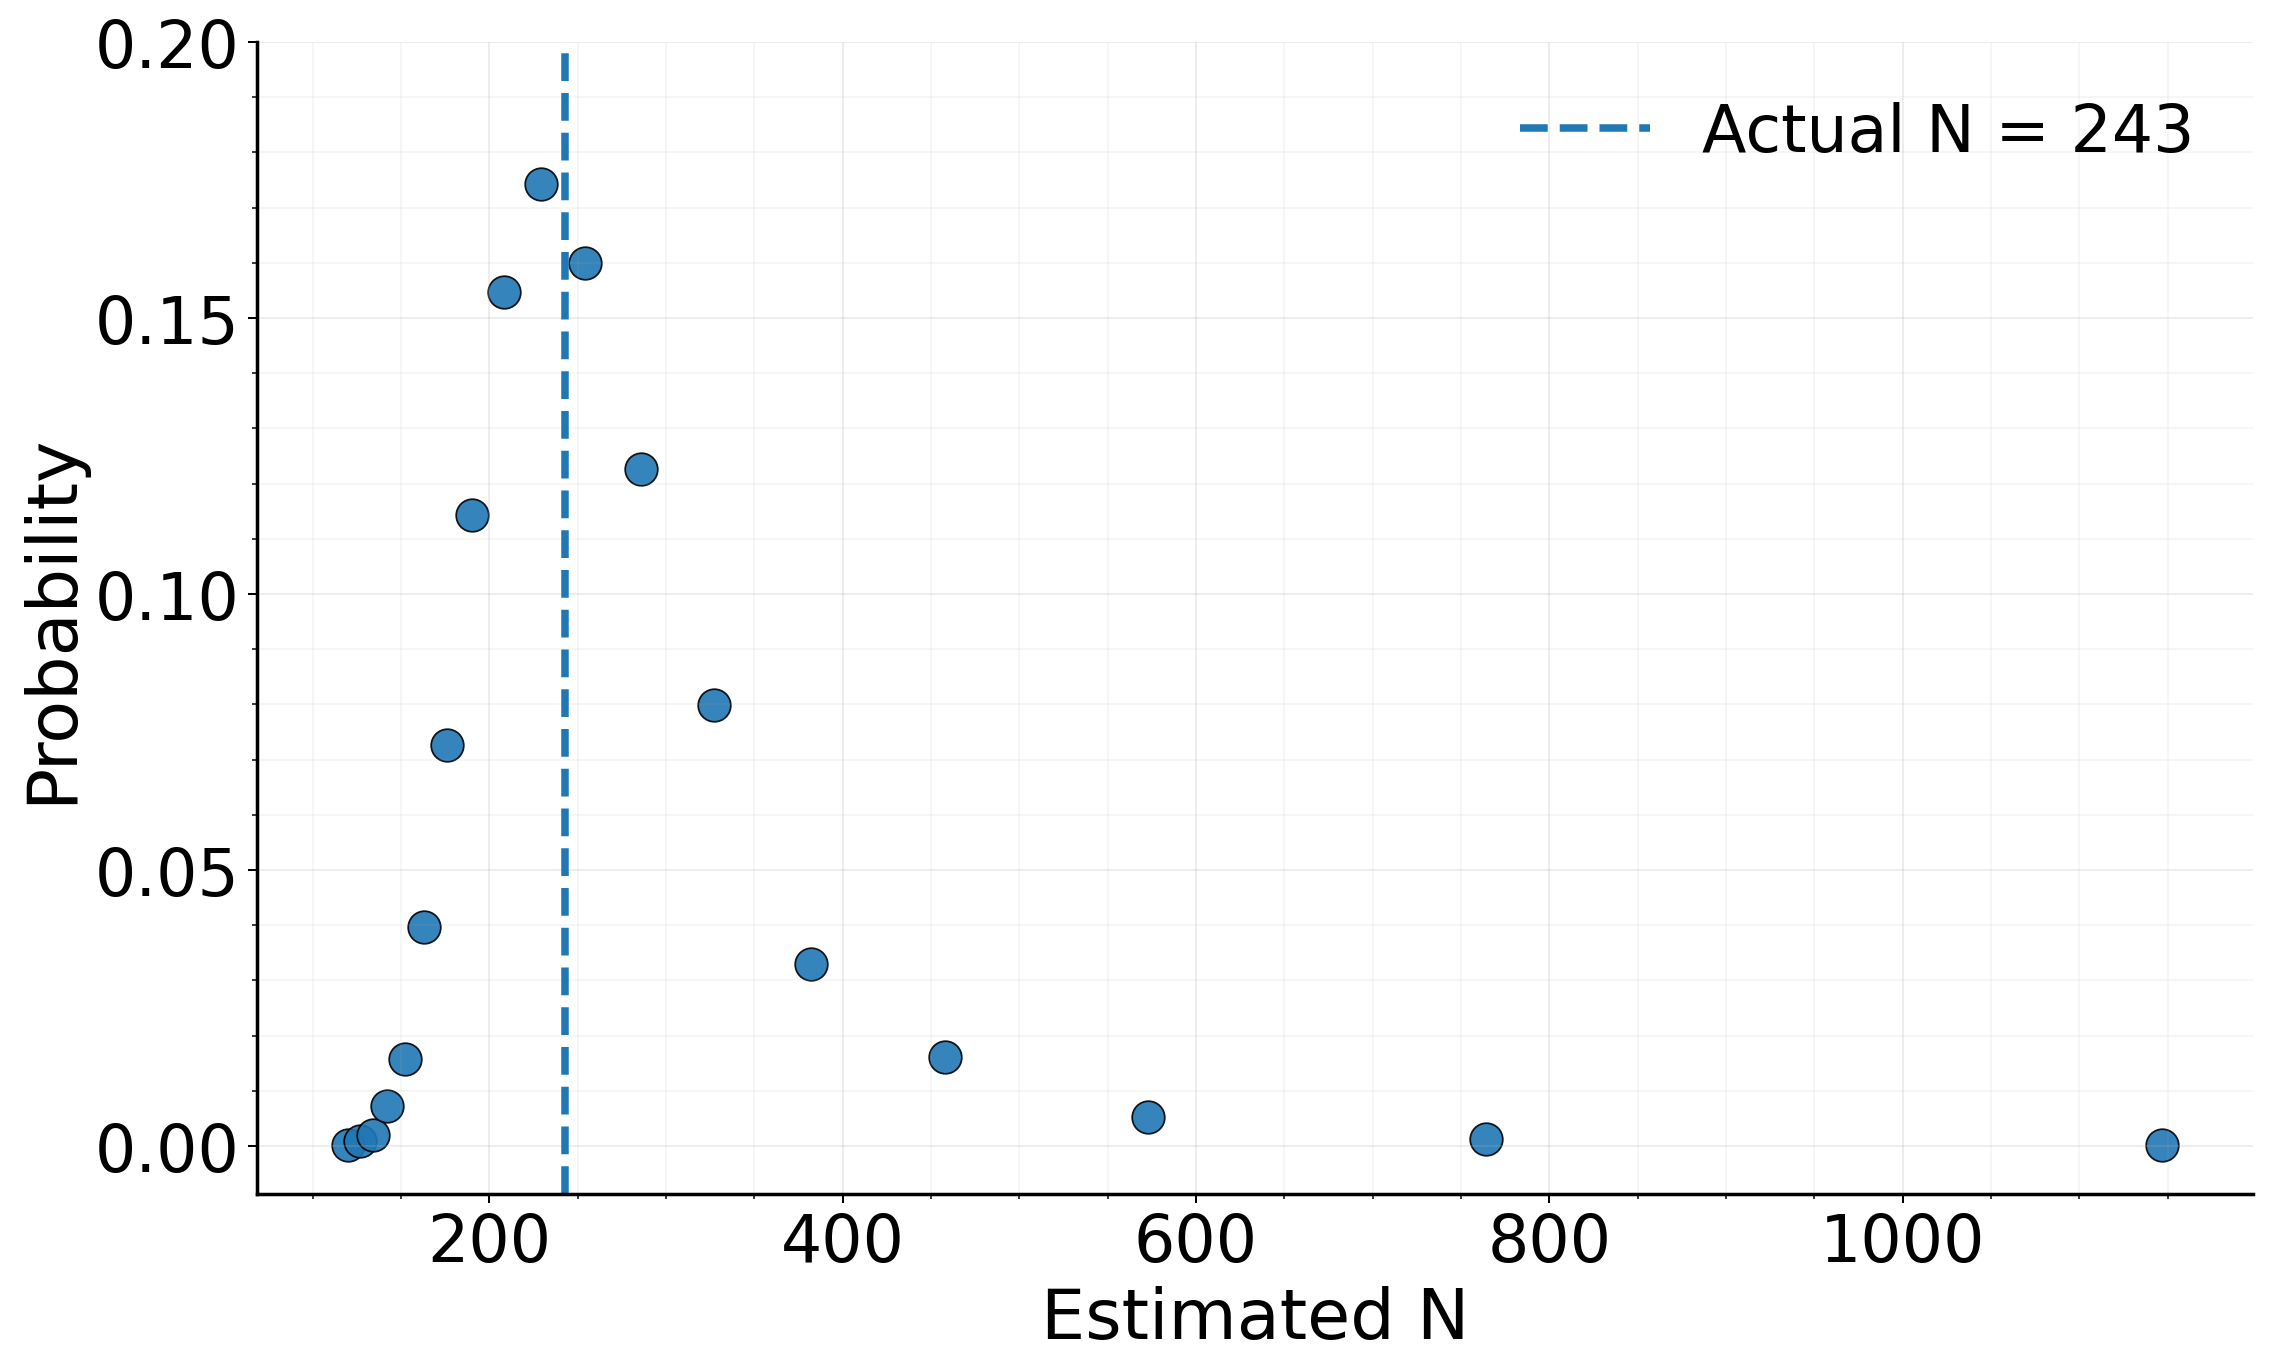

Successful estimates: 10000 of 10000
Mean estimate: 242.76
Median estimate: 228.60
95% Confidence Interval: [152.07, 381.67]


In [8]:
# Figure 1-A — Mark–recapture simulation with Known N

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter


def simulate_mark_recapture(
    population_size: int = 243,
    trials: int = 10_000,
    first_capture: int = 81,
    second_capture: int = 27,
    confidence: float = 0.95,
    seed: int | None = None
) -> tuple[np.ndarray, tuple[float, float]]:
    # Reproducibility
    rng = np.random.default_rng(seed)

    # Run simulations and store only valid estimates (when matches > 0)
    estimates = []
    for _ in range(trials):
        marked = set(rng.choice(population_size, size=first_capture, replace=False))
        recaptured = set(rng.choice(population_size, size=second_capture, replace=False))
        matches = len(marked & recaptured)

        if matches > 0:
            # Chapman estimator (bias-reduced Lincoln–Petersen)
            estimate = ((first_capture + 1) * (second_capture + 1) / (matches + 1)) - 1
            estimates.append(estimate)

    estimates_array = np.array(estimates, dtype=float)

    # Confidence interval via percentiles
    lower_pct = (1 - confidence) / 2 * 100
    upper_pct = (confidence + (1 - confidence) / 2) * 100
    interval = tuple(np.percentile(estimates_array, [lower_pct, upper_pct]))

    # Discrete (rounded) probability mass for plotting
    distribution = Counter(np.round(estimates_array))
    x_vals = np.array(sorted(distribution), dtype=float)
    y_vals = np.array([distribution[x] for x in x_vals], dtype=float)
    y_vals /= y_vals.sum()

    # ---------------------------
    # Plot styling (panel-friendly)
    # ---------------------------
    plt.rcParams.update({
        "figure.dpi": 180,
        "savefig.dpi": 300,
        "font.size": 22,
        "axes.titlesize": 28,
        "axes.labelsize": 28,
        "xtick.labelsize": 26,
        "ytick.labelsize": 26,
        "legend.fontsize": 26,
        "axes.linewidth": 1.4,
        "lines.linewidth": 2.8,
    })

    fig, ax = plt.subplots(figsize=(12.5, 7.5), constrained_layout=True)

    # Scatter of the empirical PMF (rounded estimates)
    ax.scatter(
        x_vals,
        y_vals,
        s=170,
        alpha=0.90,
        edgecolors="black",
        linewidths=0.7
    )

    # Reference line for the true population size
    ax.axvline(
        x=population_size,
        linestyle="--",
        linewidth=3.0,
        label=f"Actual N = {population_size}"
    )

    ax.set_xlabel("Estimated N")
    ax.set_ylabel("Probability")

    # Force y-axis ticks only
    ax.set_yticks([0, 0.05, 0.1, 0.15, 0.2])

    # Clean, professional look
    ax.grid(True, which="major", alpha=0.22)
    ax.grid(True, which="minor", alpha=0.10)
    ax.minorticks_on()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(frameon=False, loc="best")

    plt.show()
    return estimates_array, interval


if __name__ == "__main__":
    ACTUAL_N = 243
    TRIALS = 10_000
    FIRST_CAPTURE = 81
    SECOND_CAPTURE = 27
    CONF_LEVEL = 0.95
    SEED = 42

    estimates, conf_int = simulate_mark_recapture(
        population_size=ACTUAL_N,
        trials=TRIALS,
        first_capture=FIRST_CAPTURE,
        second_capture=SECOND_CAPTURE,
        confidence=CONF_LEVEL,
        seed=SEED
    )

    print(f"Successful estimates: {len(estimates)} of {TRIALS}")
    print(f"Mean estimate: {np.mean(estimates):.2f}")
    print(f"Median estimate: {np.median(estimates):.2f}")
    print(f"{int(CONF_LEVEL * 100)}% Confidence Interval: [{conf_int[0]:.2f}, {conf_int[1]:.2f}]")


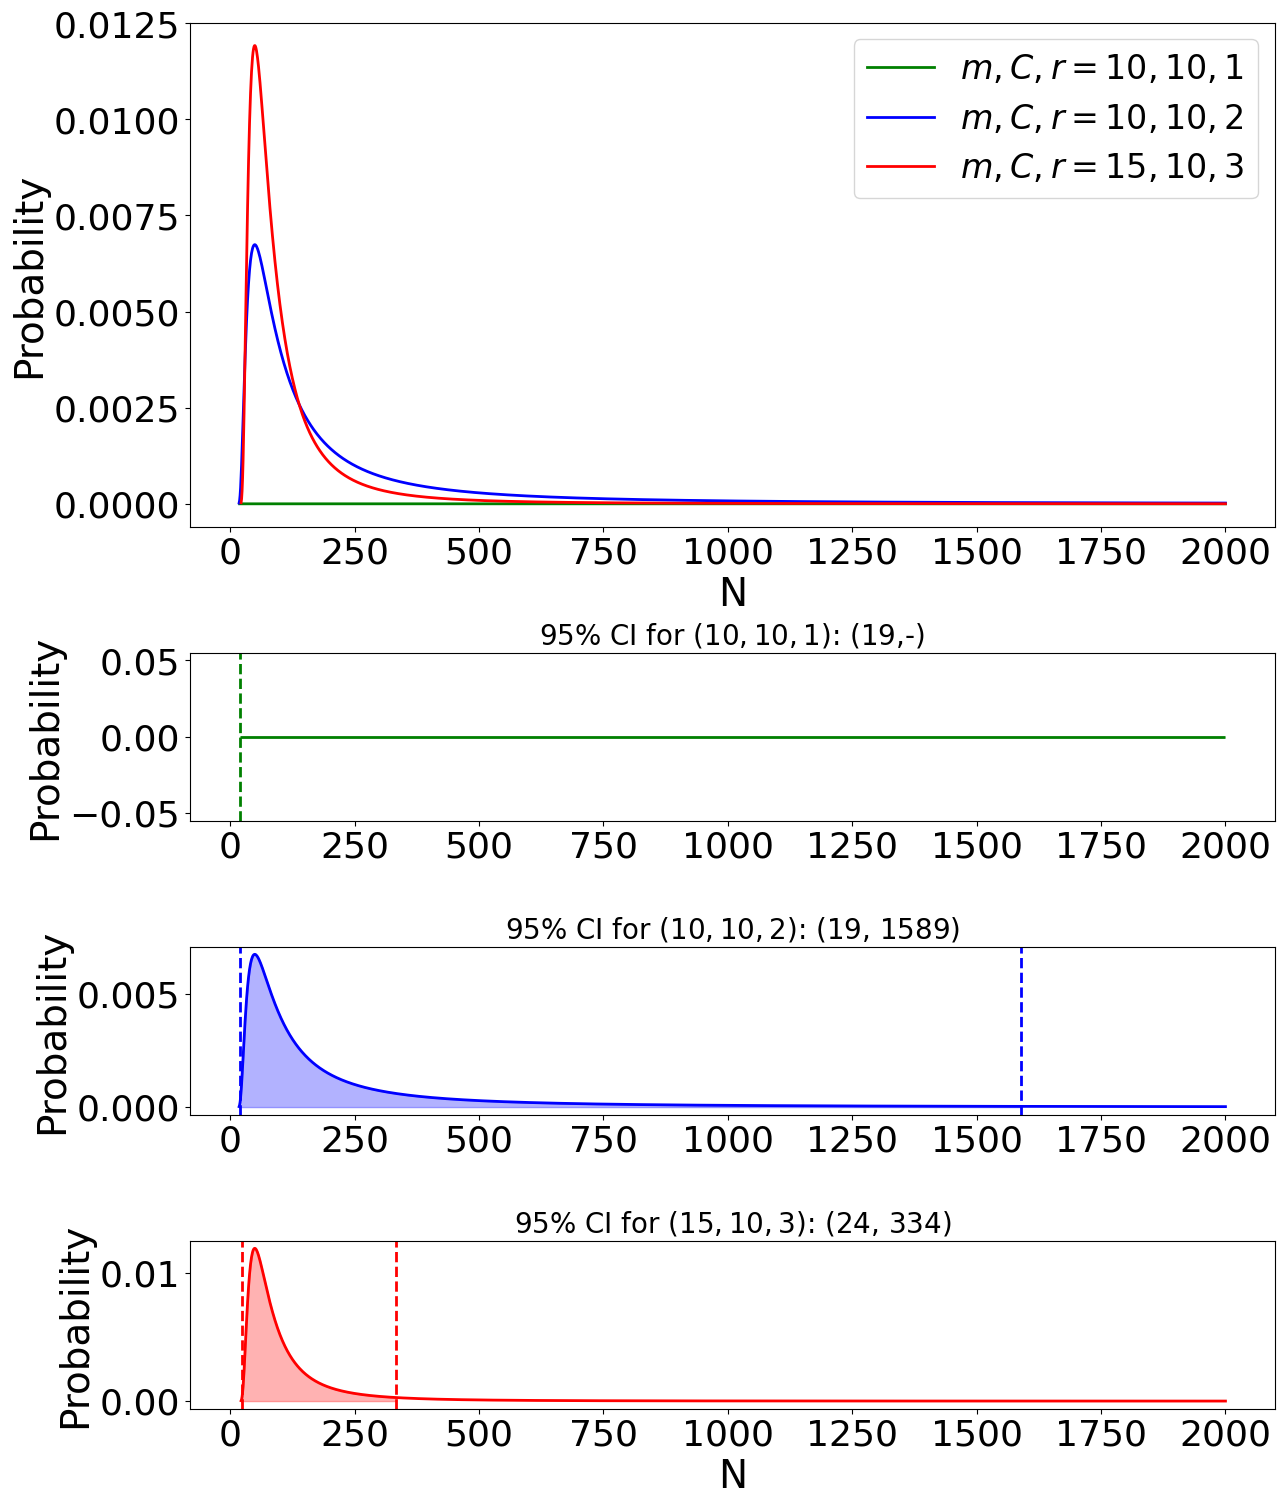

In [ ]:
# Figure 1-B - Comparison of PMFs
import matplotlib.pyplot as plt
from scipy.special import comb
import numpy as np
import matplotlib.gridspec as gridspec
from ehpmarkrecap import ehp

LABEL_FONT_SIZE = 28
TICK_FONT_SIZE = 26
TITLE_FONT_SIZE = 20
LEGEND_FONT_SIZE = 24
LINE_WIDTH = 2

m_1, C_1, r_1 = 10, 10, 1
N_range_1 = range(19, 2001)
expected_probabilities_1 = [0 for _ in N_range_1]

m_2, C_2, r_2 = 10, 10, 2
N_range_2 = range(18, 2001)
expected_probabilities_2 = [
    comb(m_2, r_2) * comb(N - m_2, C_2 - r_2) / comb(N, C_2) / (m_2 * C_2 / (r_2 * (r_2 - 1)))
    for N in N_range_2
]

m_3, C_3, r_3 = 15, 10, 3
N_range_3 = range(22, 2001)
expected_probabilities_3 = [
    comb(m_3, r_3) * comb(N - m_3, C_3 - r_3) / comb(N, C_3) / (m_3 * C_3 / (r_3 * (r_3 - 1)))
    for N in N_range_3
]

res2= ehp((m_2, C_2, r_2))
res3= ehp((m_3, C_3, r_3))

CI_1 = (19, np.inf)
CI_2 = (res2["ci_low"], res2["ci_high"])
CI_3 = (res3["ci_low"], res3["ci_high"])

color_r1, color_r2, color_r3 = 'green', 'blue', 'red'

fig = plt.figure(figsize=(14, 18))
gs = gridspec.GridSpec(4, 1, height_ratios=[3, 1, 1, 1], hspace=0.5)

ax_main = plt.subplot(gs[0])
ax_main.plot(N_range_1, expected_probabilities_1, color=color_r1, label="$m,C,r=10,10,1$", linewidth=LINE_WIDTH)
ax_main.plot(N_range_2, expected_probabilities_2, color=color_r2, label="$m,C,r=10,10,2$", linewidth=LINE_WIDTH)
ax_main.plot(N_range_3, expected_probabilities_3, color=color_r3, label="$m,C,r=15,10,3$", linewidth=LINE_WIDTH)
ax_main.set_xlabel("N", fontsize=LABEL_FONT_SIZE)
ax_main.set_ylabel("Probability", fontsize=LABEL_FONT_SIZE)
ax_main.tick_params(axis='both', which='major', labelsize=TICK_FONT_SIZE)
ax_main.legend(fontsize=LEGEND_FONT_SIZE)
ax_main.grid(False)

ax1 = plt.subplot(gs[1], sharex=ax_main)
ax1.hlines(0, CI_1[0], 2000, colors=color_r1, linestyles='-', label="r=1 CI", linewidth=LINE_WIDTH)
ax1.fill_betweenx([0, 0.0], CI_1[0], 2000, color=color_r1, alpha=0.3)
ax1.axvline(x=19, color=color_r1, linestyle='--', linewidth=LINE_WIDTH)
ax1.set_ylabel("Probability", fontsize=LABEL_FONT_SIZE)
ax1.set_title("95% CI for ($10,10,1$): (19,-)", fontsize=TITLE_FONT_SIZE)
ax1.tick_params(axis='both', which='major', labelsize=TICK_FONT_SIZE)
ax1.grid(False)

ax2 = plt.subplot(gs[2], sharex=ax_main)
ax2.plot(N_range_2, expected_probabilities_2, color=color_r2, linewidth=LINE_WIDTH)
ax2.fill_between(N_range_2, expected_probabilities_2,
                 where=((np.array(N_range_2) >= CI_2[0]) & (np.array(N_range_2) <= CI_2[1])),
                 color=color_r2, alpha=0.3)
ax2.axvline(x=CI_2[0], color=color_r2, linestyle='--', linewidth=LINE_WIDTH)
ax2.axvline(x=CI_2[1], color=color_r2, linestyle='--', linewidth=LINE_WIDTH)
ax2.set_ylabel("Probability", fontsize=LABEL_FONT_SIZE)
ax2.set_title(f"95% CI for ($10,10,2$): {CI_2}", fontsize=TITLE_FONT_SIZE)
ax2.tick_params(axis='both', which='major', labelsize=TICK_FONT_SIZE)
ax2.grid(False)

ax3 = plt.subplot(gs[3], sharex=ax_main)
ax3.plot(N_range_3, expected_probabilities_3, color=color_r3, linewidth=LINE_WIDTH)
ax3.fill_between(N_range_3, expected_probabilities_3,
                 where=((np.array(N_range_3) >= CI_3[0]) & (np.array(N_range_3) <= CI_3[1])),
                 color=color_r3, alpha=0.3)
ax3.axvline(x=CI_3[0], color=color_r3, linestyle='--', linewidth=LINE_WIDTH)
ax3.axvline(x=CI_3[1], color=color_r3, linestyle='--', linewidth=LINE_WIDTH)
ax3.set_ylabel("Probability", fontsize=LABEL_FONT_SIZE)
ax3.set_xlabel("N", fontsize=LABEL_FONT_SIZE)
ax3.set_title(f"95% CI for ($15,10,3$): {CI_3}", fontsize=TITLE_FONT_SIZE)
ax3.tick_params(axis='both', which='major', labelsize=TICK_FONT_SIZE)
ax3.grid(False)

plt.show()


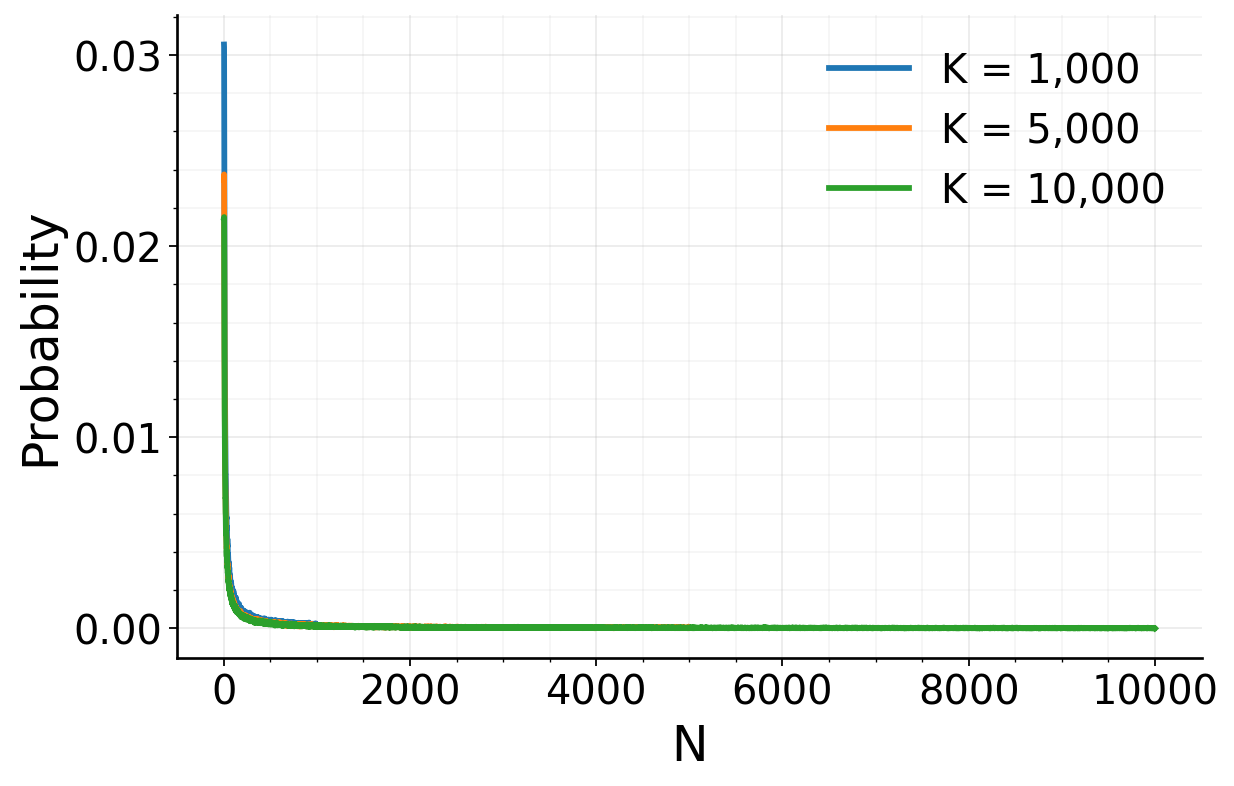

In [ ]:
# Figure 1-C - Simulation trend with r=1

import matplotlib.pyplot as plt

from Simulation import simulate_r_values, normalized_probabilities_for_r


def compute_curve_for_K(K: int, *, m: int, C: int, r_target: int, simulations: int, seed: int):
    """
    Returns (Ns, p_norm) for a given K using the provided simulation utilities.
    Assumptions (reasonable defaults unless you specify otherwise):
    """
    N_min = 3
    phi = 1.0
    omega = 1.0

    r_by_N = simulate_r_values(
        N_min=N_min,
        K=K,
        m=m,
        C=C,
        phi=phi,
        omega=omega,
        Simulations=simulations,
        Seed=seed,
    )

    Ns, p_norm, _p_hat = normalized_probabilities_for_r(r_by_N, r_target=r_target)
    return Ns, p_norm


def main():
    # Parameters requested
    m, C, r_target = 2, 2, 1
    simulations = 10000

    # Different seeds per curve for independence
    cases = [
        {"K": 1000, "seed": 1001, "label": "K = 1,000"},
        {"K": 5000, "seed": 1002, "label": "K = 5,000"},
        {"K": 10000, "seed": 1003, "label": "K = 10,000"},
    ]

    plt.rcParams.update({
        "figure.dpi": 160,
        "savefig.dpi": 300,
        "font.size": 20,
        "axes.titlesize": 22,
        "axes.labelsize": 22,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 18,
        "axes.linewidth": 1.2,
        "lines.linewidth": 2.6,
        "lines.markersize": 4.5,
    })

    fig, ax = plt.subplots(figsize=(7.6, 4.8), constrained_layout=True)

    for case in cases:
        Ns, p_norm = compute_curve_for_K(
            case["K"],
            m=m,
            C=C,
            r_target=r_target,
            simulations=simulations,
            seed=case["seed"],
        )
        ax.plot(Ns, p_norm, label=case["label"])

    #ax.set_title(f"Normalized probability across N for r = {r_target}  (m = {m}, C = {C})")
    ax.set_xlabel("N")
    ax.set_ylabel("Probability")

    # Force 4 y-axis ticks
    ax.set_yticks([0, 0.01, 0.02, 0.03])

    ax.grid(True, which="major", alpha=0.25)
    ax.grid(True, which="minor", alpha=0.12)
    ax.minorticks_on()

    # Clean spines for a professional look
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(frameon=False, loc="best")

    plt.show()


if __name__ == "__main__":
    main()


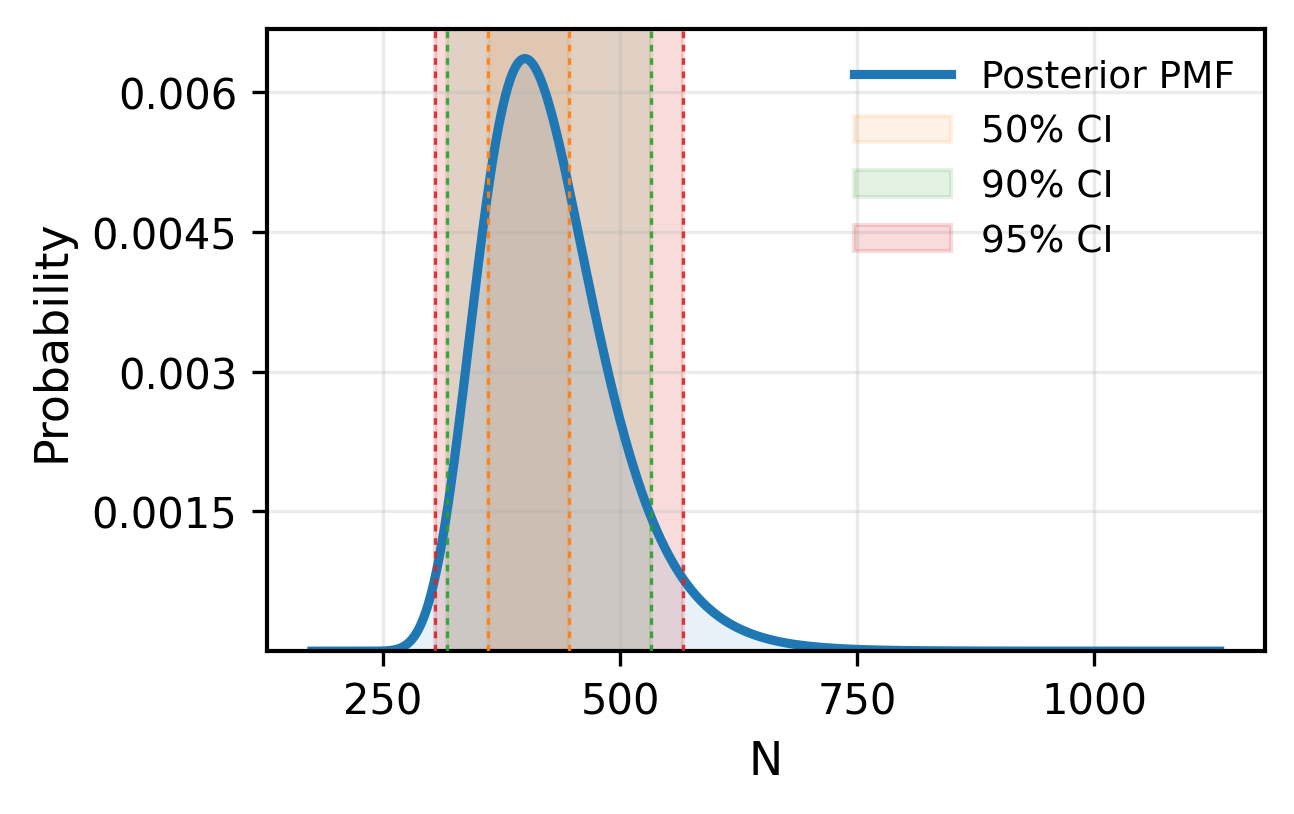

In [ ]:
# Figure 1-D - 95, 90, and 50% intervals

import math
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, FuncFormatter

from ehpmarkrecap import ehp  #EHP


def plot_mr_credible_levels(
    m=100, C=100, r=5,
    K=False,          # False => unbounded (single dataset, phi=1, omega=1)
    phi=False,        # False or 1.0
    omega=False,      # False or 1.0
    ci_levels=(0.50, 0.90, 0.95),
    figsize=(4.2, 2.6),   # small panel default
    dpi=300,
    max_xticks=5,
    max_yticks=4,
    title=None,
    outpath=None,        
    show=True
):
    widest = max(ci_levels)
    alpha_base = 1.0 - widest

    res_base = ehp((m, C, r), K=K, phi=phi, omega=omega, alpha=alpha_base)
    x = np.asarray(res_base["domain"])
    p = np.asarray(res_base["pmf"])

    mode = int(res_base["mode"])
    median = int(res_base["median"])
    mean = float(res_base["mean"])

    # Compute CI bounds for all requested levels
    ci_bounds = {}
    for level in sorted(ci_levels):
        alpha = 1.0 - float(level)
        res = ehp((m, C, r), K=K, phi=phi, omega=omega, alpha=alpha)
        ci_bounds[level] = (int(res["ci_low"]), int(res["ci_high"]))

    # Style
    rc = {
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "axes.linewidth": 1.0,
        "figure.dpi": dpi,
        "savefig.dpi": dpi,
    }

    with mpl.rc_context(rc):
        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

        # Posterior PMF
        ax.plot(x, p, linewidth=2.2, label="Posterior PMF")
        ax.fill_between(x, 0, p, alpha=0.10)

        # Credible interval bands (layered)
        for i, level in enumerate(sorted(ci_levels)):
            lo, hi = ci_bounds[level]
            band_color = f"C{i+1}"

            ax.axvspan(
                lo, hi,
                color=band_color,
                alpha=0.10 + 0.03 * i,
                label=f"{int(round(level * 100))}% CI",
                zorder=0.5,  # keep band behind PMF
            )
    
            border_kw = dict(
                color=band_color,
                linestyle=(0, (2, 2)),  # short dashes
                linewidth=0.8,
                alpha=0.9,
                zorder=3,
                label="_nolegend_",
            )
            ax.axvline(lo, **border_kw)
            ax.axvline(hi, **border_kw)
        # Axes labels / title
        ax.set_xlabel("N")
        ax.set_ylabel("Probability")

        # Tick reduction for readability
        ax.xaxis.set_major_locator(MaxNLocator(nbins=max_xticks, integer=True, prune="both"))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=max_yticks, prune="both"))
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))

        # Clean grid
        ax.grid(True, alpha=0.25)
        ax.set_ylim(bottom=0)

        # Legend
        handles, labels = ax.get_legend_handles_labels()
        summary_handles = []
        ax.legend(
            handles + summary_handles,
            labels + [h.get_label() for h in summary_handles],
            frameon=False,
            ncol=1,
            loc="upper right",
            handlelength=2.6,
            columnspacing=1.2,
            borderaxespad=0.4,
        )

        if outpath:
            fig.savefig(outpath, bbox_inches="tight")

        if show:
            plt.show()

        return fig, ax


if __name__ == "__main__":
    # Inputs
    m, C, r = 100, 100, 25

    K = False      # or set an int upper bound if you want a bounded model
    phi = False    # False or 1.0
    omega = False  # False or 1.0

    plot_mr_credible_levels(
        m=m, C=C, r=r,
        K=K, phi=phi, omega=omega,
        ci_levels=(0.50, 0.90, 0.95),
        figsize=(4.2, 2.6),
        dpi=300,
        max_xticks=5,
        max_yticks=5,
        title=None,
        outpath=None,
        show=True
    )


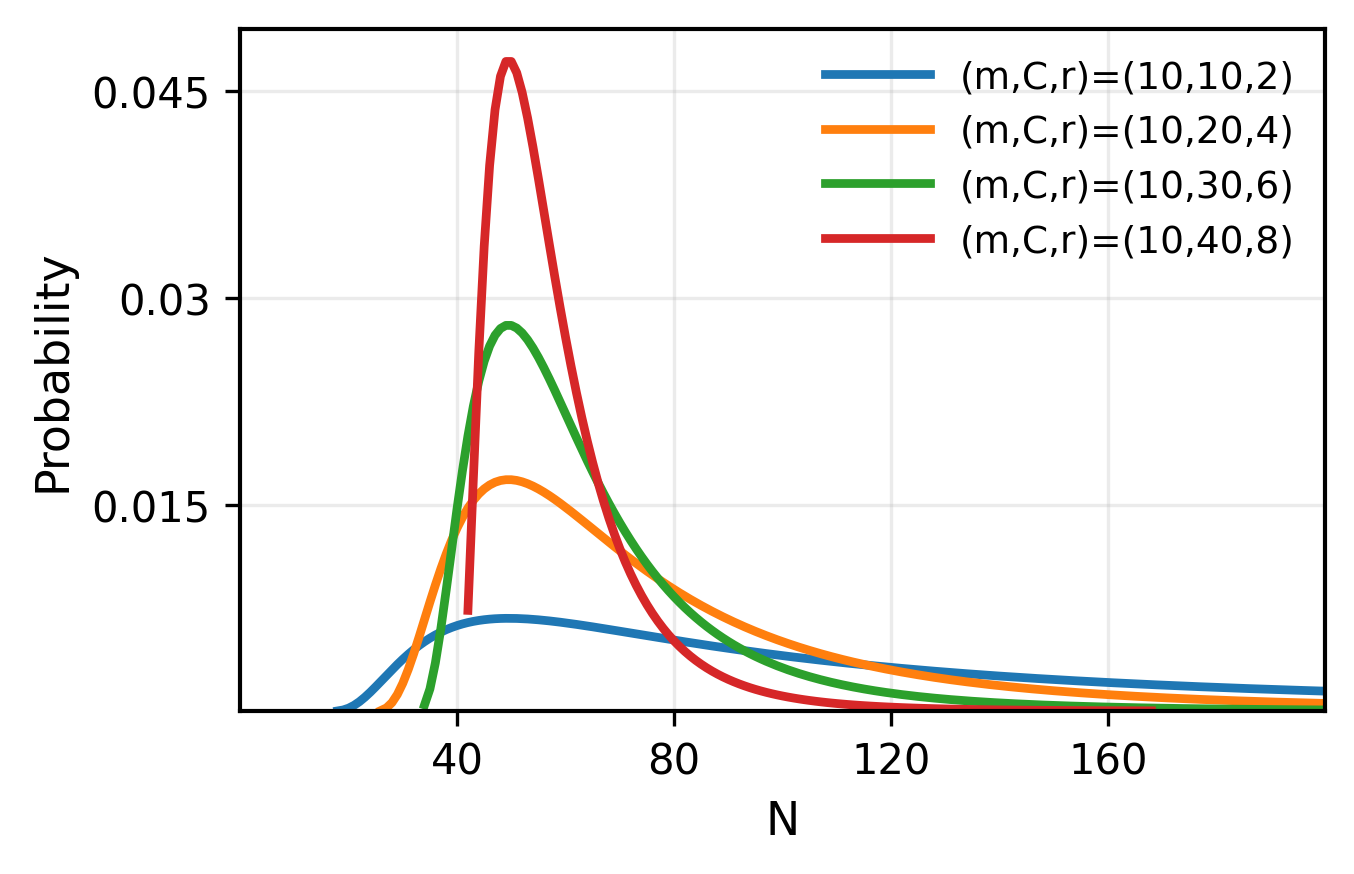

In [ ]:
# Figure 1-E - Compare multiple MR posterior PMFs on one axis


import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter

from ehpmarkrecap import ehp


def plot_mr_comparison(
    triplets=((10, 10, 2), (10, 20, 4), (10, 30, 6), (10, 40, 8), (10, 50, 10)),
    K=False,
    phi=False,
    omega=False,
    xlim=(0, 200),
    figsize=(4.4, 2.8),
    dpi=300,
    max_xticks=6,
    max_yticks=4,
    outpath=None, 
):
    # Styling tuned for small panels
    rc = {
        "font.size": 11,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "axes.linewidth": 1.0,
        "figure.dpi": dpi,
        "savefig.dpi": dpi,
    }

    with mpl.rc_context(rc):
        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

        # Plot each PMF curve
        for (m, C, r) in triplets:
            res = ehp((m, C, r), K=K, phi=phi, omega=omega, alpha=0.05)
            x = np.asarray(res["domain"])
            p = np.asarray(res["pmf"])

            # Clip to requested x-range (keeps line clean and fast)
            mask = (x >= xlim[0]) & (x <= xlim[1])
            ax.plot(
                x[mask],
                p[mask],
                linewidth=2.1,
                label=f"(m,C,r)=({m},{C},{r})"
            )

        # Axes formatting
        ax.set_xlabel("N")
        ax.set_ylabel("Probability")
        ax.set_xlim(*xlim)
        ax.set_ylim(bottom=0)

        # Reduced ticks for readability
        ax.xaxis.set_major_locator(MaxNLocator(nbins=max_xticks, integer=True, prune="both"))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=max_yticks, prune="both"))
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))

        # Light grid
        ax.grid(True, alpha=0.25)

        ax.legend(
            frameon=False,
            ncol=1,
            loc="upper right",
            handlelength=2.8,
            borderaxespad=0.4,
        )

        if outpath:
            fig.savefig(outpath, bbox_inches="tight")
        plt.show()

        return fig, ax


if __name__ == "__main__":
    plot_mr_comparison(
        triplets=((10, 10, 2), (10, 20, 4), (10, 30, 6), (10, 40, 8)),
        K=False,
        phi=False,     # "False or 1"
        omega=False,   # "False or 1"
        xlim=(0, 200),
        figsize=(4.4, 2.8),
        dpi=300,
        max_xticks=6,
        max_yticks=4,
        outpath=None,
    )


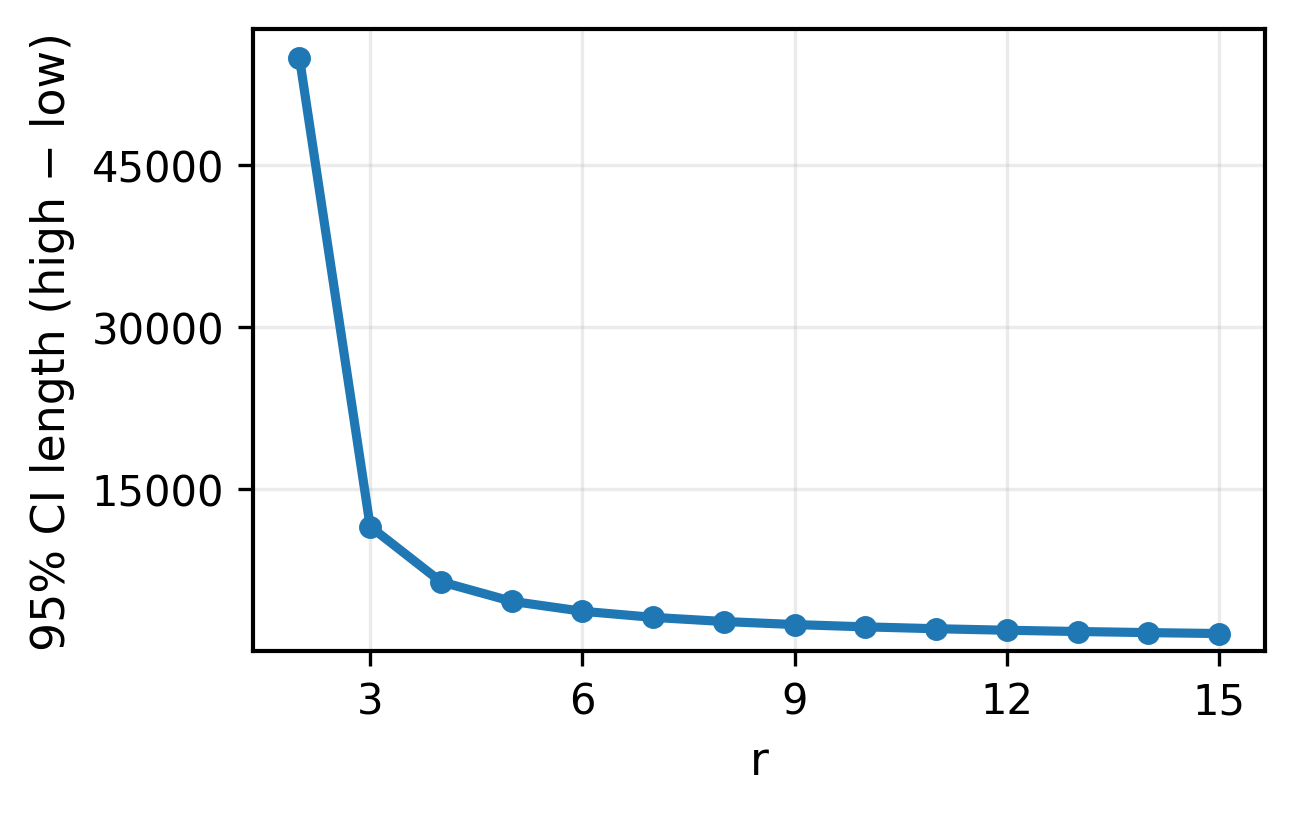

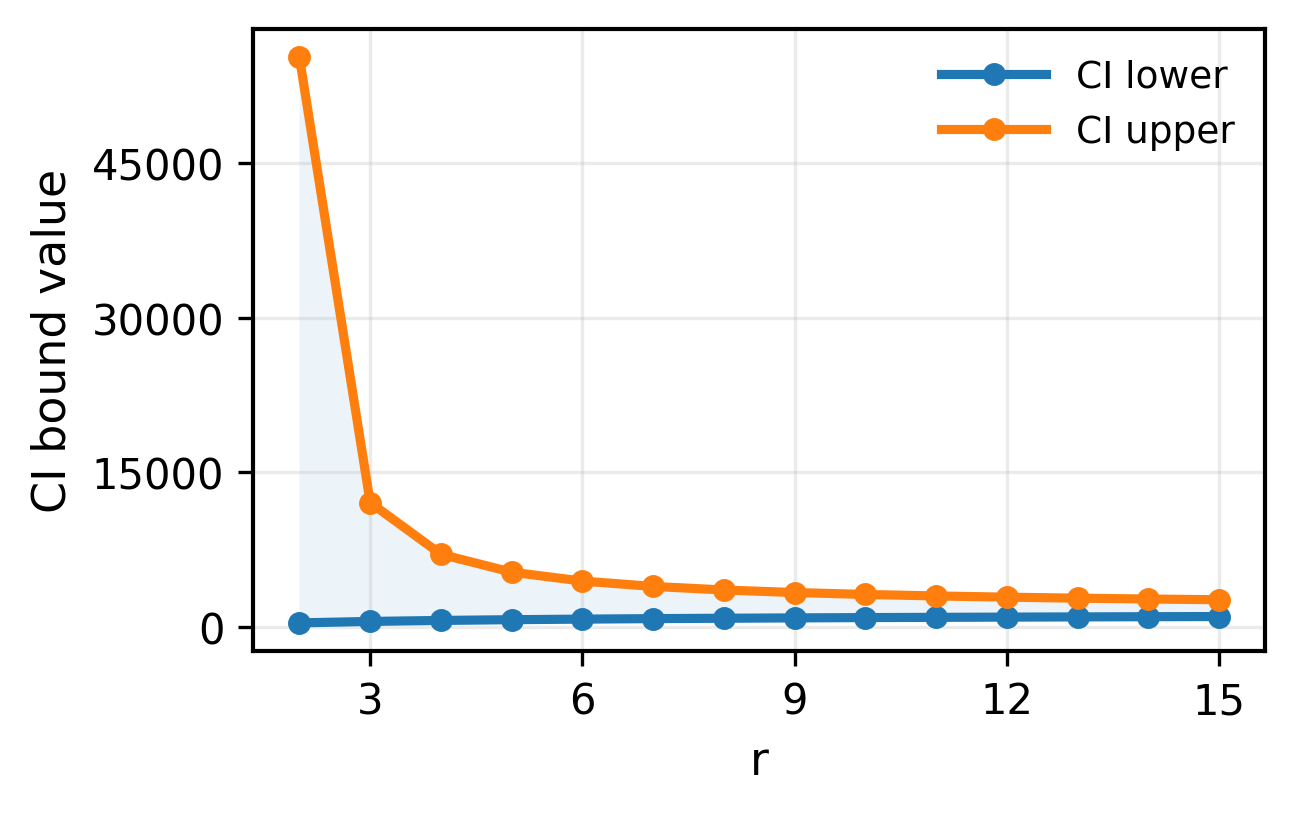

In [ ]:
# Figure 1-F,G - Sensitivity

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter

from ehpmarkrecap import ehp


def plot_ci_vs_r(
    m=150,
    r_values=range(2, 16),   # 2..15 inclusive
    C_from_r=lambda r: 10 * r,
    ci_level=0.95,           
    K=False,
    phi=False,
    omega=False,
    figsize1=(4.2, 2.6),
    figsize2=(4.2, 2.6),
    dpi=300,
    max_xticks=7,
    max_yticks=5,
    outpath1=None,          
    outpath2=None,           
    show=True
):
    alpha = 1.0 - float(ci_level)

    r_list = []
    lo_list = []
    hi_list = []
    len_list = []

    for r in r_values:
        C = C_from_r(r)
        res = ehp((m, C, r), K=K, phi=phi, omega=omega, alpha=alpha)
        lo = int(res["ci_low"])
        hi = int(res["ci_high"])
        r_list.append(int(r))
        lo_list.append(lo)
        hi_list.append(hi)
        len_list.append(hi - lo)

    r_arr = np.asarray(r_list)
    lo_arr = np.asarray(lo_list)
    hi_arr = np.asarray(hi_list)
    len_arr = np.asarray(len_list)

    # Style
    rc = {
        "font.size": 11,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "axes.linewidth": 1.0,
        "figure.dpi": dpi,
        "savefig.dpi": dpi,
    }

    with mpl.rc_context(rc):
        # Plot 1: CI length vs r
        fig1, ax1 = plt.subplots(figsize=figsize1, constrained_layout=True)
        ax1.plot(r_arr, len_arr, linewidth=2.2, marker="o", markersize=4.5)
        ax1.set_xlabel("r")
        ax1.set_ylabel(f"{int(round(ci_level*100))}% CI length (high − low)")
        ax1.set_ylim(bottom=0)
        ax1.grid(True, alpha=0.25)

        ax1.xaxis.set_major_locator(MaxNLocator(nbins=max_xticks, integer=True, prune="both"))
        ax1.yaxis.set_major_locator(MaxNLocator(nbins=max_yticks, prune="both"))
        ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))

        if outpath1:
            fig1.savefig(outpath1, bbox_inches="tight")

        # Plot 2: CI bounds vs r (two curves)
        fig2, ax2 = plt.subplots(figsize=figsize2, constrained_layout=True)
        ax2.plot(r_arr, lo_arr, linewidth=2.2, marker="o", markersize=4.5, label="CI lower")
        ax2.plot(r_arr, hi_arr, linewidth=2.2, marker="o", markersize=4.5, label="CI upper")
        ax2.fill_between(r_arr, lo_arr, hi_arr, alpha=0.08)

        ax2.set_xlabel("r")
        ax2.set_ylabel("CI bound value")
        ax2.grid(True, alpha=0.25)

        ax2.xaxis.set_major_locator(MaxNLocator(nbins=max_xticks, integer=True, prune="both"))
        ax2.yaxis.set_major_locator(MaxNLocator(nbins=max_yticks, prune="both"))
        ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))

        ax2.legend(frameon=False, loc="best", ncol=1, handlelength=2.8, borderaxespad=0.4)

        if outpath2:
            fig2.savefig(outpath2, bbox_inches="tight")

        if show:
            plt.show()

    return (fig1, ax1), (fig2, ax2)


if __name__ == "__main__":
    plot_ci_vs_r(
        m=150,
        r_values=range(2, 16),        # 2..15
        C_from_r=lambda r: 10 * r,    # (20,2), (30,3), ..., (150,15)
        ci_level=0.95,                
        K=False,
        phi=False,                    
        omega=False,                  
        outpath1=None,
        outpath2=None,
        show=True
    )


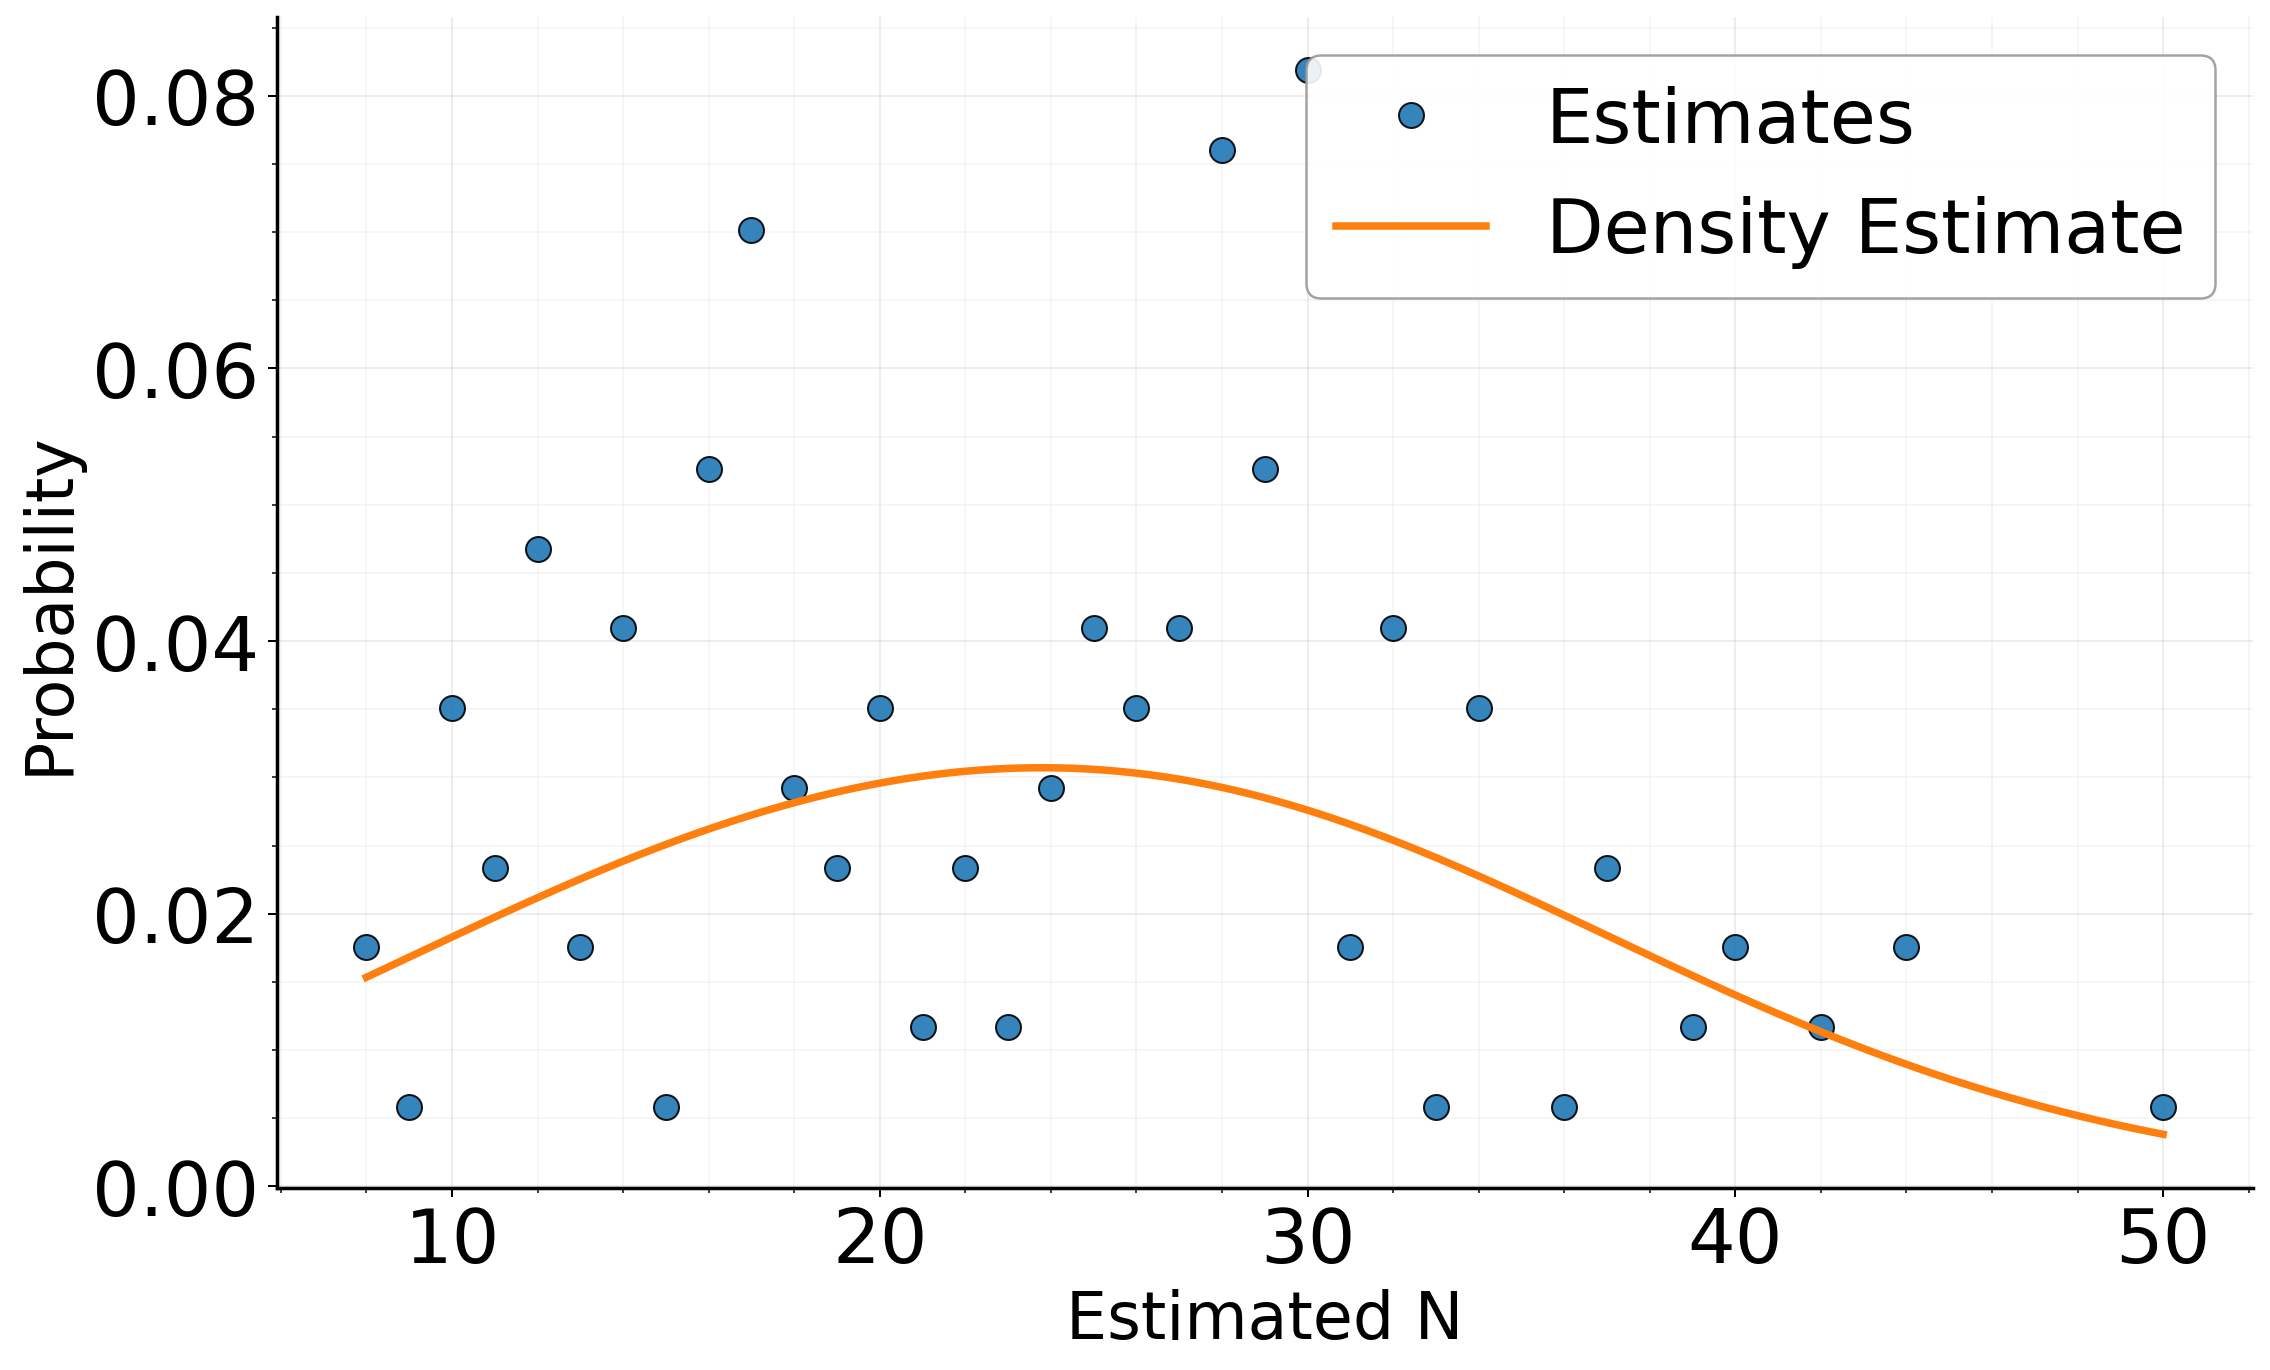

In [9]:
# Figure 1-H - Distribution of Estimates from Real data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


def plot_estimate_distribution(
    file_path: str,
    threshold: int = 100,
    bw_method: float | str = 1.0,
    figsize: tuple[float, float] = (12.5, 7.5),
):
    # Load and lightly clean the data
    df = pd.read_excel(file_path)
    df["estimate"] = df["estimate"].round().astype(int)
    df = df[df["estimate"] <= threshold]

    # Empirical discrete probabilities (rounded estimates)
    freq = df["estimate"].value_counts().sort_index()
    prob = freq / freq.sum()

    # KDE evaluated on a dense grid for a smooth curve
    x = np.linspace(df["estimate"].min(), df["estimate"].max(), 400)
    kde = gaussian_kde(df["estimate"], bw_method=bw_method)(x)

    plt.rcParams.update({
        "figure.dpi": 180,
        "savefig.dpi": 300,
        "font.size": 26,
        "axes.titlesize": 32,
        "axes.labelsize": 26,
        "xtick.labelsize": 30,
        "ytick.labelsize": 30,
        "legend.fontsize": 30,
        "axes.linewidth": 1.4,
        "lines.linewidth": 2.8,
    })

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    # Observed discrete distribution (points)
    ax.plot(
        prob.index,
        prob.values,
        linestyle="",
        marker="o",
        markersize=10,
        markeredgewidth=0.8,
        markeredgecolor="black",
        label="Estimates",
        alpha=0.90,
    )

    # KDE overlay (smooth line)
    ax.plot(
        x,
        kde,
        linewidth=3.0,
        label="Density Estimate",
    )

    ax.set_xlabel("Estimated N")
    ax.set_ylabel("Probability")

    # Force y-axis ticks only
    ax.set_yticks([0, 0.02, 0.04, 0.06, 0.08])

    # Clean, professional look
    ax.grid(True, which="major", alpha=0.22)
    ax.grid(True, which="minor", alpha=0.10)
    ax.minorticks_on()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        loc="upper right",
        frameon=True,
        fancybox=True,
        framealpha=0.90,   # slightly transparent background
        edgecolor="0.6",   # subtle border
        facecolor="white"  # clean background so it doesn't interfere
    )

    plt.show()


if __name__ == "__main__":
    data_path = r"A:\Research\1\Latex Versions\Manuscript Revised\Data\Hinneberg_et_al_2022_Multi_Surveyor_CMR_resultsfile.xlsx"
    plot_estimate_distribution(data_path)


In [5]:
# Table 1

from ehpmarkrecap import ehp
from OtherMethods import lp_mle_point, chapman_point, chapman_log_ci, exact_hypergeom_ci
# For mode switch to mC/r if needed
# Columns
print("m,C,r","|","Mode","|","Mean","|","Median","|","CI","|","LP Est.","|","Chapman Est.","|","Chapman CI","|","Exact hypergeometric CI")
print("-"*100)

m, C, r = 100, 10, 1
data=(m,C,r)
print(data, "|", "--", "|", "--", "|", "--", "|", "--", "|", lp_mle_point(m,C,r), "|", chapman_point(m,C,r), "|", chapman_log_ci(m,C,r), "|", exact_hypergeom_ci(m,C,r))

m, C, r = 100, 20, 2
data=(m,C,r)
res = ehp(data, K=False, phi=False, omega=False, alpha=0.05)
print(data, "|", res["mode"], "|", "--", "|", res["median"], "|", res["ci_low"], res["ci_high"], "|", lp_mle_point(m,C,r), "|", chapman_point(m,C,r), "|", chapman_log_ci(m,C,r), "|", exact_hypergeom_ci(m,C,r))

m, C, r = 100, 30, 3
data=(m,C,r)
res = ehp(data, K=False, phi=False, omega=False, alpha=0.05)
print(data, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", res["ci_low"], res["ci_high"], "|", lp_mle_point(m,C,r), "|", chapman_point(m,C,r), "|", chapman_log_ci(m,C,r), "|", exact_hypergeom_ci(m,C,r))

m, C, r = 100, 40, 4
data=(m,C,r)
res = ehp(data, K=False, phi=False, omega=False, alpha=0.05)
print(data, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", res["ci_low"], "|", res["ci_high"], "|", lp_mle_point(m,C,r), "|", chapman_point(m,C,r), "|", chapman_log_ci(m,C,r), "|", exact_hypergeom_ci(m,C,r))

m, C, r = 100, 50, 5
data=(m,C,r)
res = ehp(data, K=False, phi=False, omega=False, alpha=0.05)
print(data, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", res["ci_low"], res["ci_high"], "|", lp_mle_point(m,C,r), "|", chapman_point(m,C,r), "|", chapman_log_ci(m,C,r), "|", exact_hypergeom_ci(m,C,r))

m, C, r = 100, 60, 6
data=(m,C,r)
res = ehp(data, K=False, phi=False, omega=False, alpha=0.05)
print(data, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", res["ci_low"], res["ci_high"], "|", lp_mle_point(m,C,r), "|", chapman_point(m,C,r), "|", chapman_log_ci(m,C,r), "|", exact_hypergeom_ci(m,C,r))

m, C, r = 100, 70, 7
data=(m,C,r)
res = ehp(data, K=False, phi=False, omega=False, alpha=0.05)
print(data, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", res["ci_low"], res["ci_high"], "|", lp_mle_point(m,C,r), "|", chapman_point(m,C,r), "|", chapman_log_ci(m,C,r), "|", exact_hypergeom_ci(m,C,r))

m, C, r = 100, 80, 8
data=(m,C,r)
res = ehp(data, K=False, phi=False, omega=False, alpha=0.05)
print(data, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", res["ci_low"], res["ci_high"], "|", lp_mle_point(m,C,r), "|", chapman_point(m,C,r), "|", chapman_log_ci(m,C,r), "|", exact_hypergeom_ci(m,C,r))

m, C, r = 100, 90, 9
data=(m,C,r)
res = ehp(data, K=False, phi=False, omega=False, alpha=0.05)
print(data, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", res["ci_low"], res["ci_high"], "|", lp_mle_point(m,C,r), "|", chapman_point(m,C,r), "|", chapman_log_ci(m,C,r), "|", exact_hypergeom_ci(m,C,r))

m, C, r = 100, 100, 10
data=(m,C,r)
res = ehp(data, K=False, phi=False, omega=False, alpha=0.05)
print(data, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", res["ci_low"], res["ci_high"], "|", lp_mle_point(m,C,r), "|", chapman_point(m,C,r), "|", chapman_log_ci(m,C,r), "|", exact_hypergeom_ci(m,C,r))

m, C, r = 100, 500, 50
data=(m,C,r)
res = ehp(data, K=False, phi=False, omega=False, alpha=0.05)
print(data, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", res["ci_low"], res["ci_high"], "|", lp_mle_point(m,C,r), "|", chapman_point(m,C,r), "|", chapman_log_ci(m,C,r), "|", exact_hypergeom_ci(m,C,r))

m, C, r = 1000, 1000, 1000
data=(m,C,r)
res = ehp(data, K=False, phi=False, omega=False, alpha=0.05)
print(data, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", res["ci_low"], res["ci_high"], "|", lp_mle_point(m,C,r), "|", chapman_point(m,C,r), "|", chapman_log_ci(m,C,r), "|", exact_hypergeom_ci(m,C,r))

m, C, r = 200, 200, 20
data=(m,C,r)
res = ehp(data, K=False, phi=False, omega=False, alpha=0.05)
print(data, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", res["ci_low"], res["ci_high"], "|", lp_mle_point(m,C,r), "|", chapman_point(m,C,r), "|", chapman_log_ci(m,C,r), "|", exact_hypergeom_ci(m,C,r))

m, C, r = 500, 500, 50
data=(m,C,r)
res = ehp(data, K=False, phi=False, omega=False, alpha=0.05)
print(data, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", res["ci_low"], res["ci_high"], "|", lp_mle_point(m,C,r), "|", chapman_point(m,C,r), "|", chapman_log_ci(m,C,r), "|", exact_hypergeom_ci(m,C,r))

m, C, r = 1000, 1000, 100
data=(m,C,r)
res = ehp(data, K=False, phi=False, omega=False, alpha=0.05)
print(data, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", res["ci_low"], res["ci_high"], "|", lp_mle_point(m,C,r), "|", chapman_point(m,C,r), "|", chapman_log_ci(m,C,r), "|", exact_hypergeom_ci(m,C,r))

m, C, r = 10000, 10000, 500
data=(m,C,r)
res = ehp(data, K=False, phi=False, omega=False, alpha=0.05)
print(data, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", res["ci_low"], res["ci_high"], "|", lp_mle_point(m,C,r), "|", chapman_point(m,C,r), "|", chapman_log_ci(m,C,r), "|", exact_hypergeom_ci(m,C,r))

m,C,r | Mode | Mean | Median | CI | LP Est. | Chapman Est. | Chapman CI | Exact hypergeometric CI
----------------------------------------------------------------------------------------------------
(100, 10, 1) | -- | -- | -- | -- | 1000.0 | 554.5 | (200.91187173886354, 1530.373727241148) | (229, 39552.0)
(100, 20, 2) | 1000 | -- | 2773 | 239 36746 | 1000.0 | 706.0 | (288.4836652546376, 1727.7789352823238) | (322, 8067.0)
(100, 30, 3) | 999 | 2871.0 | 1736 | 333 7989 | 1000.0 | 781.75 | (350.3214669603618, 1744.492188282451) | (386, 4702.0)
(100, 40, 4) | 999 | 1930.5 | 1461 | 399 | 4655 | 1000.0 | 827.2 | (397.892060243878, 1719.712224417346) | (434, 3546.0)
(100, 50, 5) | 999 | 1617.0 | 1334 | 447 3498 | 1000.0 | 857.5 | (436.31403192648753, 1685.2683988946021) | (472, 2969.0)
(100, 60, 6) | 999 | 1460.25 | 1262 | 486 2923 | 1000.0 | 879.1428571428571 | (468.3659045487529, 1650.1887856460198) | (503, 2622.0)
(100, 70, 7) | 999 | 1366.2 | 1215 | 517 2578 | 1000.0 | 895.375 | (495.736

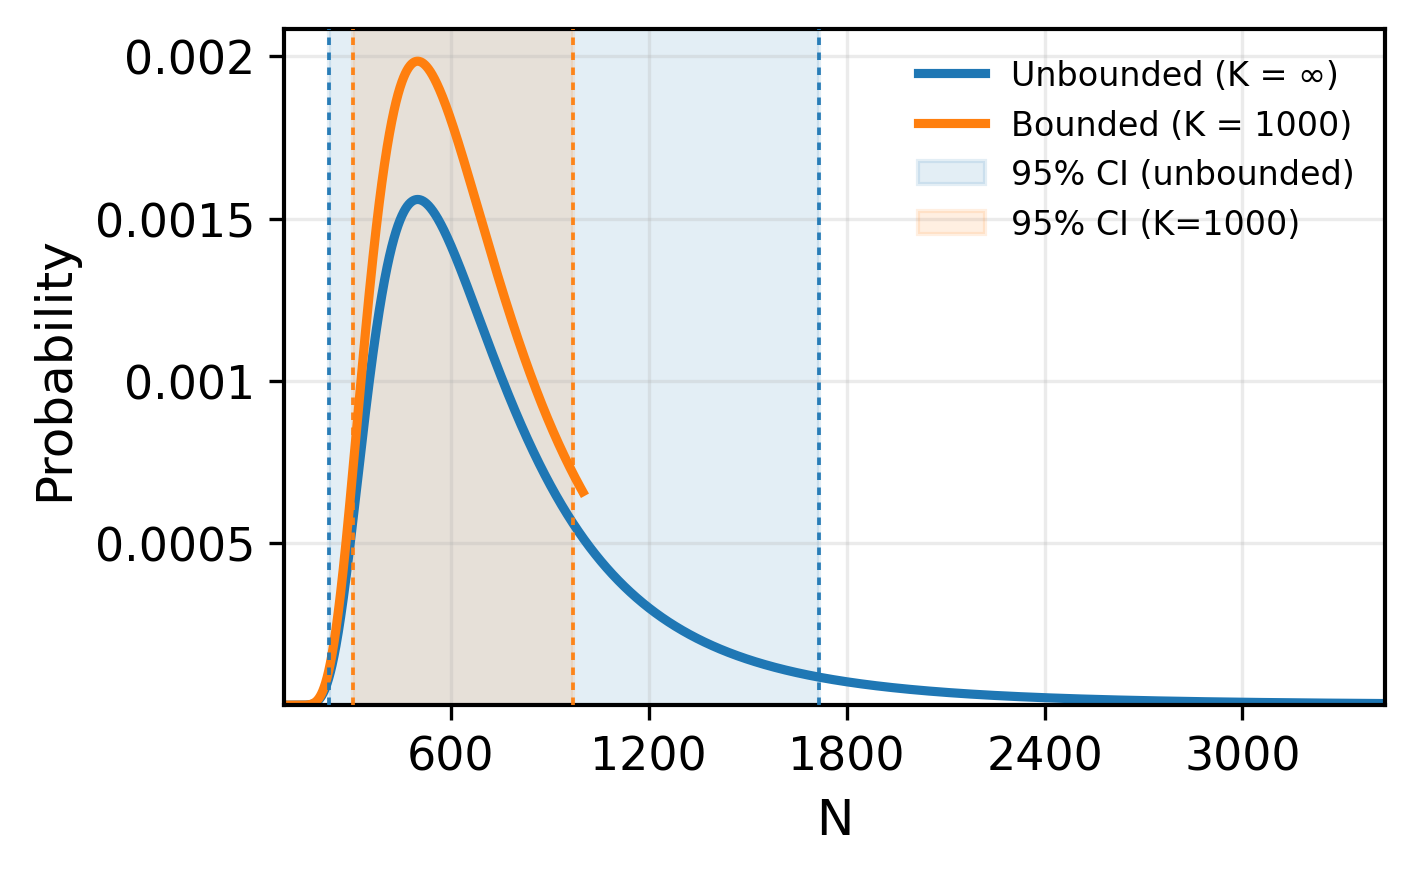

In [ ]:
# Figure 2-A - Impact of limiting by K

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter

from ehpmarkrecap import ehp


def plot_two_mr_curves_ci95(
    m=50, C=50, r=5,
    K_bounded=1000,
    phi=False,
    omega=False,
    ci_level=0.95,
    figsize=(4.6, 2.8),
    dpi=300,
    max_xticks=6,
    max_yticks=5,
    title=None,
    outpath=None,  
    show=True
):
    alpha = 1.0 - float(ci_level)

    # curve 1: unbounded (no K)
    res_unb = ehp((m, C, r), K=False, phi=phi, omega=omega, alpha=alpha)
    x1 = np.asarray(res_unb["domain"])
    p1 = np.asarray(res_unb["pmf"])
    lo1, hi1 = int(res_unb["ci_low"]), int(res_unb["ci_high"])

    # curve 2: bounded (K provided)
    res_bnd = ehp((m, C, r), K=int(K_bounded), phi=phi, omega=omega, alpha=alpha)
    x2 = np.asarray(res_bnd["domain"])
    p2 = np.asarray(res_bnd["pmf"])
    lo2, hi2 = int(res_bnd["ci_low"]), int(res_bnd["ci_high"])

    # Style
    rc = {
        "font.size": 12,
        "axes.titlesize": 13,
        "axes.labelsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 8,
        "axes.linewidth": 1.0,
        "figure.dpi": dpi,
        "savefig.dpi": dpi,
    }

    with mpl.rc_context(rc):
        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

        # Plot the two PMFs (use default color cycle)
        line1, = ax.plot(x1, p1, lw=2.2, label="Unbounded (K = ∞)")
        line2, = ax.plot(x2, p2, lw=2.2, label=f"Bounded (K = {int(K_bounded)})")

        # 95% CI shading + boundary lines (matching each curve color)
        def add_ci_band(lo, hi, color, label):
            ax.axvspan(lo, hi, color=color, alpha=0.12, zorder=0.4, label=label)
            border_kw = dict(
                color=color,
                linestyle=(0, (2, 2)),  # short dashes
                linewidth=0.9,
                alpha=0.95,
                zorder=3,
            )
            ax.axvline(lo, **border_kw)
            ax.axvline(hi, **border_kw)

        add_ci_band(lo1, hi1, line1.get_color(), f"{int(ci_level*100)}% CI (unbounded)")
        add_ci_band(lo2, hi2, line2.get_color(), f"{int(ci_level*100)}% CI (K={int(K_bounded)})")

        # Labels
        ax.set_xlabel("N")
        ax.set_ylabel("Probability")

        ax.set_title(title)

        # Ticks: fewer labels for readability
        ax.xaxis.set_major_locator(MaxNLocator(nbins=max_xticks, integer=True, prune="both"))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=max_yticks, prune="both"))
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))

        # Grid + bounds
        ax.grid(True, alpha=0.25)
        ax.set_ylim(bottom=0)

        # x-limits: show full support of both curves
        xmin = min(int(x1[0]), int(x2[0]))
        xmax = max(int(x1[-1]), int(x2[-1]))
        ax.set_xlim(xmin, xmax)

        # Legend
        ax.legend(frameon=False, loc="upper right")

        if outpath:
            fig.savefig(outpath, bbox_inches="tight")

        if show:
            plt.show()

        return fig, ax


if __name__ == "__main__":
    plot_two_mr_curves_ci95(
        m=50, C=50, r=5,
        K_bounded=1000,
        phi=False,
        omega=False,
        ci_level=0.95,
        figsize=(4.6, 2.8),
        dpi=300,
        max_xticks=6,
        max_yticks=5,
        outpath=None,
        show=True,
    )


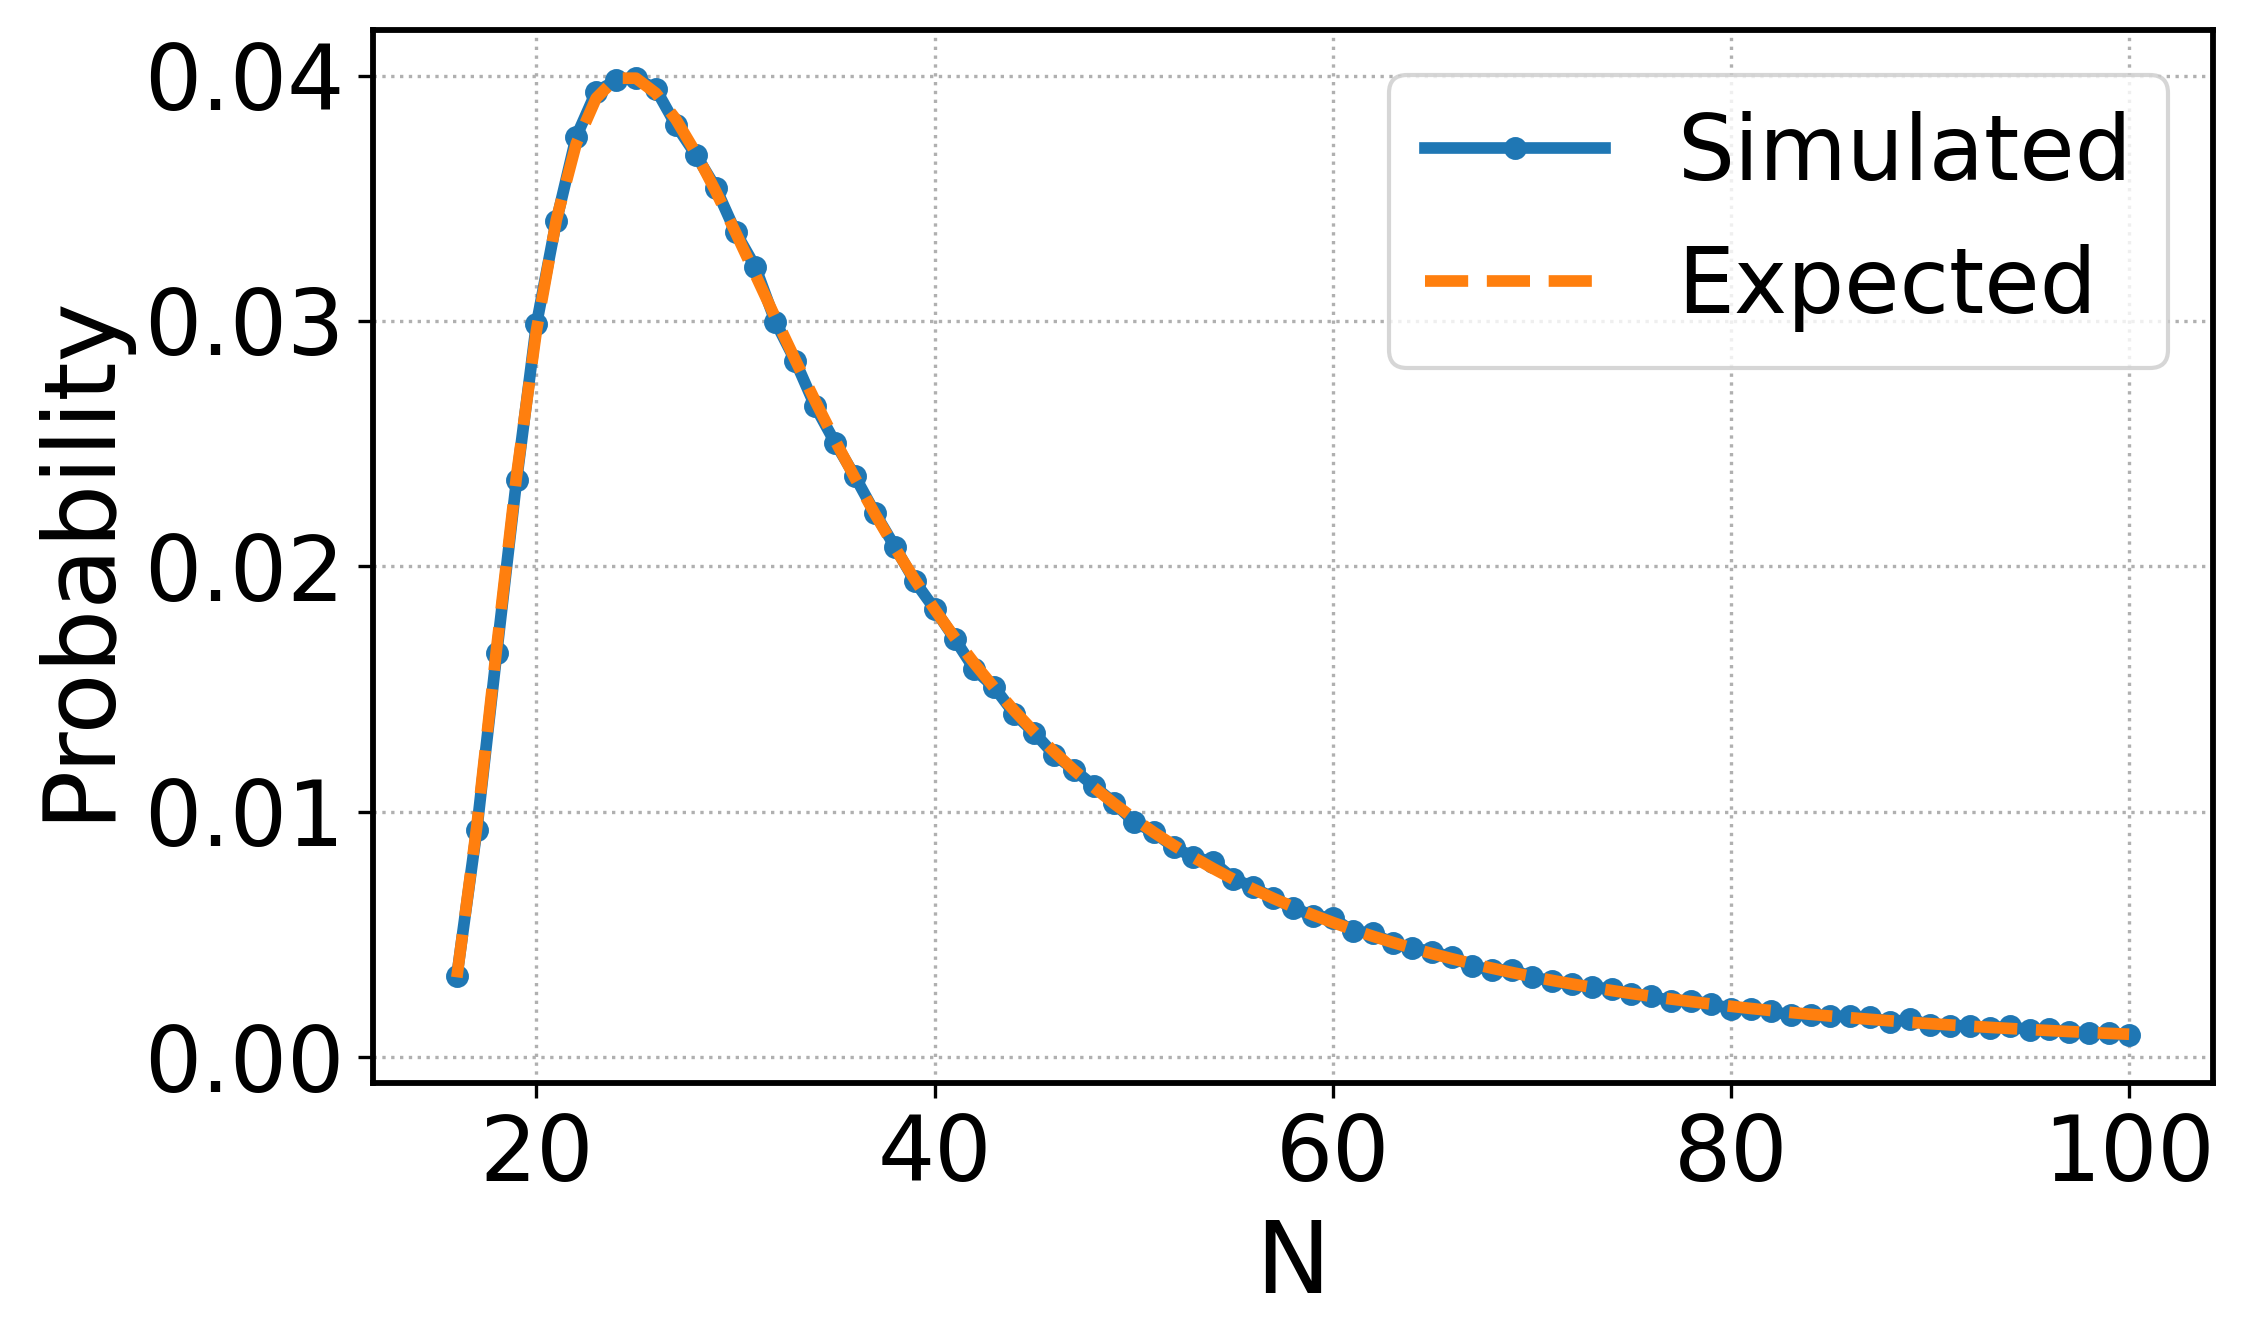

In [ ]:
# Figure 2-B - Expected with K vs Simulation

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb

# Configuration
params = {
    'marked_count': 10,
    'sample_size': 10,
    'target_recaptured': 4,
    'normalization_constant': 8.06,
    'population_min': 16,
    'population_max': 100,
    'population_step': 1,
    'simulations': 100000,
    'font_size': 24,
    'figure_size': (8, 5),
    'dpi': 300
}

populations = np.arange(
    params['population_min'],
    params['population_max'] + 1,
    params['population_step']
)
simulated_probs = []
expected_probs = []

# Simulation + Expected
for N in populations:
    marked = np.zeros(N)
    marked[:params['marked_count']] = 1
    success_count = 0

    for _ in range(params['simulations']):
        np.random.shuffle(marked)
        if np.sum(marked[:params['sample_size']]) == params['target_recaptured']:
            success_count += 1

    simulated_probs.append(success_count / params['simulations'])
    expected = (
        comb(params['marked_count'], params['target_recaptured'])
        * comb(N - params['marked_count'], params['sample_size'] - params['target_recaptured'])
        / comb(N, params['sample_size'])
    ) / params['normalization_constant']
    expected_probs.append(expected)

simulated_probs = np.array(simulated_probs)
simulated_probs /= simulated_probs.sum()

# Style
plt.rcParams.update({
    'font.size': params['font_size'],
    'axes.labelsize': params['font_size'],
    'legend.fontsize': params['font_size'] * 0.9,
    'xtick.labelsize': params['font_size'] * 0.9,
    'ytick.labelsize': params['font_size'] * 0.9
})

fig, ax = plt.subplots(figsize=params['figure_size'], dpi=params['dpi'])
ax.plot(
    populations,
    simulated_probs,
    marker='o',
    linestyle='-'
)
ax.plot(
    populations,
    expected_probs,
    linestyle='--'
)
ax.set_xlabel('N')
ax.set_ylabel('Probability')
ax.legend(['Simulated', 'Expected'], loc='best')
ax.grid(True, linestyle=':')

plt.tight_layout()
plt.show()

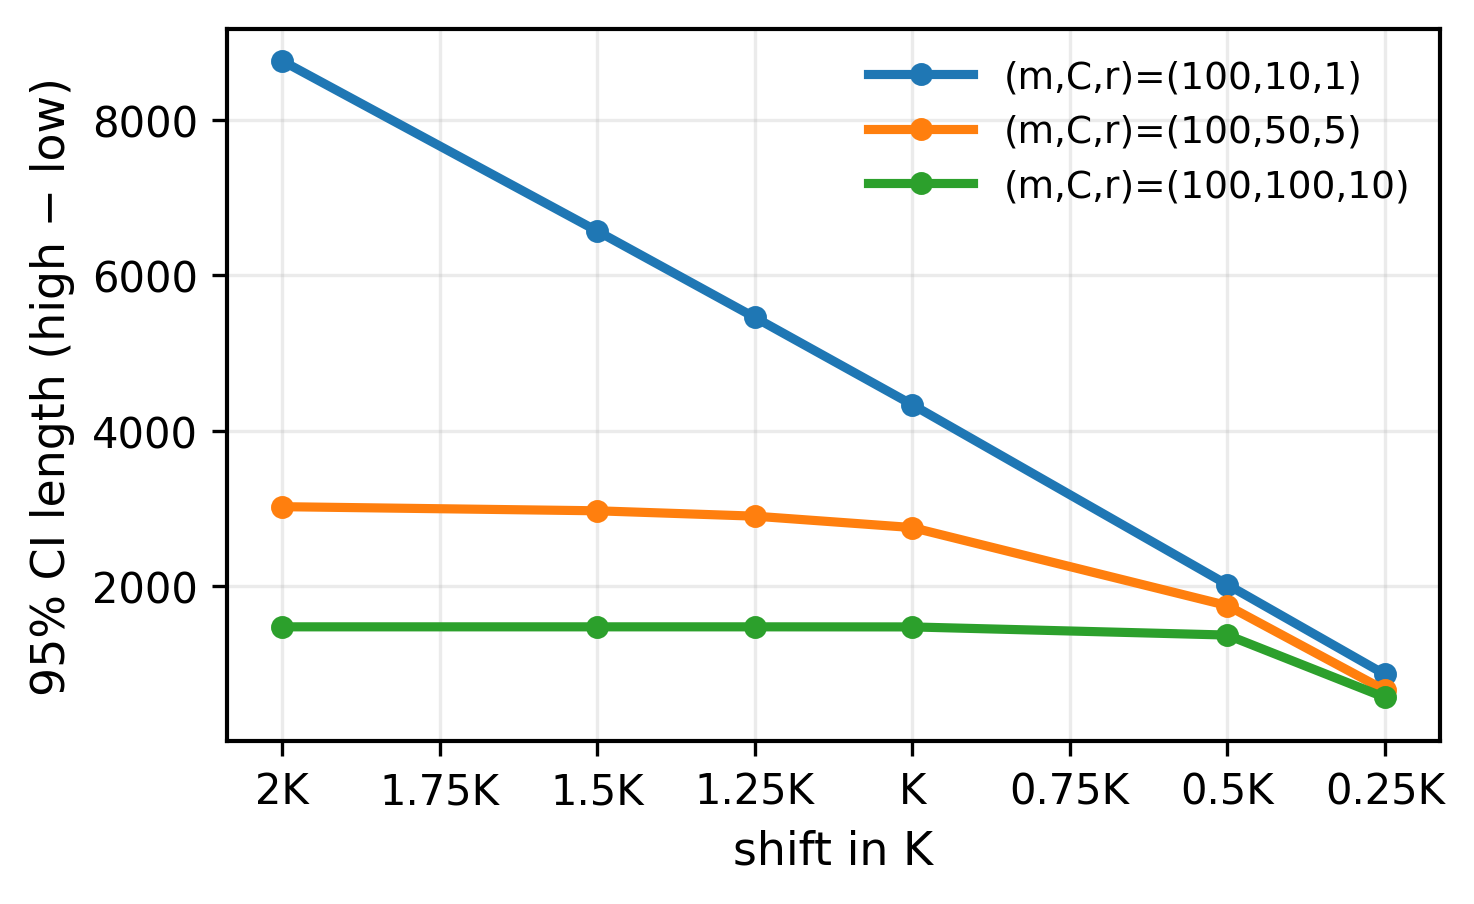

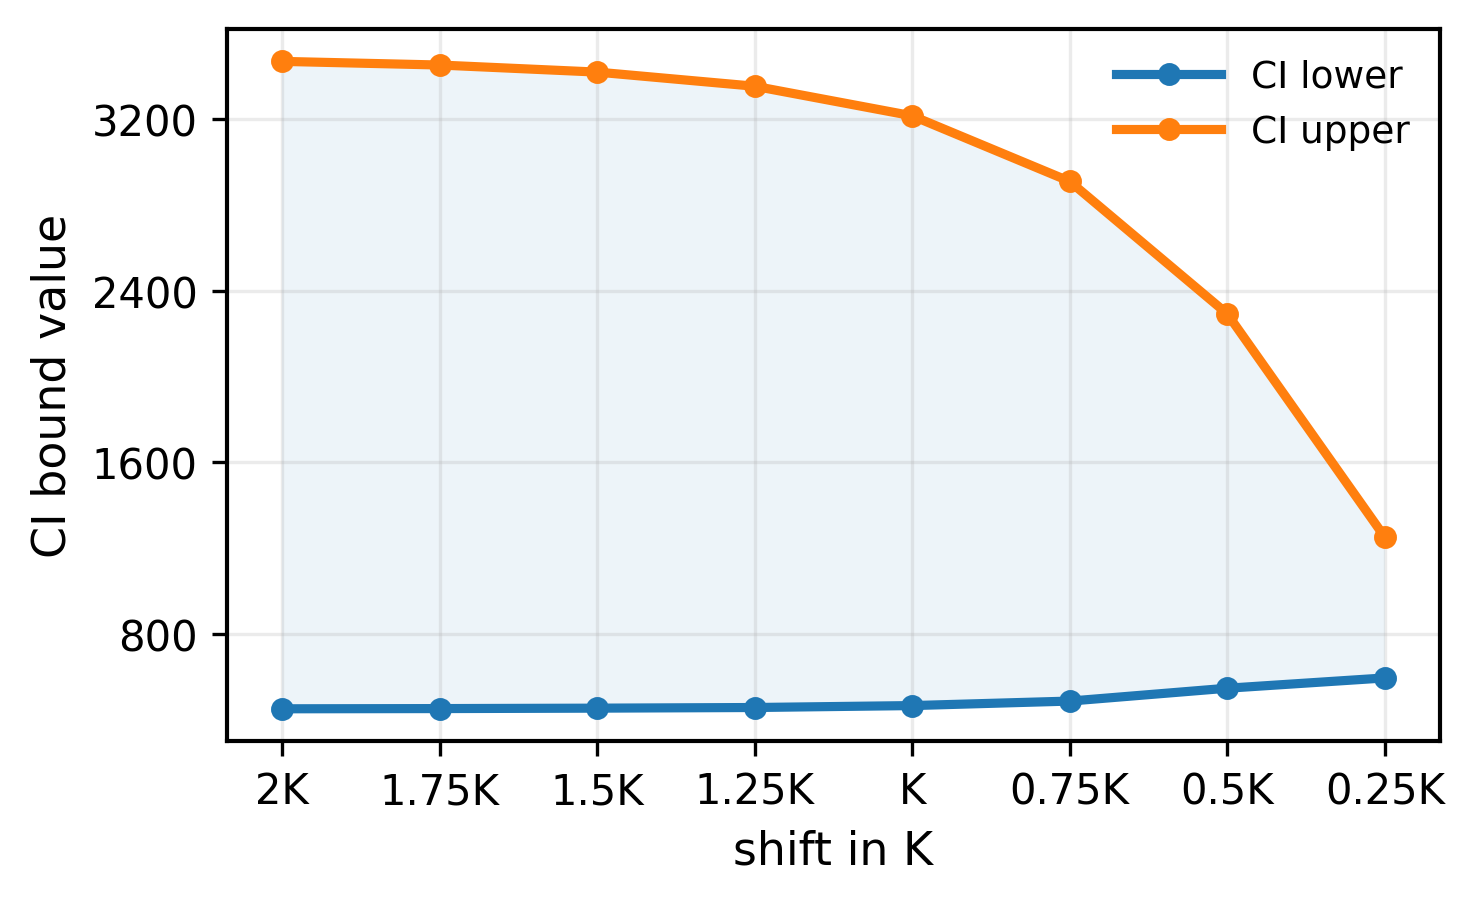

In [ ]:
# Figure 2-C,D - Sensitivity

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter

from ehpmarkrecap import ehp


def _k_from_multiplier(K_base: int, mult: float) -> int:
    # Robust integer K for ehp (avoid floats)
    return int(round(float(mult) * int(K_base)))


def plot_ci_vs_shift_in_K(
    K_base=5000,
    ci_level=0.95,  # 95% CI by default
    phi=False,
    omega=False,
    figsize1=(4.8, 2.9),
    figsize2=(4.8, 2.9),
    dpi=300,
    outpath1=None,  # e.g. "ci_length_vs_shiftK.pdf"
    outpath2=None,  # e.g. "ci_bounds_vs_shiftK.pdf"
    show=True
):
    alpha = 1.0 - float(ci_level)

    # Full tick set (shown on both plots), displayed in descending order via inverted x-axis
    tick_mults = np.array([0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0], dtype=float)
    tick_labels = ["0.25K", "0.5K", "0.75K", "K", "1.25K", "1.5K", "1.75K", "2K"]

    # Plot 1 data multipliers (subset)
    mults_plot1 = np.array([0.25, 0.5, 1.0, 1.25, 1.5, 2.0], dtype=float)

    # Plot 2 data multipliers (full set)
    mults_plot2 = tick_mults.copy()

    # Small-panel friendly styling
    rc = {
        "font.size": 11,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "axes.linewidth": 1.0,
        "figure.dpi": dpi,
        "savefig.dpi": dpi,
    }

    with mpl.rc_context(rc):
        # -------------------------
        # Plot 1: CI length vs shift in K (3 curves)
        # -------------------------
        fig1, ax1 = plt.subplots(figsize=figsize1, constrained_layout=True)

        triplets = [(100, 10, 1), (100, 50, 5), (100, 100, 10)]
        for (m, C, r) in triplets:
            ci_lengths = []
            for mult in mults_plot1:
                K = _k_from_multiplier(K_base, mult)
                res = ehp((m, C, r), K=K, phi=phi, omega=omega, alpha=alpha)
                lo = int(res["ci_low"])
                hi = int(res["ci_high"])
                ci_lengths.append(hi - lo)

            ax1.plot(
                mults_plot1,
                np.asarray(ci_lengths, dtype=float),
                linewidth=2.2,
                marker="o",
                markersize=4.5,
                label=f"(m,C,r)=({m},{C},{r})"
            )

        ax1.set_xlabel("shift in K")
        ax1.set_ylabel(f"{int(round(ci_level * 100))}% CI length (high − low)")
        ax1.set_ylim(bottom=0)
        ax1.grid(True, alpha=0.25)

        # X ticks are "shift in K" labels (as requested)
        ax1.set_xticks(tick_mults)
        ax1.set_xticklabels(tick_labels)
        ax1.invert_xaxis()  # 2K -> 0.25K

        # Keep y ticks readable
        ax1.yaxis.set_major_locator(MaxNLocator(nbins=5, prune="both"))
        ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))

        ax1.legend(frameon=False, loc="upper right", ncol=1, handlelength=2.8, borderaxespad=0.4)

        if outpath1:
            fig1.savefig(outpath1, bbox_inches="tight")

        # -------------------------
        # Plot 2: CI bounds vs shift in K for (100,50,5)
        # -------------------------
        fig2, ax2 = plt.subplots(figsize=figsize2, constrained_layout=True)

        m, C, r = (100, 50, 5)
        lo_vals = []
        hi_vals = []
        for mult in mults_plot2:
            K = _k_from_multiplier(K_base, mult)
            res = ehp((m, C, r), K=K, phi=phi, omega=omega, alpha=alpha)
            lo_vals.append(int(res["ci_low"]))
            hi_vals.append(int(res["ci_high"]))

        lo_arr = np.asarray(lo_vals, dtype=float)
        hi_arr = np.asarray(hi_vals, dtype=float)

        ax2.plot(mults_plot2, lo_arr, linewidth=2.2, marker="o", markersize=4.5, label="CI lower")
        ax2.plot(mults_plot2, hi_arr, linewidth=2.2, marker="o", markersize=4.5, label="CI upper")
        ax2.fill_between(mults_plot2, lo_arr, hi_arr, alpha=0.08)

        ax2.set_xlabel("shift in K")
        ax2.set_ylabel("CI bound value")
        ax2.grid(True, alpha=0.25)

        ax2.set_xticks(tick_mults)
        ax2.set_xticklabels(tick_labels)
        ax2.invert_xaxis()  # 2K -> 0.25K

        ax2.yaxis.set_major_locator(MaxNLocator(nbins=5, prune="both"))
        ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))

        ax2.legend(frameon=False, loc="upper right", ncol=1, handlelength=2.8, borderaxespad=0.4)

        if outpath2:
            fig2.savefig(outpath2, bbox_inches="tight")

        if show:
            plt.show()

    return (fig1, ax1), (fig2, ax2)


if __name__ == "__main__":
    plot_ci_vs_shift_in_K(
        K_base=5000,
        ci_level=0.95,
        phi=False,     # False or 1
        omega=False,   # False or 1
        outpath1=None,
        outpath2=None,
        show=True
    )


In [14]:
# Table 2

from ehpmarkrecap import ehp

def change(data, K):
    res1=ehp(data)
    res2=ehp(data,K)
    L1 = res1["ci_high"] - res1["ci_low"]
    L2 = res2["ci_high"] - res2["ci_low"]
    R = L2/L1
    C = (1 - R)*100
    return C

# For mode switch to mC/r if needed
# Columns
print("m,C,r","|","K","|","Mode","|","Mean","|","Median","|","CI","|","Reduction in CI width vs. no K (%)")
print("-"*100)

m, C, r, K = 100, 10, 1, 3000
data=(m,C,r)
res = ehp(data, K=K, phi=False, omega=False, alpha=0.05)
print(data, "|", K, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", "--")

m, C, r, K = 100, 20, 2, 3000
data=(m,C,r)
res = ehp(data, K=K, phi=False, omega=False, alpha=0.05)
print(data, "|", K, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data, K))

m, C, r, K = 100, 30, 3, 3000
data=(m,C,r)
res = ehp(data, K=K, phi=False, omega=False, alpha=0.05)
print(data, "|", K, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data, K))

m, C, r, K = 100, 40, 4, 3000
data=(m,C,r)
res = ehp(data, K=K, phi=False, omega=False, alpha=0.05)
print(data, "|", K, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data, K))

m, C, r, K = 100, 50, 5, 3000
data=(m,C,r)
res = ehp(data, K=K, phi=False, omega=False, alpha=0.05)
print(data, "|", K, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data, K))

m, C, r, K = 100, 60, 6, 3000
data=(m,C,r)
res = ehp(data, K=K, phi=False, omega=False, alpha=0.05)
print(data, "|", K, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data, K))

m, C, r, K = 100, 70, 7, 3000
data=(m,C,r)
res = ehp(data, K=K, phi=False, omega=False, alpha=0.05)
print(data, "|", K, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data, K))

m, C, r, K = 100, 80, 8, 3000
data=(m,C,r)
res = ehp(data, K=K, phi=False, omega=False, alpha=0.05)
print(data, "|", K, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data, K))

m, C, r, K = 100, 90, 9, 3000
data=(m,C,r)
res = ehp(data, K=K, phi=False, omega=False, alpha=0.05)
print(data, "|", K, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data, K))

m, C, r, K = 100, 100, 10, 3000
data=(m,C,r)
res = ehp(data, K=K, phi=False, omega=False, alpha=0.05)
print(data, "|", K, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data, K))

m, C, r, K = 100, 100, 10, 2800
data=(m,C,r)
res = ehp(data, K=K, phi=False, omega=False, alpha=0.05)
print(data, "|", K, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data, K))

m, C, r, K = 100, 100, 10, 2400
data=(m,C,r)
res = ehp(data, K=K, phi=False, omega=False, alpha=0.05)
print(data, "|", K, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data, K))

m, C, r, K = 100, 100, 10, 2200
data=(m,C,r)
res = ehp(data, K=K, phi=False, omega=False, alpha=0.05)
print(data, "|", K, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data, K))

m, C, r, K = 100, 100, 10, 2000
data=(m,C,r)
res = ehp(data, K=K, phi=False, omega=False, alpha=0.05)
print(data, "|", K, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data, K))

m, C, r, K = 200, 200, 20, 4000
data=(m,C,r)
res = ehp(data, K=K, phi=False, omega=False, alpha=0.05)
print(data, "|", K, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data, K))

m, C, r, K = 300, 300, 30, 6000
data=(m,C,r)
res = ehp(data, K=K, phi=False, omega=False, alpha=0.05)
print(data, "|", K, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data, K))

m, C, r, K = 500, 500, 50, 10000
data=(m,C,r)
res = ehp(data, K=K, phi=False, omega=False, alpha=0.05)
print(data, "|", K, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data, K))

m,C,r | K | Mode | Mean | Median | CI | Reduction in CI width vs. no K (%)
----------------------------------------------------------------------------------------------------
(100, 10, 1) | 3000 | 999 | 1605.990815743198 | 1556 | (473, 2963) | --
(100, 20, 2) | 3000 | 1000 | 1557.4276672909104 | 1471 | (482, 2874) | 93.44783192264498
(100, 30, 3) | 3000 | 999 | 1499.477715877429 | 1392 | (491, 2789) | 69.98432601880877
(100, 40, 4) | 3000 | 999 | 1442.6894860829314 | 1326 | (501, 2693) | 48.49624060150376
(100, 50, 5) | 3000 | 999 | 1390.5079859113378 | 1274 | (513, 2585) | 32.08784005244182
(100, 60, 6) | 3000 | 999 | 1344.1356591745466 | 1233 | (527, 2467) | 20.393926959376284
(100, 70, 7) | 3000 | 999 | 1303.7572080368002 | 1200 | (542, 2345) | 12.518195050946145
(100, 80, 8) | 3000 | 999 | 1269.0440207528238 | 1174 | (558, 2228) | 7.427937915742788
(100, 90, 9) | 3000 | 999 | 1239.42344523469 | 1153 | (575, 2122) | 4.329004329004327
(100, 100, 10) | 3000 | 999 | 1214.2362604607326

C:\Users\Danial\AppData\Local\Temp\ipykernel_14220\379853566.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


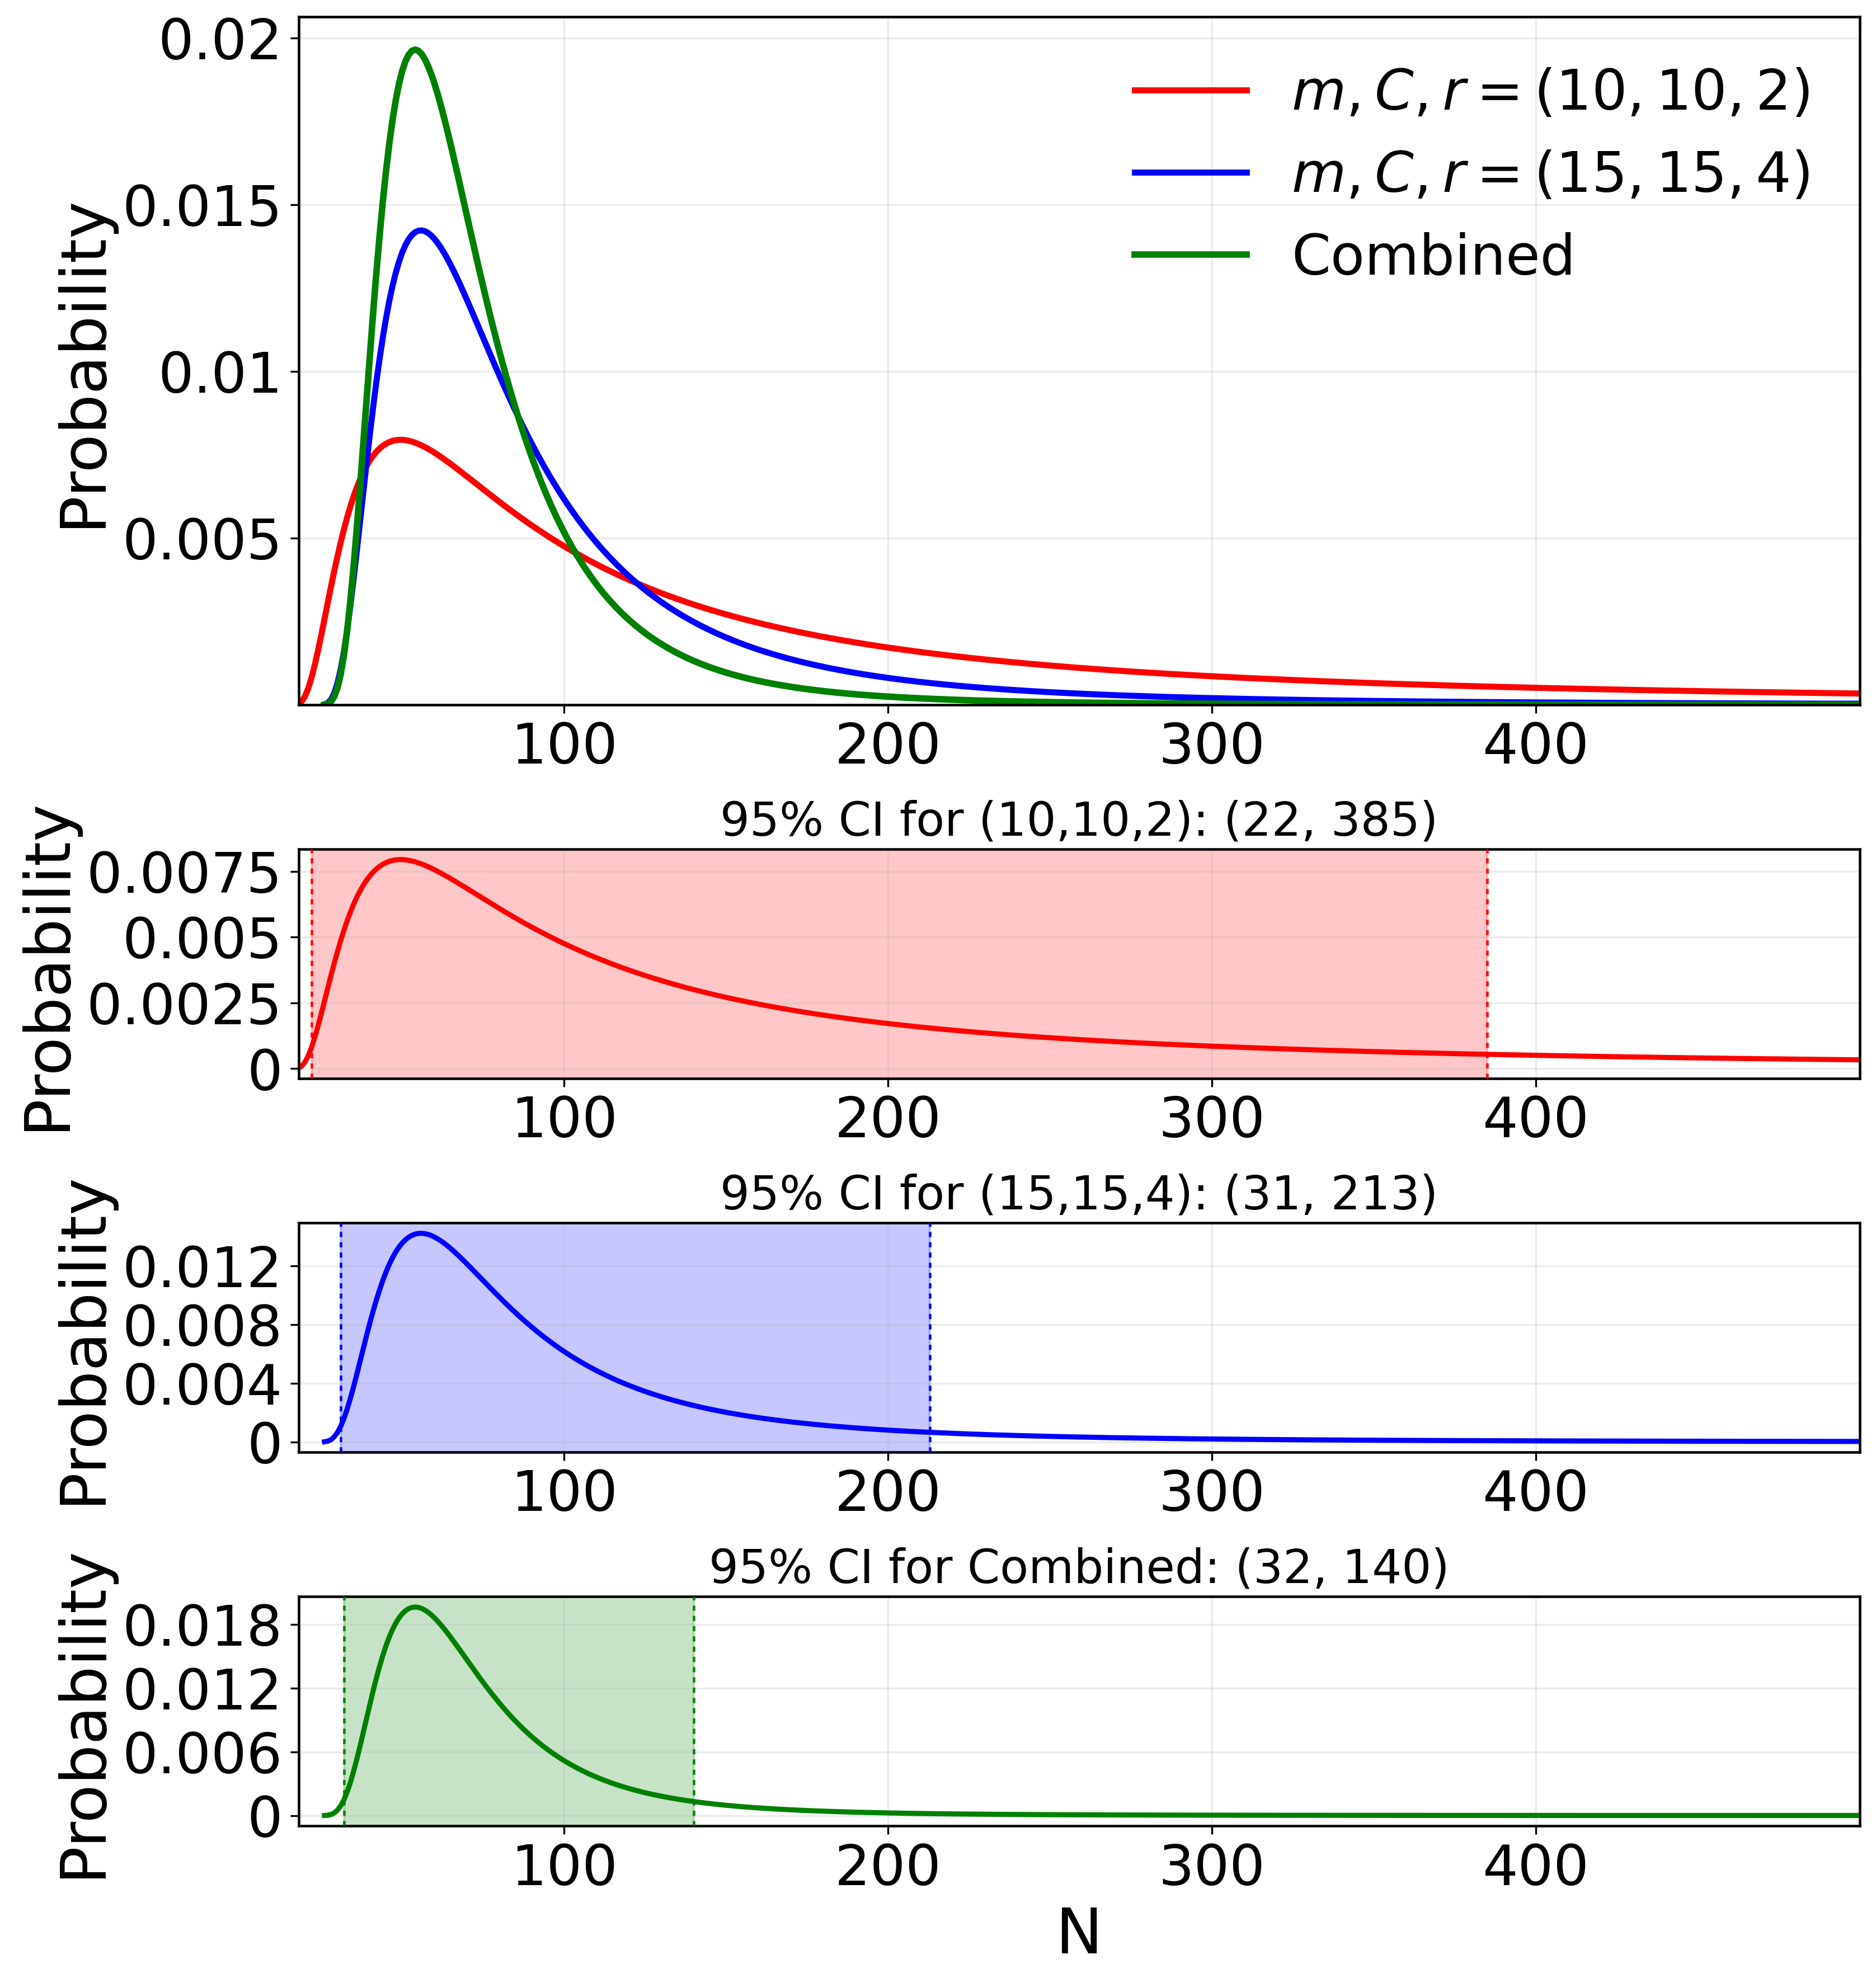

In [11]:
# Figure 3-A - Combining PMFs with close modes
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator, FuncFormatter

from ehpmarkrecap import ehp


def _add_ci_band(ax, lo, hi, color, alpha=0.18):
    """Vertical CI band + dashed boundary lines."""
    ax.axvspan(lo, hi, color=color, alpha=alpha, zorder=0.4)
    border_kw = dict(
        color=color,
        linestyle=(0, (2, 2)),
        linewidth=1.1,
        alpha=0.95,
        zorder=3,
    )
    ax.axvline(lo, **border_kw)
    ax.axvline(hi, **border_kw)


def plot_figure_3A(
    K=500,
    alpha_ci=0.05,   # 95% CI
    figsize=(12, 14),
    dpi=300,
    max_xticks=6,
    max_yticks_main=5,
    max_yticks_small=4,
    outpath=None,
    show=True,
):
    # Datasets
    d1 = (10, 10, 2)
    d2 = (15, 15, 4)

    # ehp results (bounded with K)
    res1 = ehp(d1, K=K, alpha=alpha_ci)
    res2 = ehp(d2, K=K, alpha=alpha_ci)
    # combined" posterior
    res12 = ehp([d1, d2], K=K, alpha=alpha_ci)

    x1, p1 = np.asarray(res1["domain"]), np.asarray(res1["pmf"])
    x2, p2 = np.asarray(res2["domain"]), np.asarray(res2["pmf"])
    x3, p3 = np.asarray(res12["domain"]), np.asarray(res12["pmf"])

    ci1 = (int(res1["ci_low"]), int(res1["ci_high"]))
    ci2 = (int(res2["ci_low"]), int(res2["ci_high"]))
    ci3 = (int(res12["ci_low"]), int(res12["ci_high"]))

    color_first = "red"
    color_second = "blue"
    color_combined = "green"

    rc = {
        "font.size": 26,
        "axes.titlesize": 20,
        "axes.labelsize": 27,
        "xtick.labelsize": 24,
        "ytick.labelsize": 24,
        "legend.fontsize": 24,
        "axes.linewidth": 1.1,
        "figure.dpi": dpi,
        "savefig.dpi": dpi,
    }

    with mpl.rc_context(rc):
        fig = plt.figure(figsize=figsize, constrained_layout=False)
        gs = gridspec.GridSpec(4, 1, height_ratios=[3, 1, 1, 1], hspace=0.42)

        # Main panel
        ax_main = plt.subplot(gs[0])
        ax_main.plot(x1, p1, lw=2.6, color=color_first, label=r"$m,C,r=(10,10,2)$")
        ax_main.plot(x2, p2, lw=2.6, color=color_second, label=r"$m,C,r=(15,15,4)$")
        ax_main.plot(x3, p3, lw=2.8, color=color_combined, label="Combined")

        ax_main.set_ylabel("Probability")

        ax_main.grid(True, alpha=0.25)
        ax_main.set_ylim(bottom=0)
        ax_main.set_xlim(min(x1[0], x2[0], x3[0]), K)

        ax_main.xaxis.set_major_locator(MaxNLocator(nbins=max_xticks, integer=True, prune="both"))
        ax_main.yaxis.set_major_locator(MaxNLocator(nbins=max_yticks_main, prune="both"))
        ax_main.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))

        ax_main.legend(frameon=False, loc="upper right")

        # Subpanel 1
        ax1 = plt.subplot(gs[1], sharex=ax_main)
        ax1.plot(x1, p1, lw=2.2, color=color_first)
        _add_ci_band(ax1, ci1[0], ci1[1], color=color_first, alpha=0.22)
        ax1.set_ylabel("Probability")
        ax1.set_title(f"95% CI for (10,10,2): {ci1}")
        ax1.grid(True, alpha=0.25)

        ax1.yaxis.set_major_locator(MaxNLocator(nbins=max_yticks_small, prune="both"))
        ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))

        # Subpanel 2
        ax2 = plt.subplot(gs[2], sharex=ax_main)
        ax2.plot(x2, p2, lw=2.2, color=color_second)
        _add_ci_band(ax2, ci2[0], ci2[1], color=color_second, alpha=0.22)
        ax2.set_ylabel("Probability")
        ax2.set_title(f"95% CI for (15,15,4): {ci2}")
        ax2.grid(True, alpha=0.25)

        ax2.yaxis.set_major_locator(MaxNLocator(nbins=max_yticks_small, prune="both"))
        ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))

        # Subpanel 3
        ax3 = plt.subplot(gs[3], sharex=ax_main)
        ax3.plot(x3, p3, lw=2.2, color=color_combined)
        _add_ci_band(ax3, ci3[0], ci3[1], color=color_combined, alpha=0.22)
        ax3.set_ylabel("Probability")
        ax3.set_xlabel("N")
        ax3.set_title(f"95% CI for Combined: {ci3}")
        ax3.grid(True, alpha=0.25)

        ax3.yaxis.set_major_locator(MaxNLocator(nbins=max_yticks_small, prune="both"))
        ax3.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))

        ax3.xaxis.set_major_locator(MaxNLocator(nbins=max_xticks, integer=True, prune="both"))

        # Tighten layout manually
        fig.tight_layout()

        if outpath:
            fig.savefig(outpath, bbox_inches="tight")

        if show:
            plt.show()

        return fig, (ax_main, ax1, ax2, ax3)


if __name__ == "__main__":
    plot_figure_3A(
        K=500,
        alpha_ci=0.05,          # 95% CI
        figsize=(12, 14),
        dpi=300,
        max_xticks=5,           # fewer x ticks
        max_yticks_main=5,
        max_yticks_small=4,     # fewer y ticks in the small panels
        outpath=None,
        show=True,
    )


C:\Users\Danial\AppData\Local\Temp\ipykernel_14220\1861133605.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


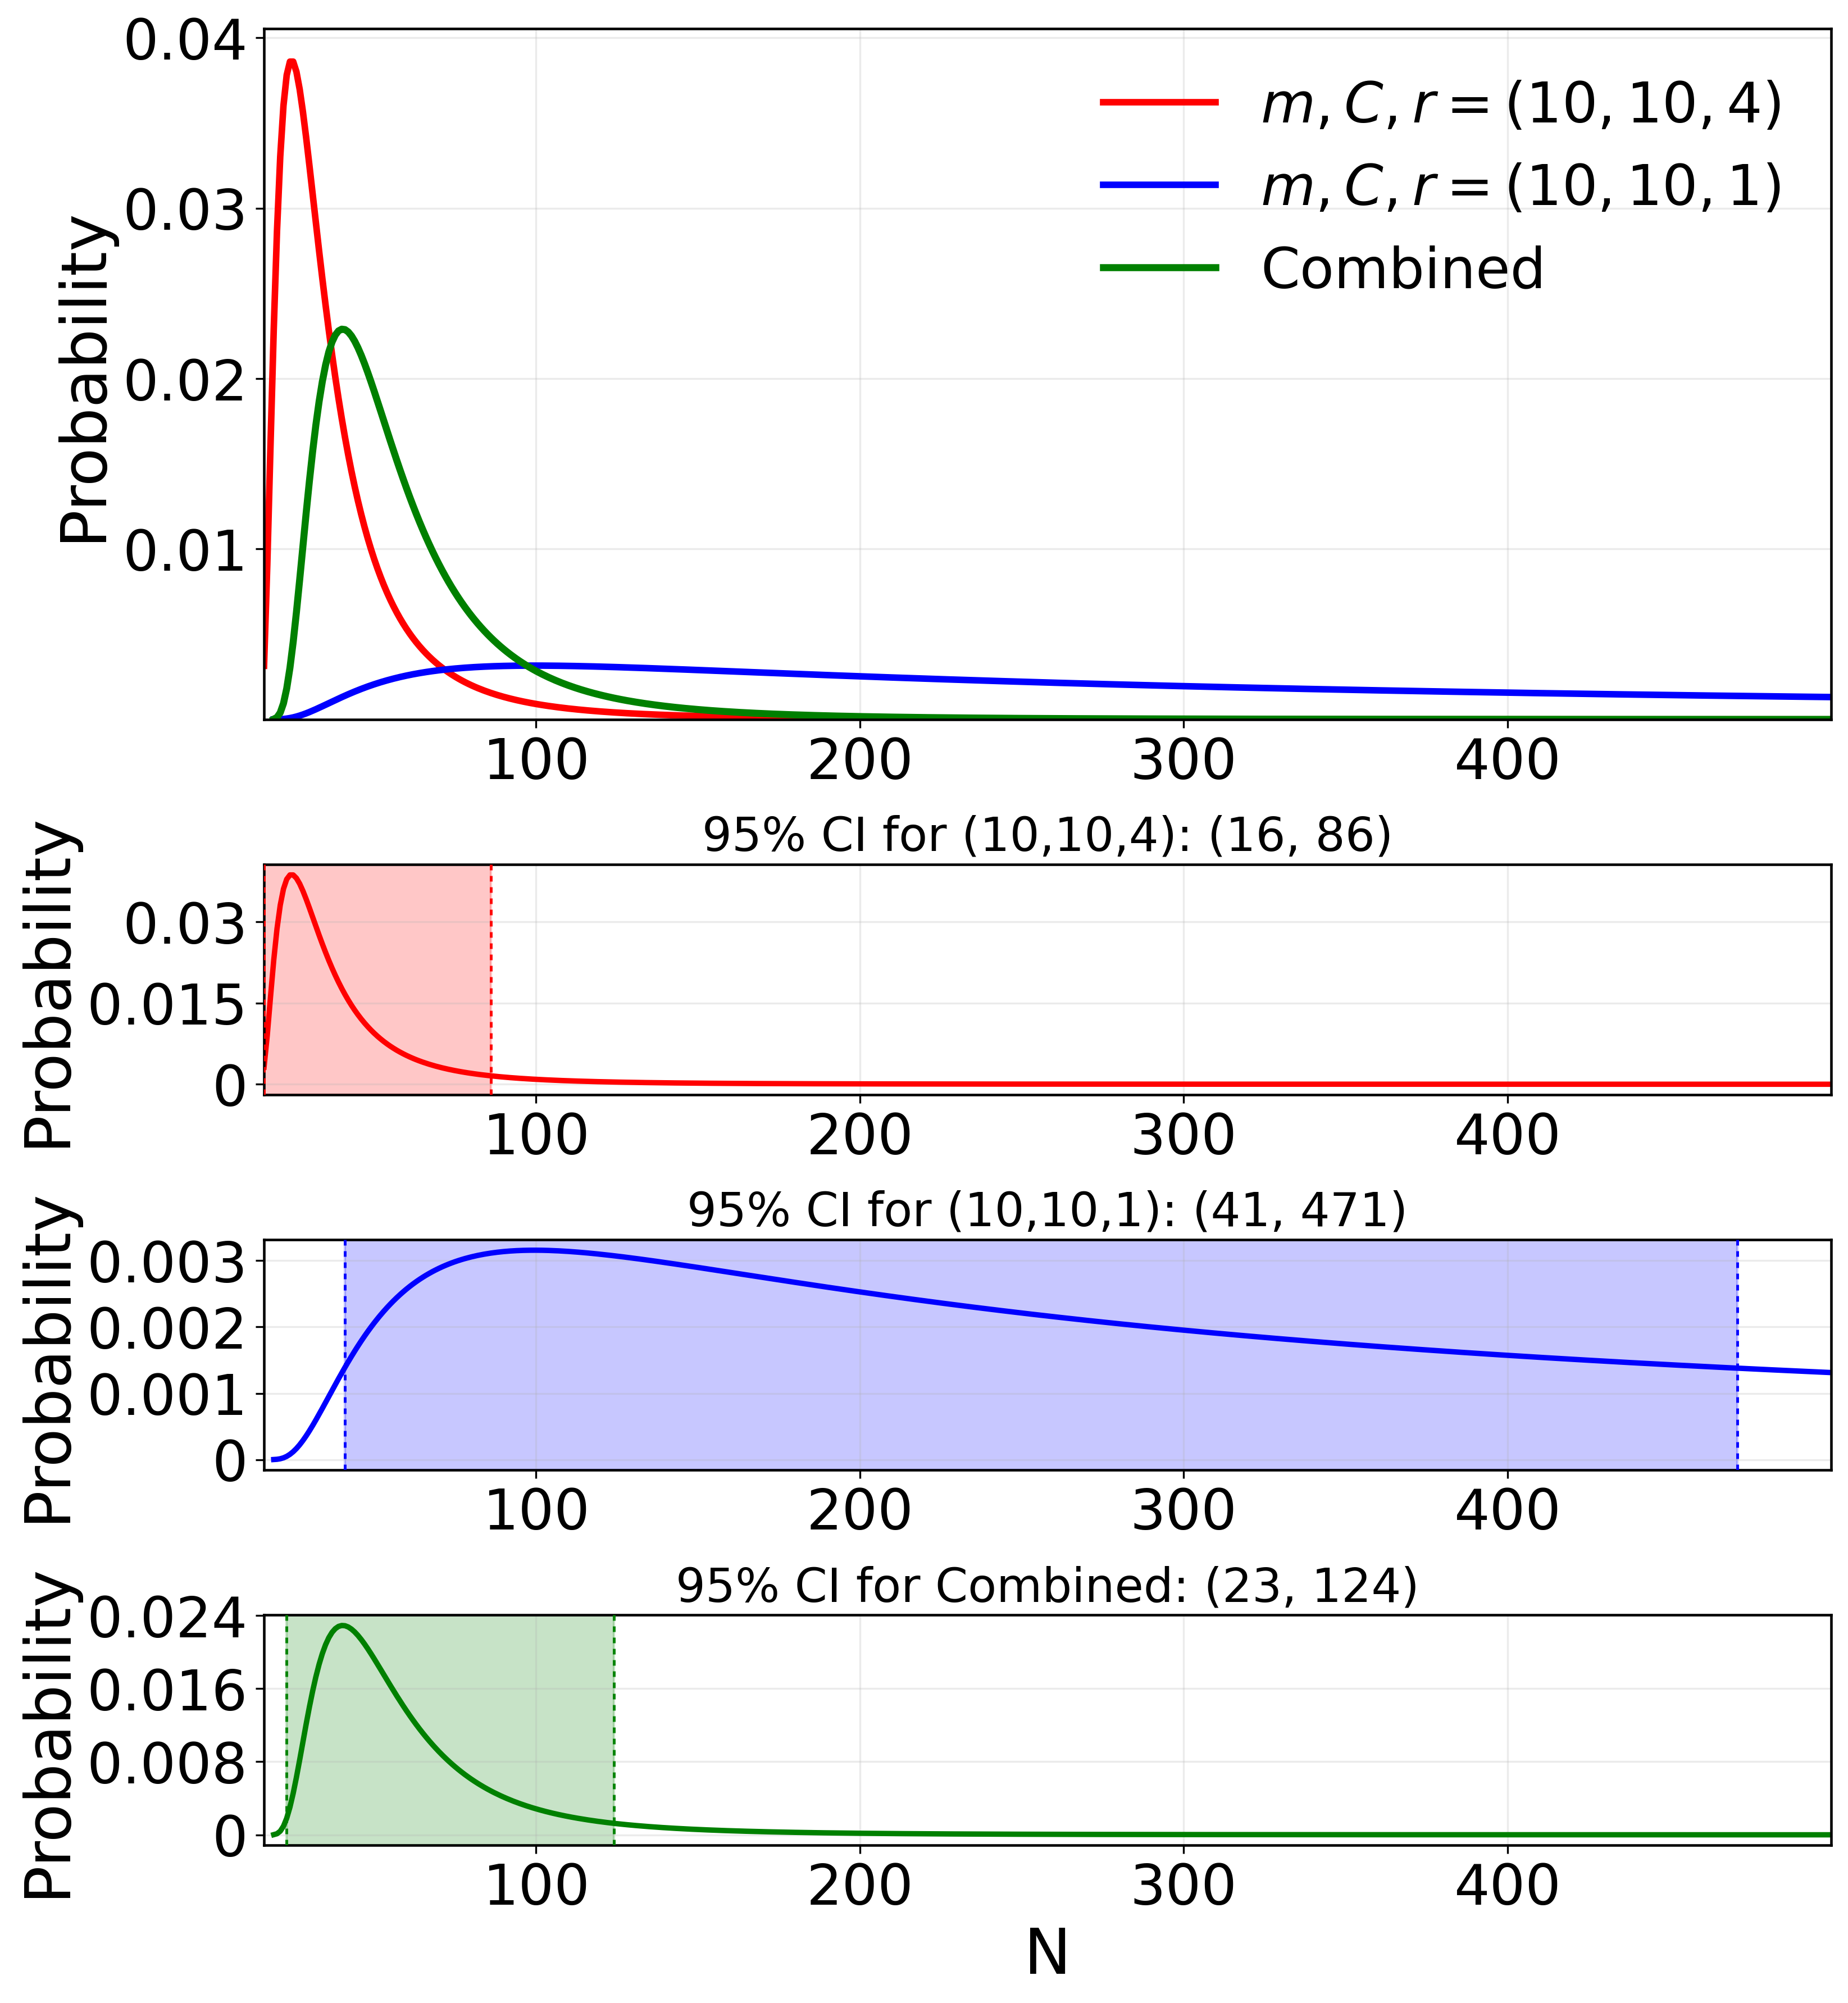

In [12]:
# Figure 3-B - Combining PMFs with far modes

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator, FuncFormatter

from ehpmarkrecap import ehp


def _add_ci_band(ax, lo, hi, color, alpha=0.22):
    """Vertical CI band + dashed boundary lines."""
    ax.axvspan(lo, hi, color=color, alpha=alpha, zorder=0.4)
    border_kw = dict(
        color=color,
        linestyle=(0, (2, 2)),  # short dashes
        linewidth=1.2,
        alpha=0.95,
        zorder=3,
    )
    ax.axvline(lo, **border_kw)
    ax.axvline(hi, **border_kw)


def plot_figure_3B(
    K=500,
    alpha_ci=0.05,        # 95% CI
    figsize=(12, 14),
    dpi=300,
    max_xticks=5,
    max_yticks_main=5,
    max_yticks_small=4,
    outpath=None,  
    show=True,
):
    # Datasets
    d1 = (10, 10, 4)
    d2 = (10, 10, 1)

    # ehp results
    res1 = ehp(d1, K=K, alpha=alpha_ci)
    res2 = ehp(d2, K=K, alpha=alpha_ci)
    res12 = ehp([d1, d2], K=K, alpha=alpha_ci)  # combined posterior (two datasets)

    x1, p1 = np.asarray(res1["domain"]), np.asarray(res1["pmf"])
    x2, p2 = np.asarray(res2["domain"]), np.asarray(res2["pmf"])
    x3, p3 = np.asarray(res12["domain"]), np.asarray(res12["pmf"])

    ci1 = (int(res1["ci_low"]), int(res1["ci_high"]))
    ci2 = (int(res2["ci_low"]), int(res2["ci_high"]))
    ci3 = (int(res12["ci_low"]), int(res12["ci_high"]))

    color_first = "red"
    color_second = "blue"
    color_combined = "green"

    # Stylw
    rc = {
        "font.size": 26,
        "axes.titlesize": 20,
        "axes.labelsize": 27,
        "xtick.labelsize": 24,
        "ytick.labelsize": 24,
        "legend.fontsize": 24,
        "axes.linewidth": 1.1,
        "figure.dpi": dpi,
        "savefig.dpi": dpi,
    }

    with mpl.rc_context(rc):
        fig = plt.figure(figsize=figsize, constrained_layout=False)
        gs = gridspec.GridSpec(4, 1, height_ratios=[3, 1, 1, 1], hspace=0.42)

        # Main Plot 
        ax_main = plt.subplot(gs[0])
        ax_main.plot(x1, p1, lw=2.8, color=color_first, label=r"$m,C,r=(10,10,4)$")
        ax_main.plot(x2, p2, lw=2.8, color=color_second, label=r"$m,C,r=(10,10,1)$")
        ax_main.plot(x3, p3, lw=3.0, color=color_combined, label="Combined")

        ax_main.set_ylabel("Probability")
        ax_main.grid(True, alpha=0.25)
        ax_main.set_ylim(bottom=0)

        xmin = min(int(x1[0]), int(x2[0]), int(x3[0]))
        ax_main.set_xlim(xmin, int(K))

        ax_main.xaxis.set_major_locator(MaxNLocator(nbins=max_xticks, integer=True, prune="both"))
        ax_main.yaxis.set_major_locator(MaxNLocator(nbins=max_yticks_main, prune="both"))
        ax_main.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))

        ax_main.legend(frameon=False, loc="upper right")

        # Subplot 1
        ax1 = plt.subplot(gs[1], sharex=ax_main)
        ax1.plot(x1, p1, lw=2.3, color=color_first)
        _add_ci_band(ax1, ci1[0], ci1[1], color=color_first, alpha=0.22)
        ax1.set_ylabel("Probability")
        ax1.set_title(f"95% CI for (10,10,4): {ci1}")
        ax1.grid(True, alpha=0.25)

        ax1.yaxis.set_major_locator(MaxNLocator(nbins=max_yticks_small, prune="both"))
        ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))

        # Subplot 2
        ax2 = plt.subplot(gs[2], sharex=ax_main)
        ax2.plot(x2, p2, lw=2.3, color=color_second)
        _add_ci_band(ax2, ci2[0], ci2[1], color=color_second, alpha=0.22)
        ax2.set_ylabel("Probability")
        ax2.set_title(f"95% CI for (10,10,1): {ci2}")
        ax2.grid(True, alpha=0.25)

        ax2.yaxis.set_major_locator(MaxNLocator(nbins=max_yticks_small, prune="both"))
        ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))

        # Subplot 3
        ax3 = plt.subplot(gs[3], sharex=ax_main)
        ax3.plot(x3, p3, lw=2.3, color=color_combined)
        _add_ci_band(ax3, ci3[0], ci3[1], color=color_combined, alpha=0.22)
        ax3.set_ylabel("Probability")
        ax3.set_xlabel("N")
        ax3.set_title(f"95% CI for Combined: {ci3}")
        ax3.grid(True, alpha=0.25)

        ax3.yaxis.set_major_locator(MaxNLocator(nbins=max_yticks_small, prune="both"))
        ax3.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))
        ax3.xaxis.set_major_locator(MaxNLocator(nbins=max_xticks, integer=True, prune="both"))

        fig.tight_layout()

        if outpath:
            fig.savefig(outpath, bbox_inches="tight")

        if show:
            plt.show()

        return fig, (ax_main, ax1, ax2, ax3)


if __name__ == "__main__":
    plot_figure_3B(
        K=500,
        alpha_ci=0.05,      # 95% CI
        figsize=(12, 14),
        dpi=300,
        max_xticks=5,       # fewer ticks
        max_yticks_main=5,
        max_yticks_small=4,
        outpath=None,
        show=True,
    )


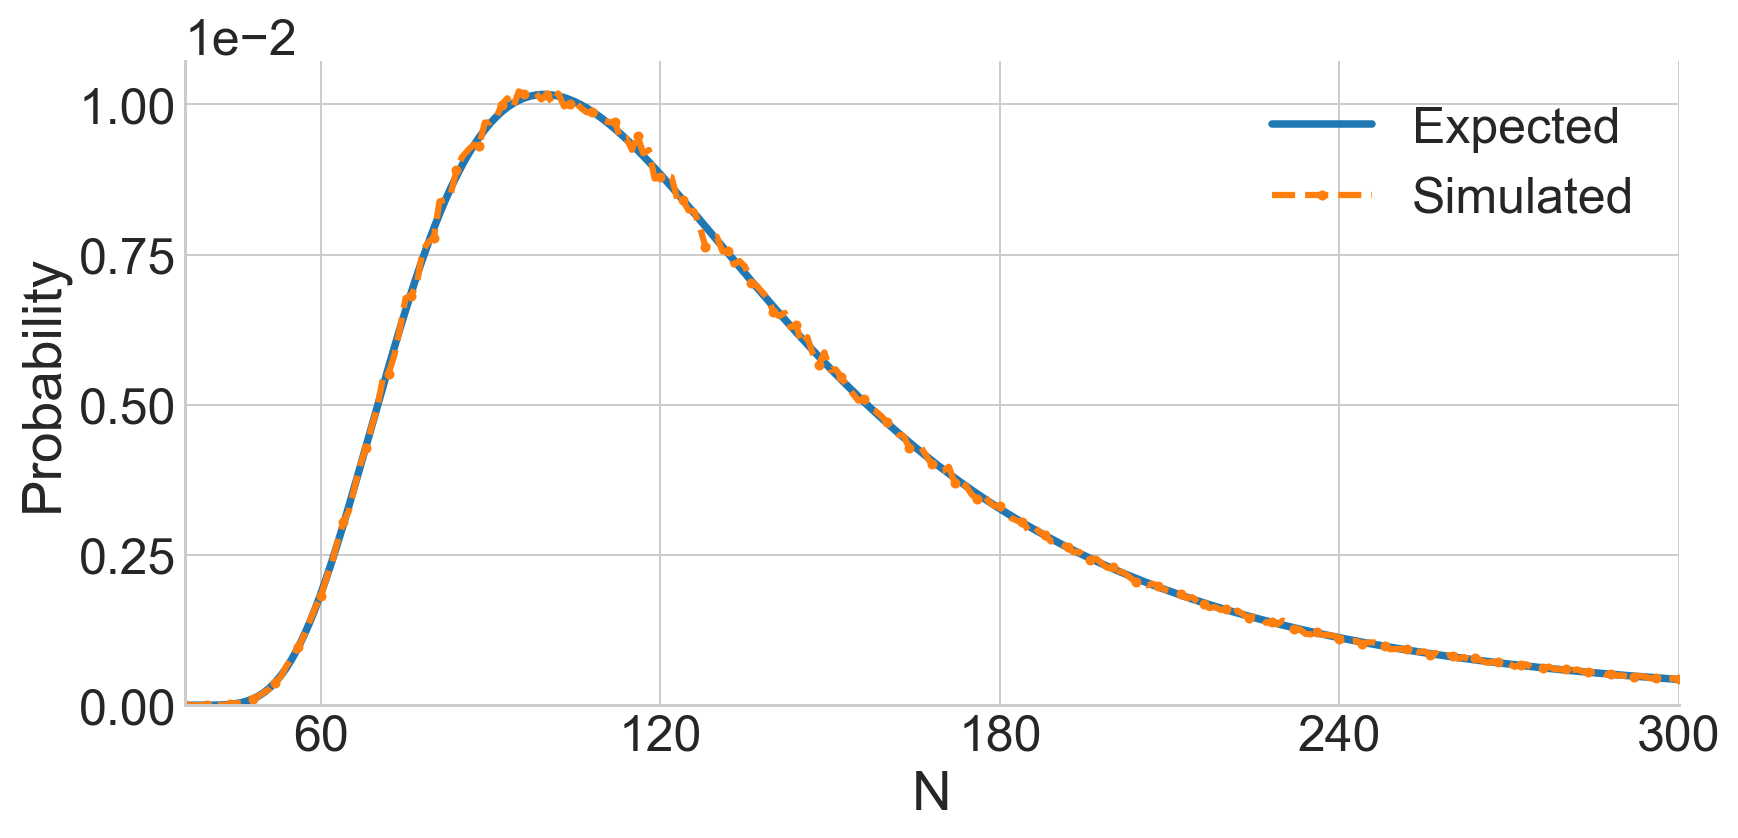

In [ ]:
# Figure 3-C - Simulation
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, ScalarFormatter

from ehpmarkrecap import ehp
from Simulation import simulate_r_values, normalized_probabilities_for_r


def combined_pmf_from_simulation(
    datasets,
    K: int,
    simulations: int = 50_000,
    seed: int = 42,
    phi: float = 1.0,
    omega: float = 1.0,
):
    """
      1) For each dataset, compute its normalized single PMF over N (p_norm).
      2) Combine by multiplying the normalized single PMFs elementwise.
      3) Normalize once more.
    """
    N_min = max(m + C - r for (m, C, r) in datasets)

    Ns_ref = None
    single_norm_pmfs = []

    for i, (m, C, r) in enumerate(datasets):
        r_by_N = simulate_r_values(
            N_min=N_min,
            K=K,
            m=m,
            C=C,
            phi=phi,
            omega=omega,
            Simulations=simulations,
            Seed=seed + i,
        )
        Ns, p_norm, _ = normalized_probabilities_for_r(r_by_N, r_target=r)

        if Ns_ref is None:
            Ns_ref = Ns
        elif not np.array_equal(Ns, Ns_ref):
            raise RuntimeError("N grids don't match across datasets. Check N_min/K usage.")

        single_norm_pmfs.append(p_norm)

    p_comb = np.ones_like(single_norm_pmfs[0], dtype=float)
    for p in single_norm_pmfs:
        p_comb *= p

    s = float(p_comb.sum())
    if s <= 0:
        raise RuntimeError("Combined simulated PMF sums to 0. Increase `simulations`.")
    p_comb /= s

    return Ns_ref, p_comb


def plot_sim_vs_expected(Ns, sim_pmf, exp_domain, exp_pmf, title: str):
    # Style
    plt.style.use("seaborn-v0_8-whitegrid")
    plt.rcParams.update(
        {
            "font.size": 18,
            "axes.titlesize": 20,
            "axes.labelsize": 22,
            "legend.fontsize": 20,
            "xtick.labelsize": 20,
            "ytick.labelsize": 20,
            "axes.linewidth": 1.2,
        }
    )

    fig, ax = plt.subplots(figsize=(10, 5), dpi=180)

    # Expected
    ax.plot(exp_domain, exp_pmf, linewidth=3, label="Expected")

    # Simulated (combined)
    markevery = max(1, len(Ns) // 60)  # avoid over-plotting markers
    ax.plot(
        Ns,
        sim_pmf,
        linewidth=2.5,
        linestyle="--",
        marker="o",
        markersize=3,
        markevery=markevery,
        label="Simulated",
    )

    ax.set_title(title)
    ax.set_xlabel("N")
    ax.set_ylabel("Probability")

    # Max 5 ticks each axis
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))

    ax.set_xlim(exp_domain[0], exp_domain[-1])
    ax.set_ylim(bottom=0)

    ax.legend(frameon=False, loc="best")

    # Slightly cleaner frame
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()
    return fig, ax


if __name__ == "__main__":
    datasets = [(20, 20, 4), (10, 20, 2)]
    K = 300

    # Simulated
    Ns_sim, pmf_sim = combined_pmf_from_simulation(
        datasets=datasets,
        K=K,
        simulations=50_000,
        seed=42,
        phi=1.0,
        omega=1.0,
    )

    # Expected
    res = ehp(datasets, K=K)
    exp_domain = res["domain"]
    exp_pmf = res["pmf"]

    plot_sim_vs_expected(
        Ns=Ns_sim,
        sim_pmf=pmf_sim,
        exp_domain=exp_domain,
        exp_pmf=exp_pmf,
        title=None,
    )
    plt.show()


In [ ]:
# Figure 3-D - Real data - Step 1

# Extract data from CSV that shows presence and absence of each individual (0/1) in each capture.

import pandas as pd


def process_mark_recapture(
    filepath: str,
    sheet_name: str = 0,
    id_col: str = 'indiv',
    sex_col: str = 'Sex',
    date_cols: list = None,
    mark_span: int = 1,
    capture_span: int = 1
) -> pd.DataFrame:
    raw = pd.read_excel(filepath, sheet_name=sheet_name)
    if isinstance(raw, dict):
        df = next(iter(raw.values()))
    else:
        df = raw
    if date_cols is None:
        exclude = {id_col}
        if sex_col in df.columns:
            exclude.add(sex_col)
        date_cols = [c for c in df.columns if c not in exclude]

    records = []

    i = 0
    total = len(date_cols)
    group_num = 1
    while i + mark_span + capture_span <= total:
        marks = date_cols[i : i + mark_span]
        caps = date_cols[i + mark_span : i + mark_span + capture_span]

  
        marked_inds = set()
        captured_inds = set()
        for _, row in df[[id_col] + marks].iterrows():
            if any(row[d] == 1 for d in marks):
                marked_inds.add(row[id_col])
        for _, row in df[[id_col] + caps].iterrows():
            if any(row[d] == 1 for d in caps):
                captured_inds.add(row[id_col])

        m = len(marked_inds)
        C = len(captured_inds)
        r = len(marked_inds & captured_inds)

        records.append({
            'group': group_num,
            'marks': marks,
            'captures': caps,
            'm': m,
            'C': C,
            'r': r
        })

        i += mark_span + capture_span
        group_num += 1

    result_df = pd.DataFrame(records)
    return result_df


if __name__ == '__main__':
    filepath = r"A:\Research\1\Latex\Manuscrpt 4.0\Main\Used Data\Data_Khelifa_et_al._2021_Sci.Rep.xlsx"
    df_out = process_mark_recapture(filepath, sheet_name=0)
    print(df_out)


    group  marks captures   m   C   r
0       1  [132]    [133]  39  49  14
1       2  [134]    [135]  47  25  14
2       3  [136]    [137]  34  50  18
3       4  [138]    [139]  50  64  24
4       5  [140]    [141]  39  28  15
5       6  [142]    [143]  27  33  12
6       7  [144]    [145]  35  35  13
7       8  [146]    [147]  42  51  20
8       9  [148]    [149]  42  41  20
9      10  [150]    [151]  32  45  17
10     11  [152]    [154]   1  22   1
11     12  [155]    [156]  22  16   8


102 103.2897423159838 103 96 112


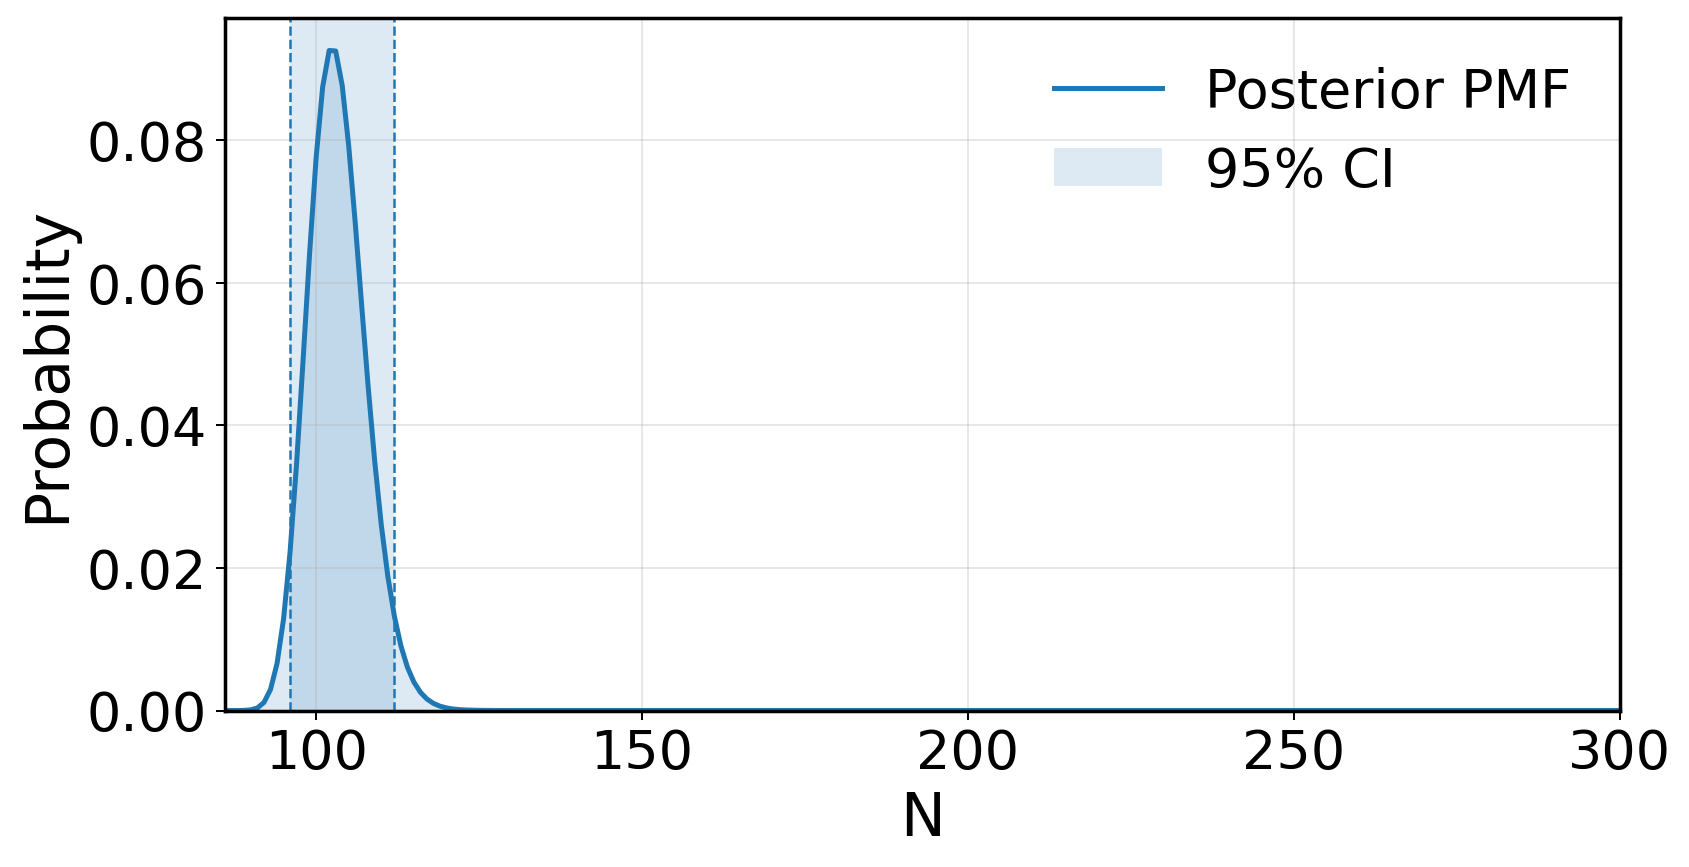

(<Figure size 1800x900 with 1 Axes>, <Axes: xlabel='N', ylabel='Probability'>)

In [ ]:
# Figure 3-D - Real data - Step 2

from ehpmarkrecap import ehp

# Data sets

data_sets4 = ((39,49,14),(47,25,14),(34,50,18),(50,60,24),(39,28,15),(27,33,12),(35,35,13),(42,51,20),(42,41,20),(32,45,17))


def Plot_MR(results, ax=None, title=None, figsize=(10, 5), show=True):
    """
    Minimal professional plot for MR posterior values + Mode/Mean/Median/CI.

    Parameters
    ----------
    results : dict
        Output of ehp(...)
    ax : matplotlib.axes.Axes or None
    title : str or None
    figsize : tuple
    show : bool

    Returns
    -------
    (fig, ax)
    """
    domain = np.asarray(results["domain"])
    pmf = np.asarray(results["pmf"])

    mode = results["mode"]
    mean = results["mean"]
    median = results["median"]
    ci_low = results["ci_low"]
    ci_high = results["ci_high"]
    alpha = results.get("alpha", None)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    ax.plot(domain, pmf, linewidth=2, label="Posterior PMF")
    ax.fill_between(domain, pmf, alpha=0.15)

    # CI shading
    if alpha is not None:
        ax.axvspan(ci_low, ci_high, alpha=0.15, label=f"{int(round((1-alpha)*100))}% CI")
    else:
        ax.axvspan(ci_low, ci_high, alpha=0.15, label="CI")

    ax.axvline(ci_low, linestyle="--", linewidth=1)
    ax.axvline(ci_high, linestyle="--", linewidth=1)

    ax.set_xlabel("N")
    ax.set_ylabel("Probability")
    ax.set_title(title)

    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)
    ax.set_xlim(domain[0], domain[-1])
    ax.set_ylim(bottom=0)

    if show:
        plt.show()

    return fig, ax

# Main
res = ehp(data_sets4, K=300, alpha=0.05)
print(res["mode"], res["mean"], res["median"], res["ci_low"], res["ci_high"])
Plot_MR(res)

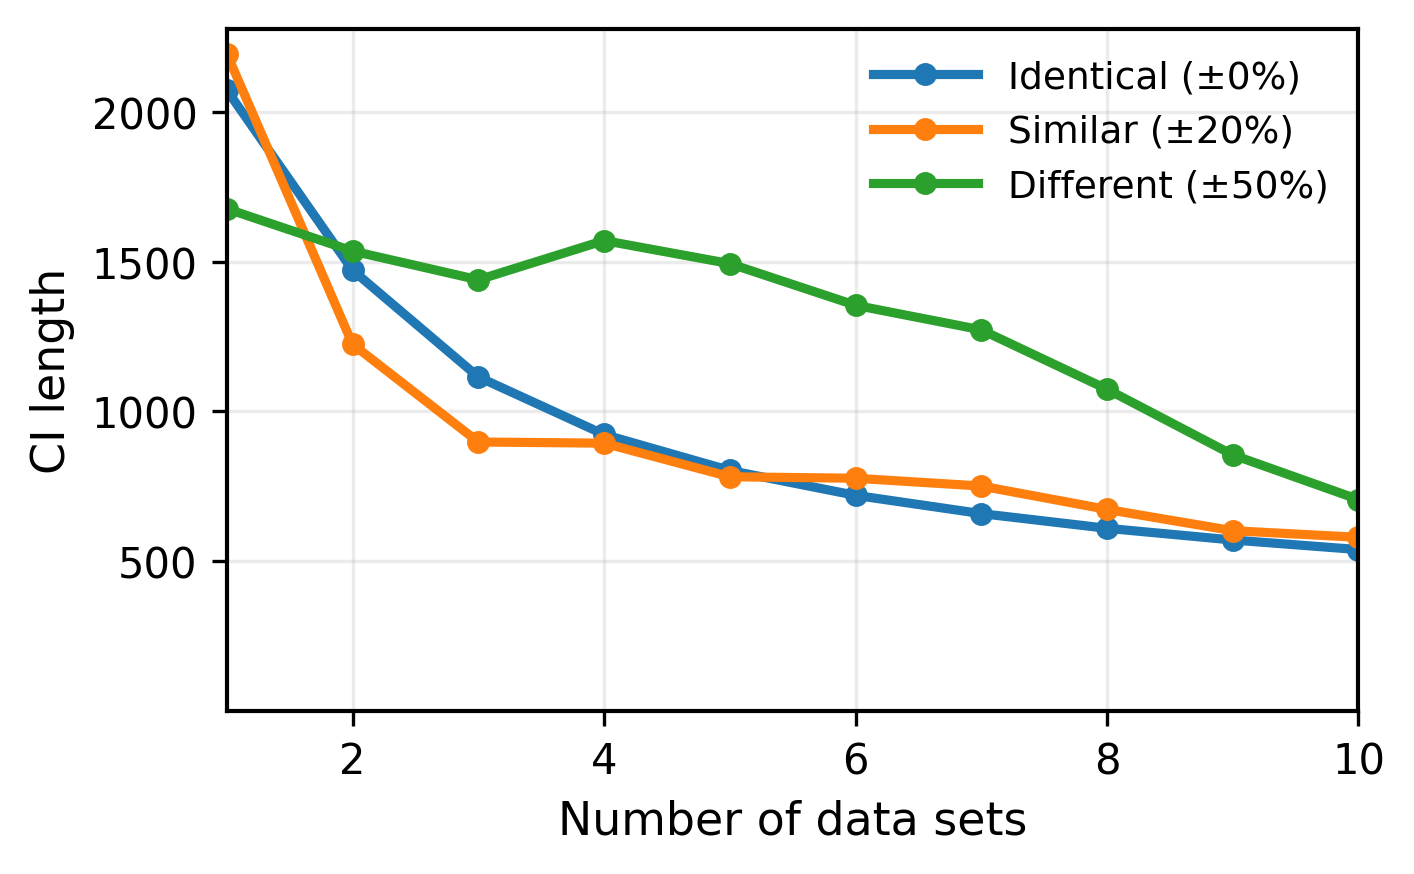

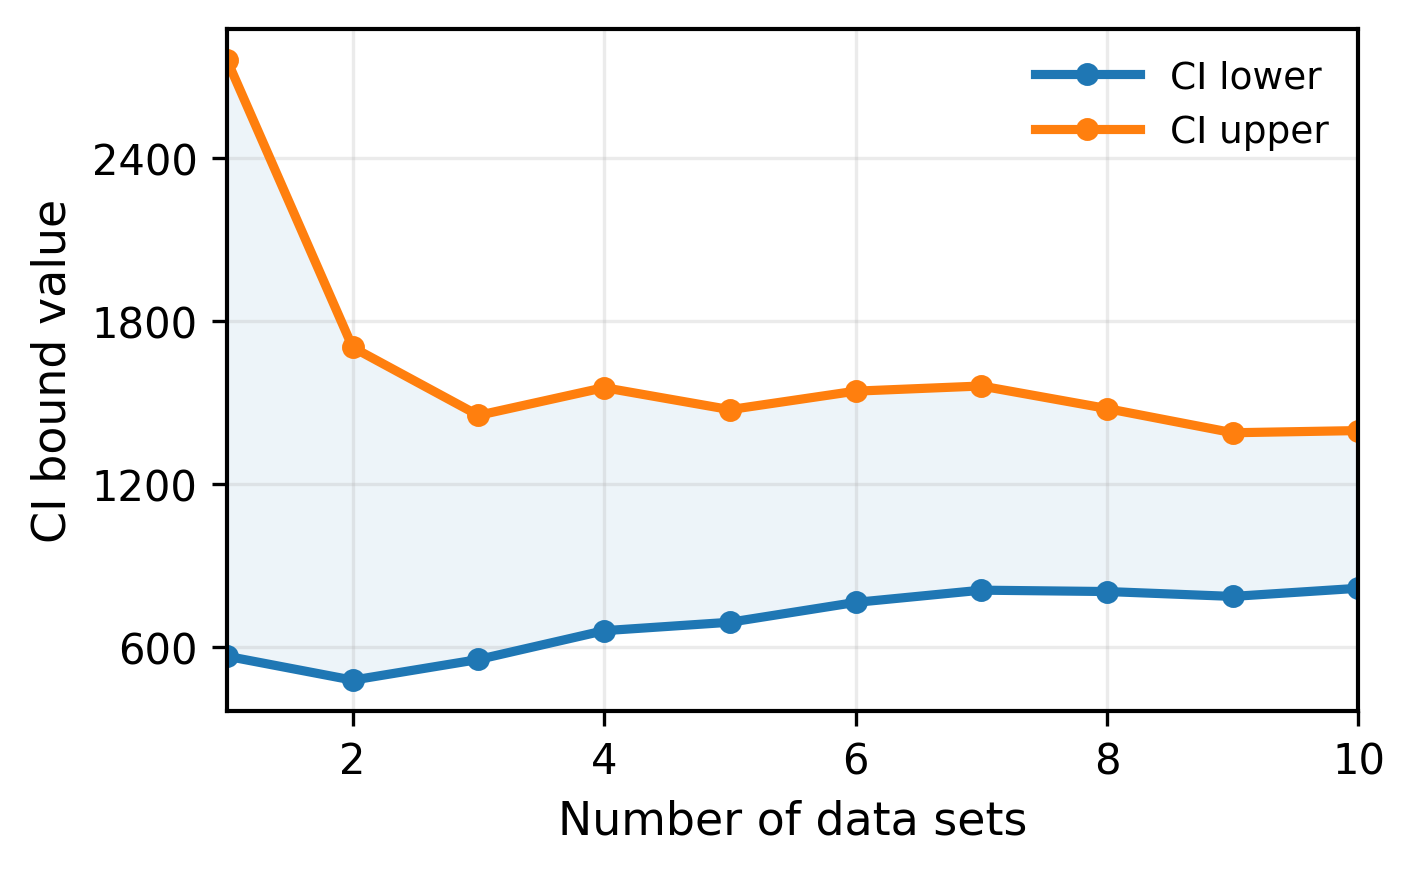

In [13]:
# Figure 3-E,F - Sensitivity

"""
CI trend vs number of combined PMFs (datasets)

- Base (m, C, r) = (100, 50, 5)
- K = 3000 (required for multiple datasets)
- Cases:
  1) identical: 0% perturbation
  2) similar:   random ±20% perturbation
  3) different: random ±50% perturbation

Plot 1:
- x: Number of data sets (1..10), ticks at 2,4,6,8,10
- y: CI length (ci_high - ci_low)
- three curves: identical / similar / different
- no title, no stats

Plot 2:
- x: Number of data sets (1..10), ticks at 2,4,6,8,10
- y: CI bound value
- two curves: ci_low and ci_high for the "similar" case
- no title, no stats
"""

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter

from ehpmarkrecap import ehp


def _perturb_triplet(base, pct, rng):
    """
    Random multiplicative perturbation of (m, C, r) within ±pct, rounded to ints.
    Enforces r <= min(m, C) and keeps values >= 1.
    """
    m0, C0, r0 = base

    if pct <= 0:
        return int(m0), int(C0), int(r0)

    factors = 1.0 + rng.uniform(-pct, pct, size=3)
    m = int(max(1, round(m0 * factors[0])))
    C = int(max(1, round(C0 * factors[1])))
    r = int(max(1, round(r0 * factors[2])))

    # enforce MR constraint
    r = int(min(r, m, C))
    # also ensure m, C not below r
    m = int(max(m, r))
    C = int(max(C, r))

    return m, C, r


def plot_ci_trends_combined_pmfs(
    base=(100, 50, 5),
    K=3000,
    n_max=10,
    ci_level=0.95,
    seed=123,
    pct_similar=0.10,
    pct_different=0.30,
    figsize1=(4.6, 2.8),
    figsize2=(4.6, 2.8),
    dpi=300,
    outpath1=None,
    outpath2=None,
    show=True,
):
    alpha = 1.0 - float(ci_level)
    rng = np.random.default_rng(seed)

    # Pre-generate 10 datasets for each case so n=1..10 uses prefixes
    datasets_identical = [tuple(base) for _ in range(n_max)]
    datasets_similar   = [_perturb_triplet(base, pct_similar, rng) for _ in range(n_max)]
    datasets_different = [_perturb_triplet(base, pct_different, rng) for _ in range(n_max)]

    ns = np.arange(1, n_max + 1, dtype=int)

    len_identical = np.zeros(n_max, dtype=int)
    len_similar   = np.zeros(n_max, dtype=int)
    len_different = np.zeros(n_max, dtype=int)

    low_similar = np.zeros(n_max, dtype=int)
    high_similar = np.zeros(n_max, dtype=int)

    # Compute CI summaries for prefixes of length n
    for i, n in enumerate(ns):
        res_id = ehp(datasets_identical[:n], K=K, alpha=alpha)
        res_si = ehp(datasets_similar[:n],   K=K, alpha=alpha)
        res_di = ehp(datasets_different[:n], K=K, alpha=alpha)

        len_identical[i] = int(res_id["ci_high"] - res_id["ci_low"])
        len_similar[i]   = int(res_si["ci_high"] - res_si["ci_low"])
        len_different[i] = int(res_di["ci_high"] - res_di["ci_low"])

        low_similar[i]  = int(res_si["ci_low"])
        high_similar[i] = int(res_si["ci_high"])

    # Small-panel friendly styling
    rc = {
        "font.size": 11,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "axes.linewidth": 1.0,
        "figure.dpi": dpi,
        "savefig.dpi": dpi,
    }

    x_ticks = [2, 4, 6, 8, 10]

    with mpl.rc_context(rc):
        # Plot 1: CI length vs number of datasets (3 curves)
        fig1, ax1 = plt.subplots(figsize=figsize1, constrained_layout=True)
        ax1.plot(ns, len_identical, linewidth=2.2, marker="o", markersize=4.5, label="Identical (±0%)")
        ax1.plot(ns, len_similar,   linewidth=2.2, marker="o", markersize=4.5, label="Similar (±20%)")
        ax1.plot(ns, len_different, linewidth=2.2, marker="o", markersize=4.5, label="Different (±50%)")

        ax1.set_xlabel("Number of data sets")
        ax1.set_ylabel("CI length")
        ax1.set_xlim(1, n_max)
        ax1.set_xticks(x_ticks)
        ax1.set_ylim(bottom=0)

        ax1.yaxis.set_major_locator(MaxNLocator(nbins=5, prune="both"))
        ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))
        ax1.grid(True, alpha=0.25)

        ax1.legend(frameon=False, ncol=1, loc="upper right", handlelength=2.8, borderaxespad=0.4)

        if outpath1:
            fig1.savefig(outpath1, bbox_inches="tight")

        # Plot 2: CI bounds vs number of datasets
        fig2, ax2 = plt.subplots(figsize=figsize2, constrained_layout=True)
        ax2.plot(ns, low_similar,  linewidth=2.2, marker="o", markersize=4.5, label="CI lower")
        ax2.plot(ns, high_similar, linewidth=2.2, marker="o", markersize=4.5, label="CI upper")
        ax2.fill_between(ns, low_similar, high_similar, alpha=0.08)

        ax2.set_xlabel("Number of data sets")
        ax2.set_ylabel("CI bound value")
        ax2.set_xlim(1, n_max)
        ax2.set_xticks(x_ticks)

        ax2.yaxis.set_major_locator(MaxNLocator(nbins=5, prune="both"))
        ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))
        ax2.grid(True, alpha=0.25)

        ax2.legend(frameon=False, ncol=1, loc="upper right", handlelength=2.8, borderaxespad=0.4)

        if outpath2:
            fig2.savefig(outpath2, bbox_inches="tight")

        if show:
            plt.show()

    return (fig1, ax1), (fig2, ax2)


if __name__ == "__main__":
    plot_ci_trends_combined_pmfs(
        base=(100, 50, 5),
        K=3000,
        n_max=10,
        ci_level=0.95,
        seed=123,
        pct_similar=0.20,
        pct_different=0.50,
        outpath1=None,
        outpath2=None,
        show=True
    )


In [1]:
# Table 3

from ehpmarkrecap import ehp
 
K = 10000
# Columns
print("m1,C1,r1","|","CI","|","m2,C2,r2","|","CI","|","m3,C3,r3","|","CI","|","Combined Mode","|","Combined Mean","|","Combined Median","|","Combined CI")
print("-"*100)

def combine2(data1,data2):
    data4=(data1,data2)
    res1 = ehp(data1, K=K, phi=False, omega=False, alpha=0.05)
    res2 = ehp(data2, K=K, phi=False, omega=False, alpha=0.05)
    res4 = ehp(data4, K=K, phi=False, omega=False, alpha=0.05)
    print(data1,"|",(res1["ci_low"], res1["ci_high"]),"|",data2,"|",(res2["ci_low"], res2["ci_high"]),"|", "--","|","--","|", res4["mode"], "|", res4["mean"], "|", res4["median"], "|", (res4["ci_low"], res4["ci_high"]))

def combine3(data1,data2,data3):
    data4=[data1,data2,data3]
    res1 = ehp(data1, K=K, phi=False, omega=False, alpha=0.05)
    res2 = ehp(data2, K=K, phi=False, omega=False, alpha=0.05)
    res3 = ehp(data3, K=K, phi=False, omega=False, alpha=0.05)
    res4 = ehp(data4, K=K, phi=False, omega=False, alpha=0.05)
    print(data1,"|",(res1["ci_low"], res1["ci_high"]),"|",data2,"|",(res2["ci_low"], res2["ci_high"]),"|", data3,"|",(res3["ci_low"], res3["ci_high"]), "|", res4["mode"], "|", res4["mean"], "|", res4["median"], "|", (res4["ci_low"], res4["ci_high"]))

m, C, r = 100, 10, 1
data1=(m,C,r)
m, C, r = 100, 10, 1
data2=(m,C,r)
combine2(data1,data2)

m, C, r = 100, 20, 2
data1=(m,C,r)
m, C, r = 100, 30, 3
data2=(m,C,r)
combine2(data1,data2)

m, C, r = 100, 50, 5
data1=(m,C,r)
m, C, r = 100, 60, 6
data2=(m,C,r)
combine2(data1,data2)

m, C, r = 50, 50, 25
data1=(m,C,r)
m, C, r = 100, 100, 10
data2=(m,C,r)
combine2(data1,data2)

m, C, r = 10, 10, 1
data1=(m,C,r)
m, C, r = 10, 10, 5
data2=(m,C,r)
combine2(data1,data2)

###########################################

m, C, r = 100, 10, 1
data1=(m,C,r)
m, C, r = 100, 10, 1
data2=(m,C,r)
m, C, r = 100, 10, 1
data3=(m,C,r)
combine3(data1,data2,data3)

m, C, r = 100, 30, 3
data1=(m,C,r)
m, C, r = 100, 40, 4
data2=(m,C,r)
m, C, r = 100, 50, 5
data3=(m,C,r)
combine3(data1,data2,data3)

m, C, r = 100, 80, 8
data1=(m,C,r)
m, C, r = 100, 90, 9
data2=(m,C,r)
m, C, r = 100, 100, 10
data3=(m,C,r)
combine3(data1,data2,data3)

m, C, r = 500, 500, 50
data1=(m,C,r)
m, C, r = 100, 10, 2
data2=(m,C,r)
m, C, r = 5, 5, 3
data3=(m,C,r)
combine3(data1,data2,data3)

m, C, r = 100, 80, 8
data1=(m,C,r)
m, C, r = 100, 90, 9
data2=(m,C,r)
m, C, r = 100, 100, 10
data3=(m,C,r)
combine3(data1,data2,data3)

m1,C1,r1 | CI | m2,C2,r2 | CI | m3,C3,r3 | CI | Combined Mode | Combined Mean | Combined Median | Combined CI
----------------------------------------------------------------------------------------------------
(100, 10, 1) | (316, 9081) | (100, 10, 1) | (316, 9081) | -- | -- | 999 | 2945.8325315132756 | 2195 | (328, 7925)
(100, 20, 2) | (331, 7918) | (100, 30, 3) | (362, 6060) | -- | -- | 1000 | 1607.537640482593 | 1337 | (442, 3500)
(100, 50, 5) | (449, 3470) | (100, 60, 6) | (486, 2918) | -- | -- | 999 | 1204.7561998726978 | 1127 | (591, 1990)
(50, 50, 25) | (85, 128) | (100, 100, 10) | (586, 2059) | -- | -- | 424 | 444.02973543516896 | 437 | (335, 566)
(10, 10, 1) | (25, 8118) | (10, 10, 5) | (15, 48) | -- | -- | 34 | 46.69783202924805 | 41 | (22, 86)
(100, 10, 1) | (316, 9081) | (100, 10, 1) | (316, 9081) | (100, 10, 1) | (316, 9081) | 999 | 2261.0699844345168 | 1691 | (356, 6089)
(100, 30, 3) | (362, 6060) | (100, 40, 4) | (406, 4437) | (100, 50, 5) | (449, 3470) | 999 | 1185.541

<>:78: SyntaxWarning: invalid escape sequence '\o'
<>:109: SyntaxWarning: invalid escape sequence '\p'
<>:121: SyntaxWarning: invalid escape sequence '\o'
<>:78: SyntaxWarning: invalid escape sequence '\o'
<>:109: SyntaxWarning: invalid escape sequence '\p'
<>:121: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Danial\AppData\Local\Temp\ipykernel_6840\3088679452.py:78: SyntaxWarning: invalid escape sequence '\o'
  ax_main.plot(x3, p3, lw=3.0, color=color_combined, label="$m,C,r,\omega=100,100,10,1.2$")
C:\Users\Danial\AppData\Local\Temp\ipykernel_6840\3088679452.py:109: SyntaxWarning: invalid escape sequence '\p'
  ax2.set_title(f"$m,C,r,\phi=100,100,10,0.8$: {ci2}")
C:\Users\Danial\AppData\Local\Temp\ipykernel_6840\3088679452.py:121: SyntaxWarning: invalid escape sequence '\o'
  ax3.set_title(f"$m,C,r,\omega=100,100,10,1.2$: {ci3}")
C:\Users\Danial\AppData\Local\Temp\ipykernel_6840\3088679452.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layou

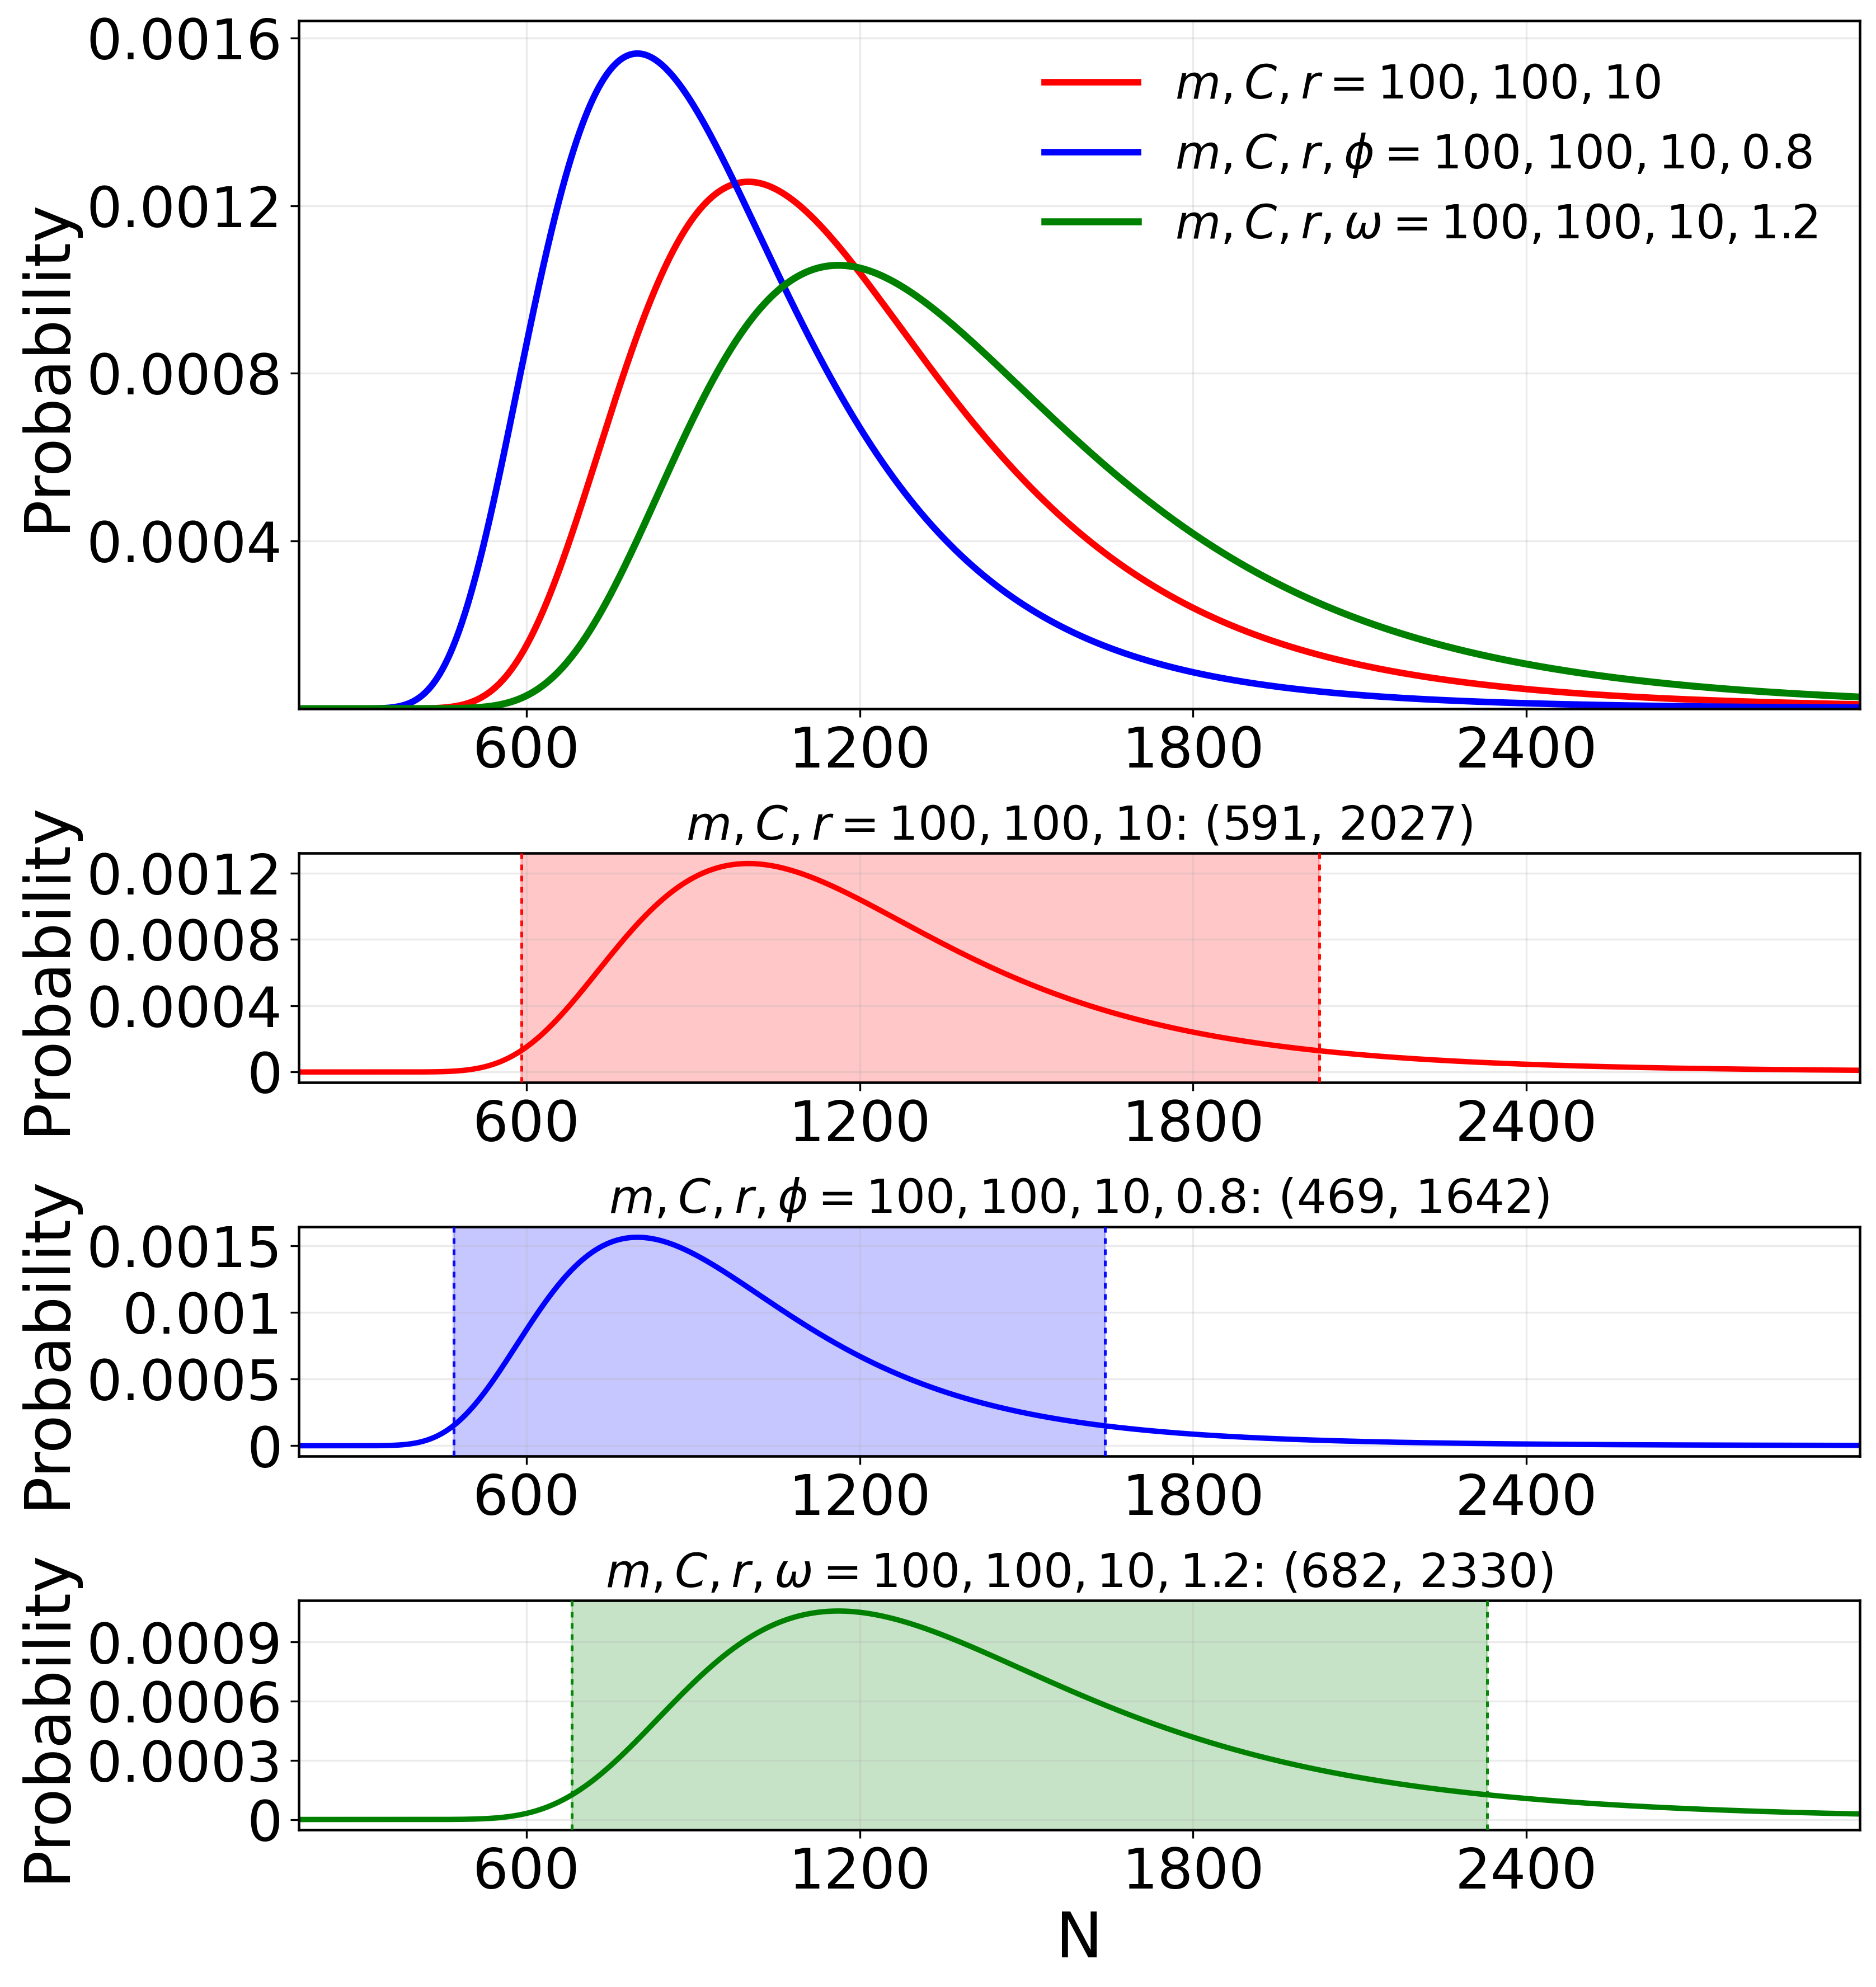

In [ ]:
# Figure 4-A - Impact of phi and omega

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator, FuncFormatter

from ehpmarkrecap import ehp


def _add_ci_band(ax, lo, hi, color, alpha=0.22):
    """Vertical CI band + dashed boundary lines."""
    ax.axvspan(lo, hi, color=color, alpha=alpha, zorder=0.4)
    border_kw = dict(
        color=color,
        linestyle=(0, (2, 2)),  # short dashes
        linewidth=1.2,
        alpha=0.95,
        zorder=3,
    )
    ax.axvline(lo, **border_kw)
    ax.axvline(hi, **border_kw)


def plot_figure_3B(
    K=3000,
    alpha_ci=0.05,        # 95% CI
    figsize=(12, 14),
    dpi=300,
    max_xticks=5,
    max_yticks_main=5,
    max_yticks_small=4,
    outpath=None,  
    show=True,
):
    # Datasets
    d1 = (100, 100, 10)

    # ehp results
    res1 = ehp(d1, K=K, alpha=alpha_ci)
    res2 = ehp(d1, K=K, alpha=alpha_ci, phi=0.8)
    res3 = ehp(d1, K=K, alpha=alpha_ci, phi=False, omega=1.2)  # combined posterior (two datasets)

    x1, p1 = np.asarray(res1["domain"]), np.asarray(res1["pmf"])
    x2, p2 = np.asarray(res2["domain"]), np.asarray(res2["pmf"])
    x3, p3 = np.asarray(res3["domain"]), np.asarray(res3["pmf"])

    ci1 = (int(res1["ci_low"]), int(res1["ci_high"]))
    ci2 = (int(res2["ci_low"]), int(res2["ci_high"]))
    ci3 = (int(res3["ci_low"]), int(res3["ci_high"]))

    color_first = "red"
    color_second = "blue"
    color_combined = "green"

    # Stylw
    rc = {
        "font.size": 26,
        "axes.titlesize": 20,
        "axes.labelsize": 27,
        "xtick.labelsize": 24,
        "ytick.labelsize": 24,
        "legend.fontsize": 20,
        "axes.linewidth": 1.1,
        "figure.dpi": dpi,
        "savefig.dpi": dpi,
    }

    with mpl.rc_context(rc):
        fig = plt.figure(figsize=figsize, constrained_layout=False)
        gs = gridspec.GridSpec(4, 1, height_ratios=[3, 1, 1, 1], hspace=0.42)

        # Main Plot 
        ax_main = plt.subplot(gs[0])
        ax_main.plot(x1, p1, lw=2.8, color=color_first, label=r"$m,C,r=100,100,10$")
        ax_main.plot(x2, p2, lw=2.8, color=color_second, label=r"$m,C,r,\phi=100,100,10,0.8$")
        ax_main.plot(x3, p3, lw=3.0, color=color_combined, label="$m,C,r,\omega=100,100,10,1.2$")

        ax_main.set_ylabel("Probability")
        ax_main.grid(True, alpha=0.25)
        ax_main.set_ylim(bottom=0)

        xmin = min(int(x1[0]), int(x2[0]), int(x3[0]))
        ax_main.set_xlim(xmin, int(K))

        ax_main.xaxis.set_major_locator(MaxNLocator(nbins=max_xticks, integer=True, prune="both"))
        ax_main.yaxis.set_major_locator(MaxNLocator(nbins=max_yticks_main, prune="both"))
        ax_main.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))

        ax_main.legend(frameon=False, loc="upper right")

        # Subplot 1
        ax1 = plt.subplot(gs[1], sharex=ax_main)
        ax1.plot(x1, p1, lw=2.3, color=color_first)
        _add_ci_band(ax1, ci1[0], ci1[1], color=color_first, alpha=0.22)
        ax1.set_ylabel("Probability")
        ax1.set_title(f"$m,C,r=100,100,10$: {ci1}")
        ax1.grid(True, alpha=0.25)

        ax1.yaxis.set_major_locator(MaxNLocator(nbins=max_yticks_small, prune="both"))
        ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))

        # Subplot 2
        ax2 = plt.subplot(gs[2], sharex=ax_main)
        ax2.plot(x2, p2, lw=2.3, color=color_second)
        _add_ci_band(ax2, ci2[0], ci2[1], color=color_second, alpha=0.22)
        ax2.set_ylabel("Probability")
        ax2.set_title(f"$m,C,r,\phi=100,100,10,0.8$: {ci2}")
        ax2.grid(True, alpha=0.25)

        ax2.yaxis.set_major_locator(MaxNLocator(nbins=max_yticks_small, prune="both"))
        ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))

        # Subplot 3
        ax3 = plt.subplot(gs[3], sharex=ax_main)
        ax3.plot(x3, p3, lw=2.3, color=color_combined)
        _add_ci_band(ax3, ci3[0], ci3[1], color=color_combined, alpha=0.22)
        ax3.set_ylabel("Probability")
        ax3.set_xlabel("N")
        ax3.set_title(f"$m,C,r,\omega=100,100,10,1.2$: {ci3}")
        ax3.grid(True, alpha=0.25)

        ax3.yaxis.set_major_locator(MaxNLocator(nbins=max_yticks_small, prune="both"))
        ax3.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))
        ax3.xaxis.set_major_locator(MaxNLocator(nbins=max_xticks, integer=True, prune="both"))

        fig.tight_layout()

        if outpath:
            fig.savefig(outpath, bbox_inches="tight")

        if show:
            plt.show()

        return fig, (ax_main, ax1, ax2, ax3)


if __name__ == "__main__":
    plot_figure_3B(
        K=3000,
        alpha_ci=0.05,      # 95% CI
        figsize=(12, 14),
        dpi=300,
        max_xticks=5,       # fewer ticks
        max_yticks_main=5,
        max_yticks_small=4,
        outpath=None,
        show=True,
    )


<>:79: SyntaxWarning: invalid escape sequence '\o'
<>:99: SyntaxWarning: invalid escape sequence '\p'
<>:110: SyntaxWarning: invalid escape sequence '\p'
<>:122: SyntaxWarning: invalid escape sequence '\o'
<>:79: SyntaxWarning: invalid escape sequence '\o'
<>:99: SyntaxWarning: invalid escape sequence '\p'
<>:110: SyntaxWarning: invalid escape sequence '\p'
<>:122: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Danial\AppData\Local\Temp\ipykernel_6840\1879315646.py:79: SyntaxWarning: invalid escape sequence '\o'
  ax_main.plot(x3, p3, lw=3.0, color=color_combined, label="$m,C,r,\omega=100,100,10,0.8$")
C:\Users\Danial\AppData\Local\Temp\ipykernel_6840\1879315646.py:99: SyntaxWarning: invalid escape sequence '\p'
  ax1.set_title(f"$m,C,r,\phi,\omega=100,100,10,0.8,1.2$: {ci1}")
C:\Users\Danial\AppData\Local\Temp\ipykernel_6840\1879315646.py:110: SyntaxWarning: invalid escape sequence '\p'
  ax2.set_title(f"$m,C,r,\phi,\omega=100,100,10,0.5,2$: {ci2}")
C:\Users\Danial\AppData\Local

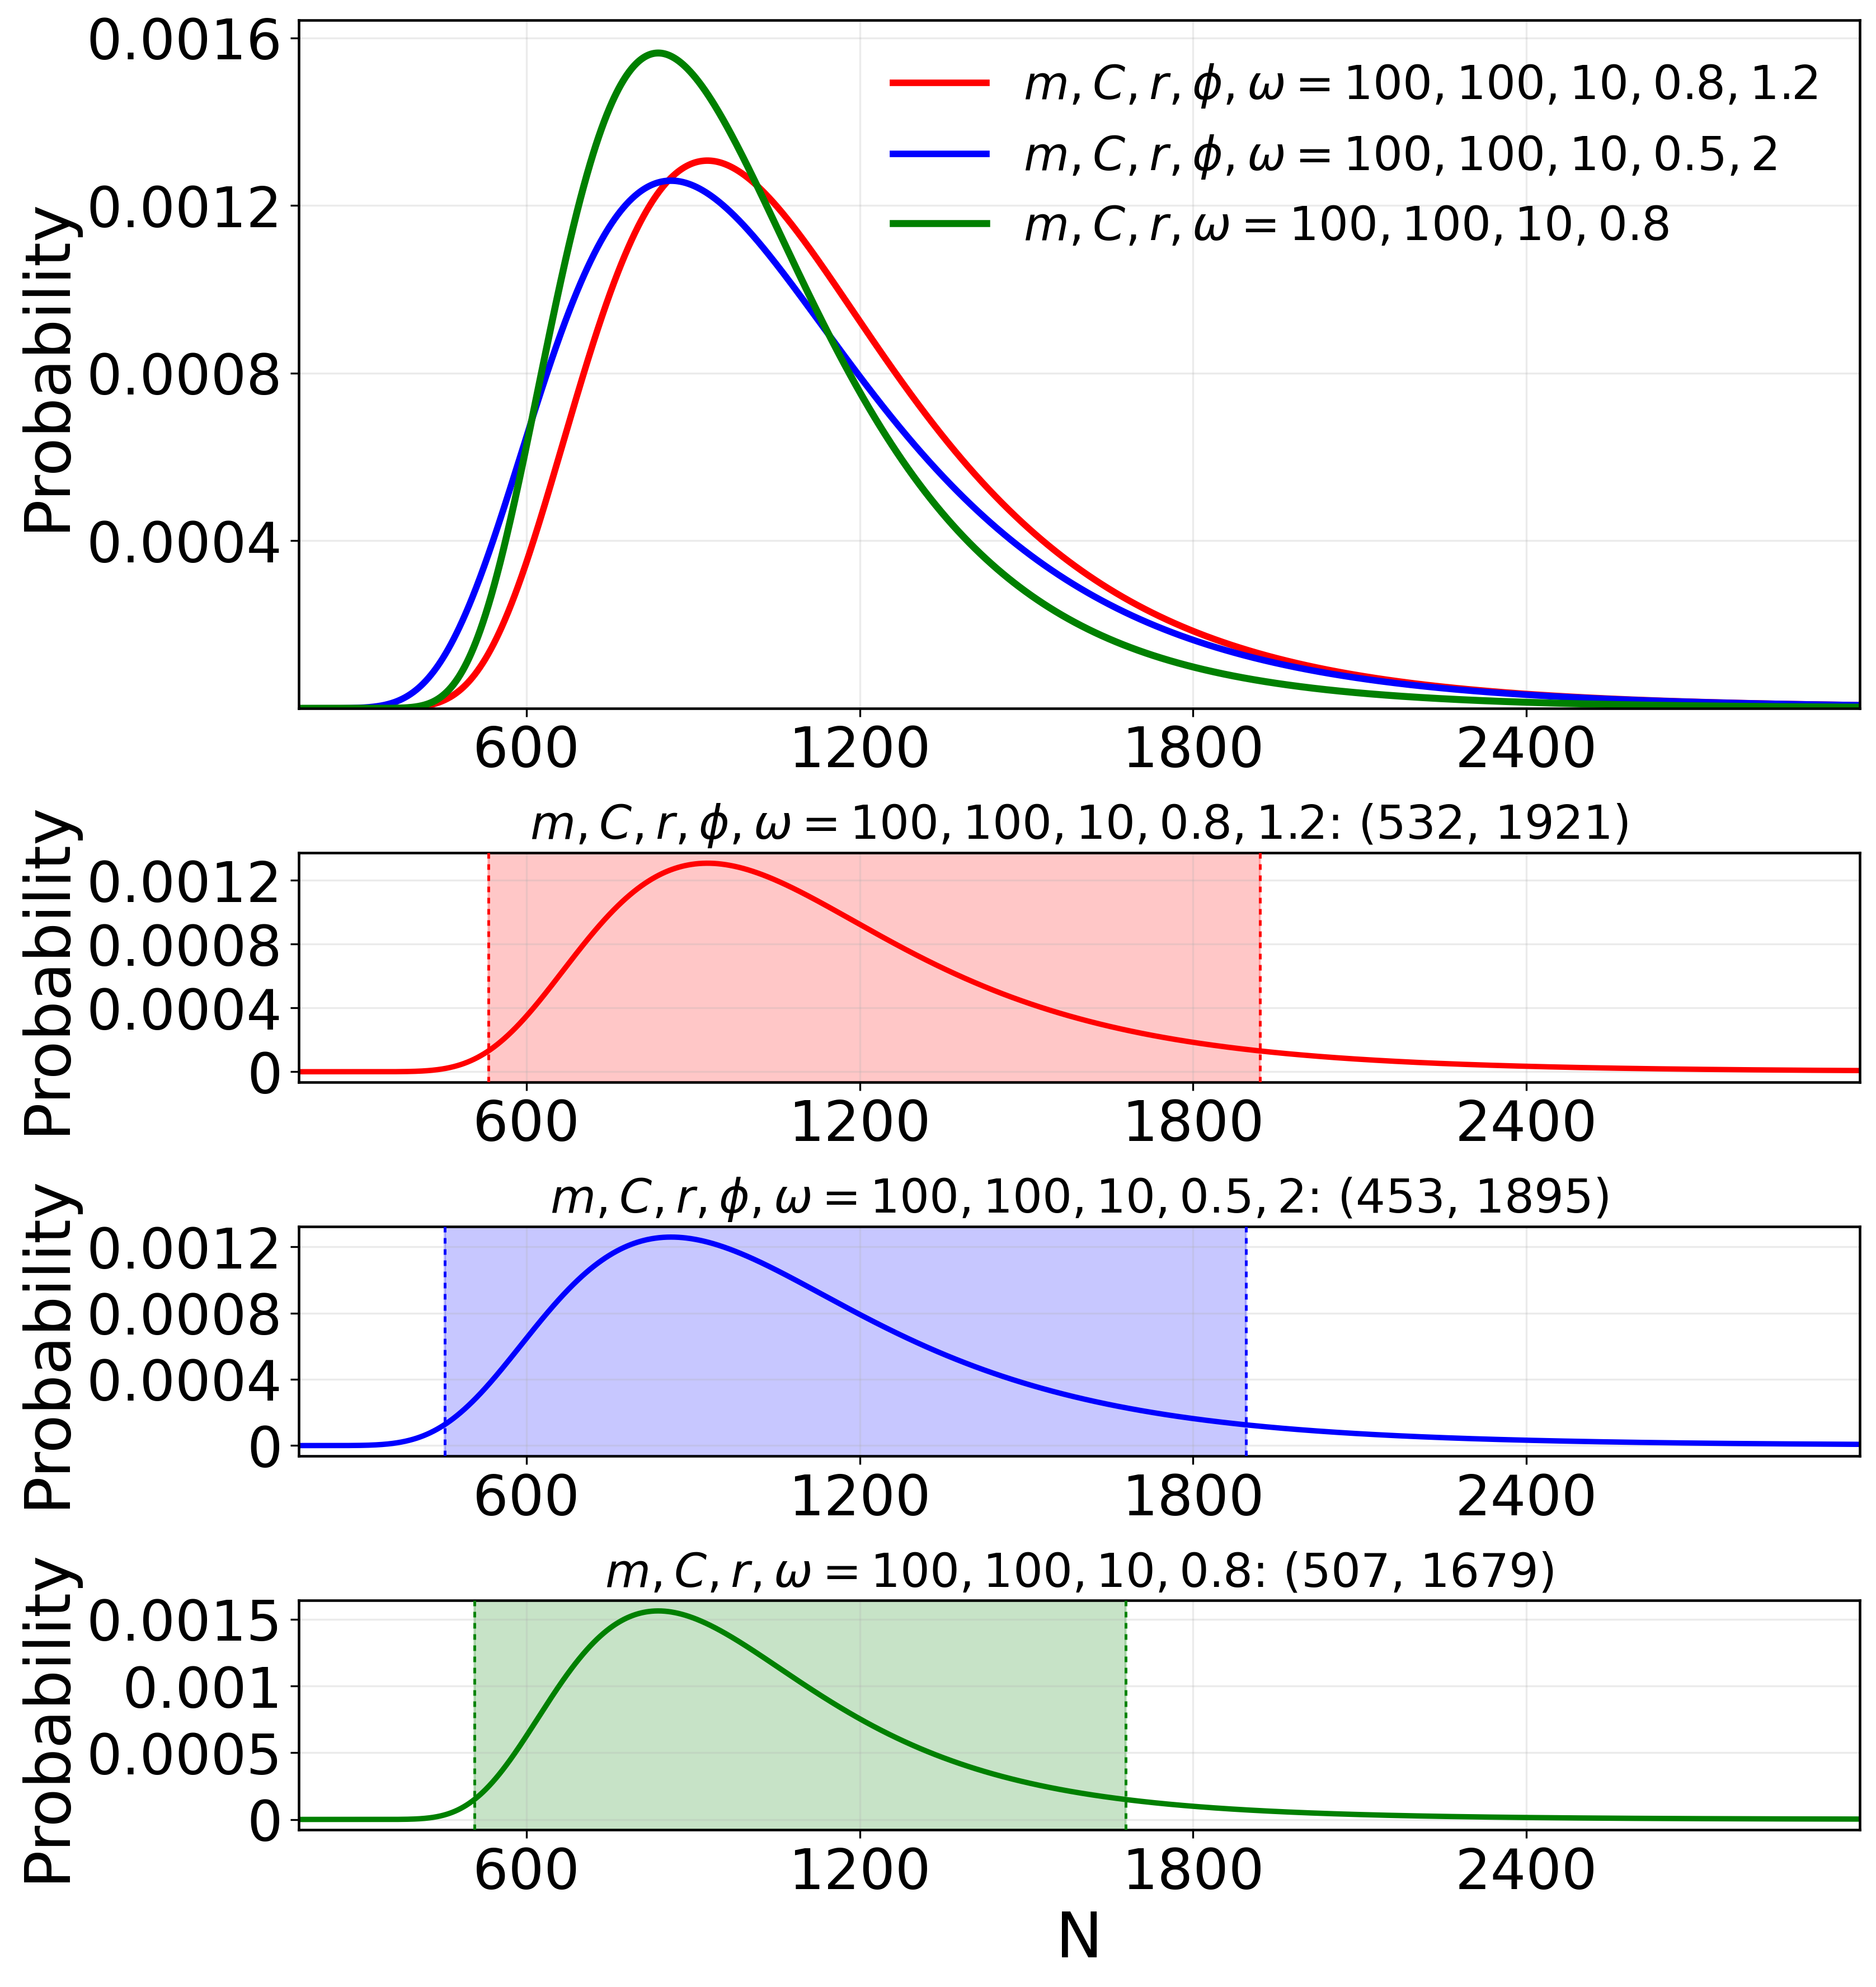

In [ ]:
# Figurr 4-B - Impact of different values of phi and omega


import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator, FuncFormatter

from ehpmarkrecap import ehp


def _add_ci_band(ax, lo, hi, color, alpha=0.22):
    """Vertical CI band + dashed boundary lines."""
    ax.axvspan(lo, hi, color=color, alpha=alpha, zorder=0.4)
    border_kw = dict(
        color=color,
        linestyle=(0, (2, 2)),  # short dashes
        linewidth=1.2,
        alpha=0.95,
        zorder=3,
    )
    ax.axvline(lo, **border_kw)
    ax.axvline(hi, **border_kw)


def plot_figure_3B(
    K=3000,
    alpha_ci=0.05,        # 95% CI
    figsize=(12, 14),
    dpi=300,
    max_xticks=5,
    max_yticks_main=5,
    max_yticks_small=4,
    outpath=None,  
    show=True,
):
    # Datasets
    d1 = (100, 100, 10)

    # ehp results
    res1 = ehp(d1, K=K, alpha=alpha_ci, phi=0.8, omega=1.2)
    res2 = ehp(d1, K=K, alpha=alpha_ci, phi=0.5, omega=2)
    res3 = ehp(d1, K=K, alpha=alpha_ci, phi=False, omega=0.8)  # combined posterior (two datasets)

    x1, p1 = np.asarray(res1["domain"]), np.asarray(res1["pmf"])
    x2, p2 = np.asarray(res2["domain"]), np.asarray(res2["pmf"])
    x3, p3 = np.asarray(res3["domain"]), np.asarray(res3["pmf"])

    ci1 = (int(res1["ci_low"]), int(res1["ci_high"]))
    ci2 = (int(res2["ci_low"]), int(res2["ci_high"]))
    ci3 = (int(res3["ci_low"]), int(res3["ci_high"]))

    color_first = "red"
    color_second = "blue"
    color_combined = "green"

    # Stylw
    rc = {
        "font.size": 26,
        "axes.titlesize": 20,
        "axes.labelsize": 27,
        "xtick.labelsize": 24,
        "ytick.labelsize": 24,
        "legend.fontsize": 20,
        "axes.linewidth": 1.1,
        "figure.dpi": dpi,
        "savefig.dpi": dpi,
    }

    with mpl.rc_context(rc):
        fig = plt.figure(figsize=figsize, constrained_layout=False)
        gs = gridspec.GridSpec(4, 1, height_ratios=[3, 1, 1, 1], hspace=0.42)

        # Main Plot 
        ax_main = plt.subplot(gs[0])
        ax_main.plot(x1, p1, lw=2.8, color=color_first, label=r"$m,C,r,\phi,\omega=100,100,10,0.8,1.2$")
        ax_main.plot(x2, p2, lw=2.8, color=color_second, label=r"$m,C,r,\phi,\omega=100,100,10,0.5,2$")
        ax_main.plot(x3, p3, lw=3.0, color=color_combined, label="$m,C,r,\omega=100,100,10,0.8$")

        ax_main.set_ylabel("Probability")
        ax_main.grid(True, alpha=0.25)
        ax_main.set_ylim(bottom=0)

        xmin = min(int(x1[0]), int(x2[0]), int(x3[0]))
        ax_main.set_xlim(xmin, int(K))

        ax_main.xaxis.set_major_locator(MaxNLocator(nbins=max_xticks, integer=True, prune="both"))
        ax_main.yaxis.set_major_locator(MaxNLocator(nbins=max_yticks_main, prune="both"))
        ax_main.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))

        ax_main.legend(frameon=False, loc="upper right")

        # Subplot 1
        ax1 = plt.subplot(gs[1], sharex=ax_main)
        ax1.plot(x1, p1, lw=2.3, color=color_first)
        _add_ci_band(ax1, ci1[0], ci1[1], color=color_first, alpha=0.22)
        ax1.set_ylabel("Probability")
        ax1.set_title(f"$m,C,r,\phi,\omega=100,100,10,0.8,1.2$: {ci1}")
        ax1.grid(True, alpha=0.25)

        ax1.yaxis.set_major_locator(MaxNLocator(nbins=max_yticks_small, prune="both"))
        ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))

        # Subplot 2
        ax2 = plt.subplot(gs[2], sharex=ax_main)
        ax2.plot(x2, p2, lw=2.3, color=color_second)
        _add_ci_band(ax2, ci2[0], ci2[1], color=color_second, alpha=0.22)
        ax2.set_ylabel("Probability")
        ax2.set_title(f"$m,C,r,\phi,\omega=100,100,10,0.5,2$: {ci2}")
        ax2.grid(True, alpha=0.25)

        ax2.yaxis.set_major_locator(MaxNLocator(nbins=max_yticks_small, prune="both"))
        ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))

        # Subplot 3
        ax3 = plt.subplot(gs[3], sharex=ax_main)
        ax3.plot(x3, p3, lw=2.3, color=color_combined)
        _add_ci_band(ax3, ci3[0], ci3[1], color=color_combined, alpha=0.22)
        ax3.set_ylabel("Probability")
        ax3.set_xlabel("N")
        ax3.set_title(f"$m,C,r,\omega=100,100,10,0.8$: {ci3}")
        ax3.grid(True, alpha=0.25)

        ax3.yaxis.set_major_locator(MaxNLocator(nbins=max_yticks_small, prune="both"))
        ax3.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))
        ax3.xaxis.set_major_locator(MaxNLocator(nbins=max_xticks, integer=True, prune="both"))

        fig.tight_layout()

        if outpath:
            fig.savefig(outpath, bbox_inches="tight")

        if show:
            plt.show()

        return fig, (ax_main, ax1, ax2, ax3)


if __name__ == "__main__":
    plot_figure_3B(
        K=3000,
        alpha_ci=0.05,      # 95% CI
        figsize=(12, 14),
        dpi=300,
        max_xticks=5,       # fewer ticks
        max_yticks_main=5,
        max_yticks_small=4,
        outpath=None,
        show=True,
    )


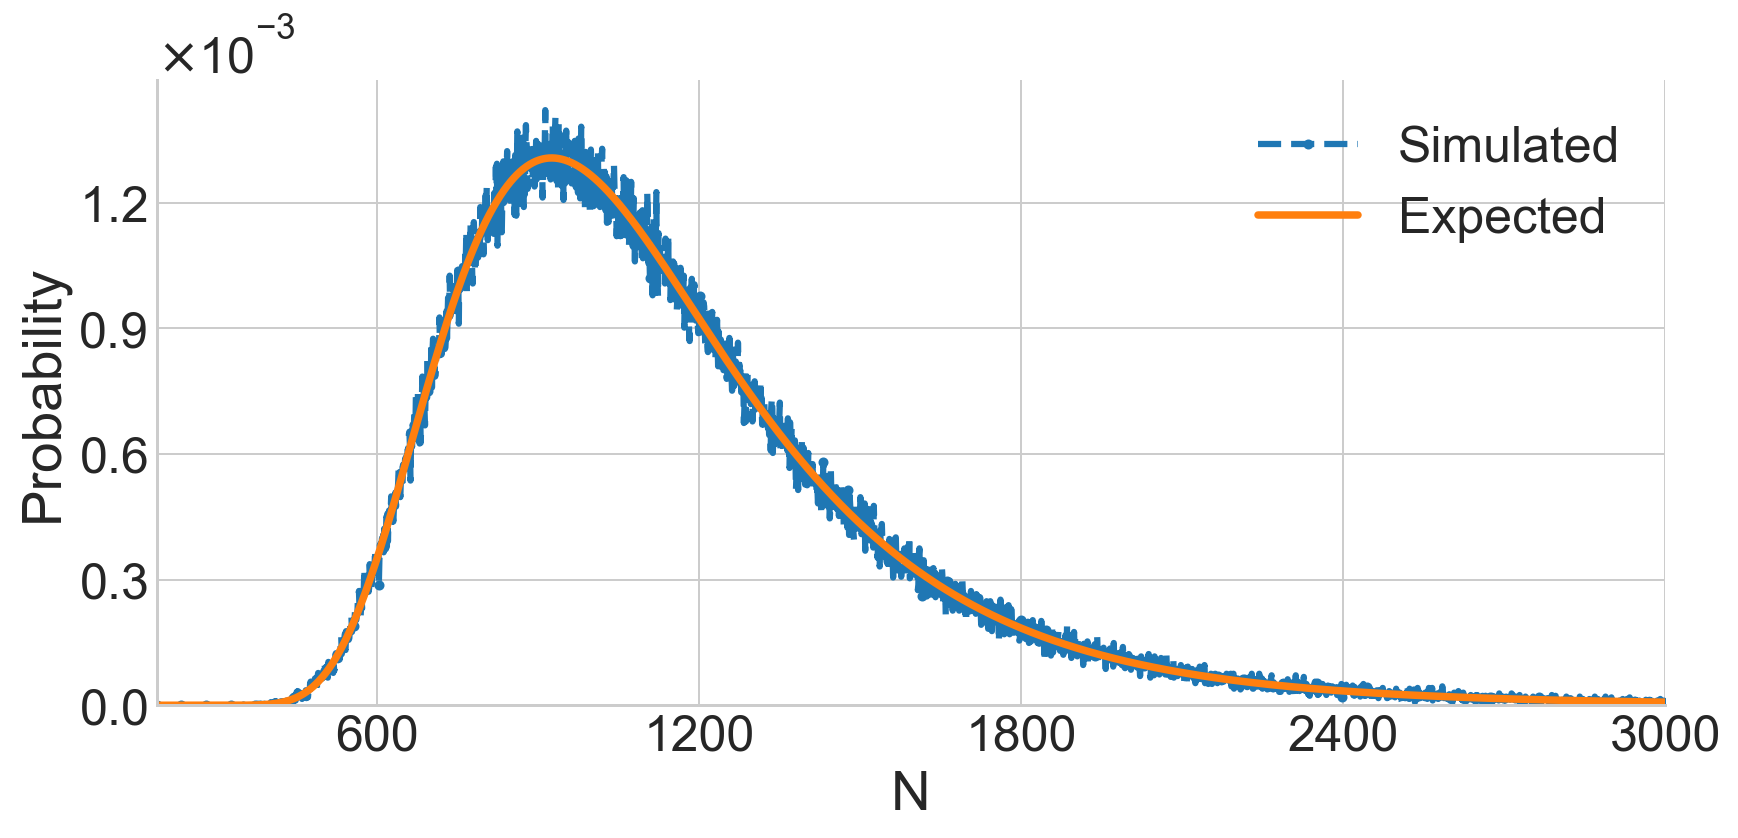

In [ ]:
# Figure 4-C - Simulation vs Expected
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, ScalarFormatter

from ehpmarkrecap import ehp
from Simulation import simulate_r_values, normalized_probabilities_for_r


def plot_single_sim_vs_expected(
    m: int,
    C: int,
    r: int,
    phi: float,
    omega: float,
    K: int,
    simulations: int = 50_000,
    seed: int = 42,
):
    # Style
    plt.style.use("seaborn-v0_8-whitegrid")
    plt.rcParams.update(
        {
            "font.size": 18,
            "axes.titlesize": 20,
            "axes.labelsize": 22,
            "legend.fontsize": 20,
            "xtick.labelsize": 20,
            "ytick.labelsize": 20,
            "axes.linewidth": 1.2,
        }
    )

    # Simulated
    N_min = m + C - r
    r_by_N = simulate_r_values(
        N_min=N_min,
        K=K,
        m=m,
        C=C,
        phi=phi,
        omega=omega,
        Simulations=simulations,
        Seed=seed,
    )
    Ns_sim, pmf_sim, _ = normalized_probabilities_for_r(r_by_N, r_target=r)

    # Expected
    res = ehp([(m, C, r)], K=K, phi=phi, omega=omega, mt_tail_cutoff=0)
    Ns_exp = res["domain"]
    pmf_exp = res["pmf"]

    # --- plot ---
    fig, ax = plt.subplots(figsize=(10, 5), dpi=180)

    # Put Expected on top of Simulated
    markevery = max(1, len(Ns_sim) // 60)
    ax.plot(
        Ns_sim,
        pmf_sim,
        linewidth=2.5,
        linestyle="--",
        marker="o",
        markersize=3,
        markevery=markevery,
        label="Simulated",
    )
    ax.plot(Ns_exp, pmf_exp, linewidth=3, label="Expected")

    ax.set_xlabel("N")
    ax.set_ylabel("Probability")

    # Max 5 ticks each axis
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))

    ax.set_xlim(Ns_exp[0], Ns_exp[-1])
    ax.set_ylim(bottom=0)

    ax.legend(frameon=False, loc="best")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()
    plt.show()


if __name__ == "__main__":
    plot_single_sim_vs_expected(
        m=100,
        C=100,
        r=10,
        phi=0.8,
        omega=1.2,
        K=3000,
        simulations=5_000,
        seed=42,
    )


<>:134: SyntaxWarning: invalid escape sequence '\p'
<>:155: SyntaxWarning: invalid escape sequence '\o'
<>:134: SyntaxWarning: invalid escape sequence '\p'
<>:155: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Danial\AppData\Local\Temp\ipykernel_14896\2197706255.py:134: SyntaxWarning: invalid escape sequence '\p'
  xlabel="$\phi$",
C:\Users\Danial\AppData\Local\Temp\ipykernel_14896\2197706255.py:155: SyntaxWarning: invalid escape sequence '\o'
  xlabel="$\omega$",


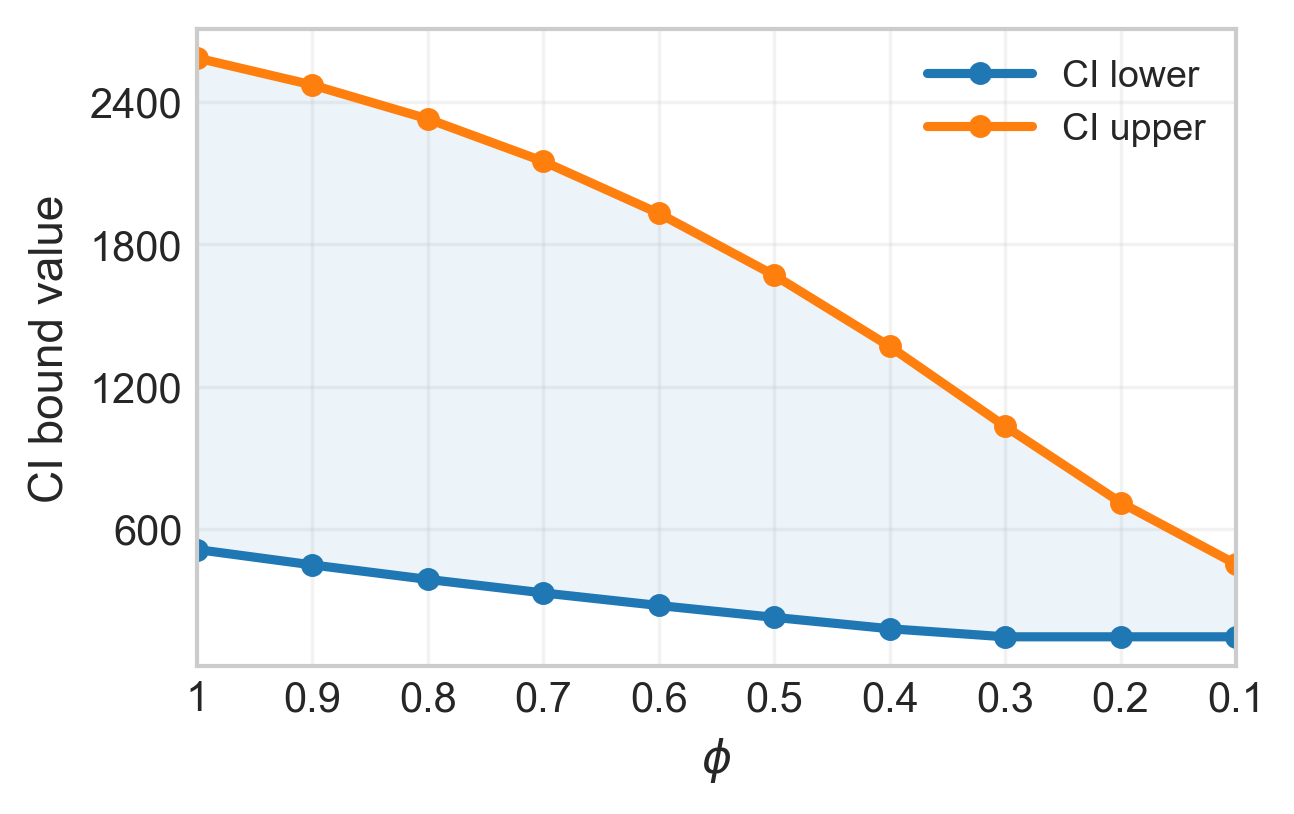

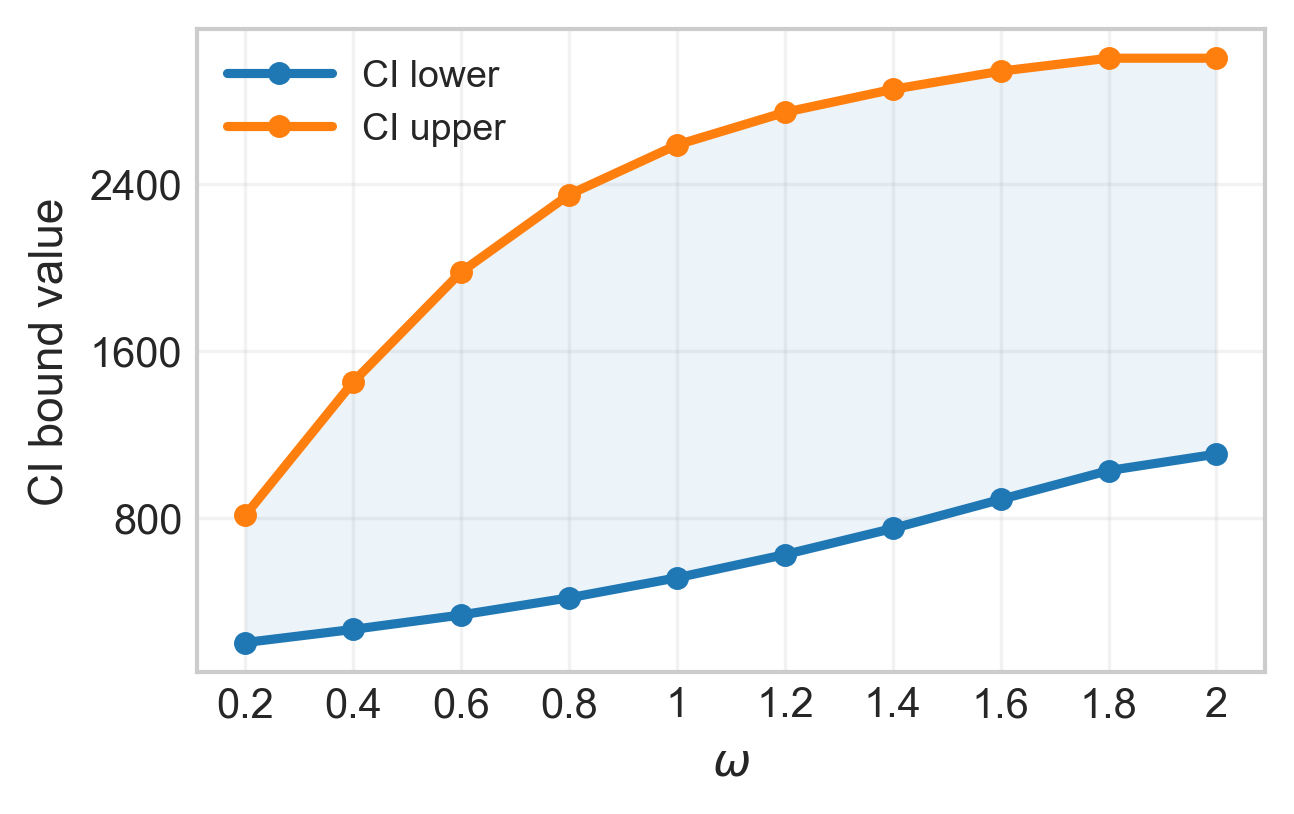

In [ ]:
# Figure 4-D,E - Sensitivity
"""
Two plots of CI bounds vs heterogeneity parameters (phi and omega)
Fixed (m, C, r) = (100, 50, 5), K = 3000
Plot A: CI lower/upper vs phi (omega fixed at 1)
Plot B: CI lower/upper vs omega (phi fixed at 1)

"""

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter

from ehpmarkrecap import ehp


def _compute_ci_bounds_over_param(
    data=(100, 50, 5),
    K=3000,
    param_name="phi",              # "phi" or "omega"
    param_values=(),
    ci_level=0.95,
    ci_method="mode_expand",
    mt_tail_cutoff=1e-12,          # set 0 for max accuracy (slower) when phi<1
):
    alpha = 1.0 - float(ci_level)

    x = np.asarray(list(param_values), dtype=float)
    lo = np.empty_like(x, dtype=float)
    hi = np.empty_like(x, dtype=float)

    for i, v in enumerate(x):
        if param_name == "phi":
            res = ehp(
                data, K=K, phi=float(v), omega=1.0,
                alpha=alpha, ci_method=ci_method, mt_tail_cutoff=mt_tail_cutoff
            )
        elif param_name == "omega":
            res = ehp(
                data, K=K, phi=1.0, omega=float(v),
                alpha=alpha, ci_method=ci_method, mt_tail_cutoff=mt_tail_cutoff
            )
        else:
            raise ValueError("param_name must be 'phi' or 'omega'.")

        lo[i] = float(res["ci_low"])
        hi[i] = float(res["ci_high"])

    return x, lo, hi


def _plot_ci_bounds(
    x, lo, hi,
    xlabel,
    ylabel="CI bound value",
    figsize=(4.2, 2.6),
    dpi=300,
    max_yticks=5,
    legend_loc="upper left",
    outpath=None,
    show=True,
    reverse_x=False,             
):
    rc = {
        "font.size": 11,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "axes.linewidth": 1.0,
        "figure.dpi": dpi,
        "savefig.dpi": dpi,
    }

    with mpl.rc_context(rc):
        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

        ax.plot(x, lo, linewidth=2.2, marker="o", markersize=4.5, label="CI lower")
        ax.plot(x, hi, linewidth=2.2, marker="o", markersize=4.5, label="CI upper")
        ax.fill_between(x, lo, hi, alpha=0.08)

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.25)

        # Ticks: show the provided discrete values on x, and keep y ticks compact
        ax.set_xticks(x)
        ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=max_yticks, prune="both"))
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:g}"))

        # reverse x-axis direction
        if reverse_x:
            ax.set_xlim(np.max(x), np.min(x))

        ax.legend(frameon=False, loc=legend_loc, ncol=1, handlelength=2.8, borderaxespad=0.4)

        if outpath:
            fig.savefig(outpath, bbox_inches="tight")

        if show:
            plt.show()

        return fig, ax


def make_phi_and_omega_ci_plots(
    data=(100, 50, 5),
    K=3000,
    ci_level=0.95,
    ci_method="mode_expand",
    mt_tail_cutoff=1e-12,
    figsize=(4.2, 2.6),
    dpi=300,
    outpath_phi=None,   
    outpath_omega=None,  
    show=True,
):
    phi_values = [1, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]
    omega_values = [0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8, 2,]

    # Plot 1: vary phi (omega fixed at 1) 
    x_phi, lo_phi, hi_phi = _compute_ci_bounds_over_param(
        data=data, K=K,
        param_name="phi",
        param_values=phi_values,
        ci_level=ci_level,
        ci_method=ci_method,
        mt_tail_cutoff=mt_tail_cutoff,
    )
    fig1, ax1 = _plot_ci_bounds(
        x_phi, lo_phi, hi_phi,
        xlabel="$\phi$",
        ylabel="CI bound value",
        figsize=figsize,
        dpi=dpi,
        legend_loc="upper right",
        outpath=outpath_phi,
        show=show,
        reverse_x=True, 
    )

    # Plot 2: vary omega (phi fixed at 1) 
    x_om, lo_om, hi_om = _compute_ci_bounds_over_param(
        data=data, K=K,
        param_name="omega",
        param_values=omega_values,
        ci_level=ci_level,
        ci_method=ci_method,
        mt_tail_cutoff=mt_tail_cutoff,
    )
    fig2, ax2 = _plot_ci_bounds(
        x_om, lo_om, hi_om,
        xlabel="$\omega$",
        ylabel="CI bound value",
        figsize=figsize,
        dpi=dpi,
        legend_loc="upper left",
        outpath=outpath_omega,
        show=show,
        reverse_x=False,
    )

    return (fig1, ax1), (fig2, ax2)


if __name__ == "__main__":
    make_phi_and_omega_ci_plots(
        data=(100, 50, 5),
        K=3000,
        ci_level=0.95,
        ci_method="mode_expand",   # or "hpd"
        mt_tail_cutoff=1e-12,      
        figsize=(4.2, 2.6),
        dpi=300,
        outpath_phi=None,
        outpath_omega=None,
        show=True
    )


<>:82: SyntaxWarning: invalid escape sequence '\o'
<>:83: SyntaxWarning: invalid escape sequence '\p'
<>:82: SyntaxWarning: invalid escape sequence '\o'
<>:83: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Danial\AppData\Local\Temp\ipykernel_14896\1927935020.py:82: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel("$\omega$")
C:\Users\Danial\AppData\Local\Temp\ipykernel_14896\1927935020.py:83: SyntaxWarning: invalid escape sequence '\p'
  ax.set_ylabel("$\phi$")


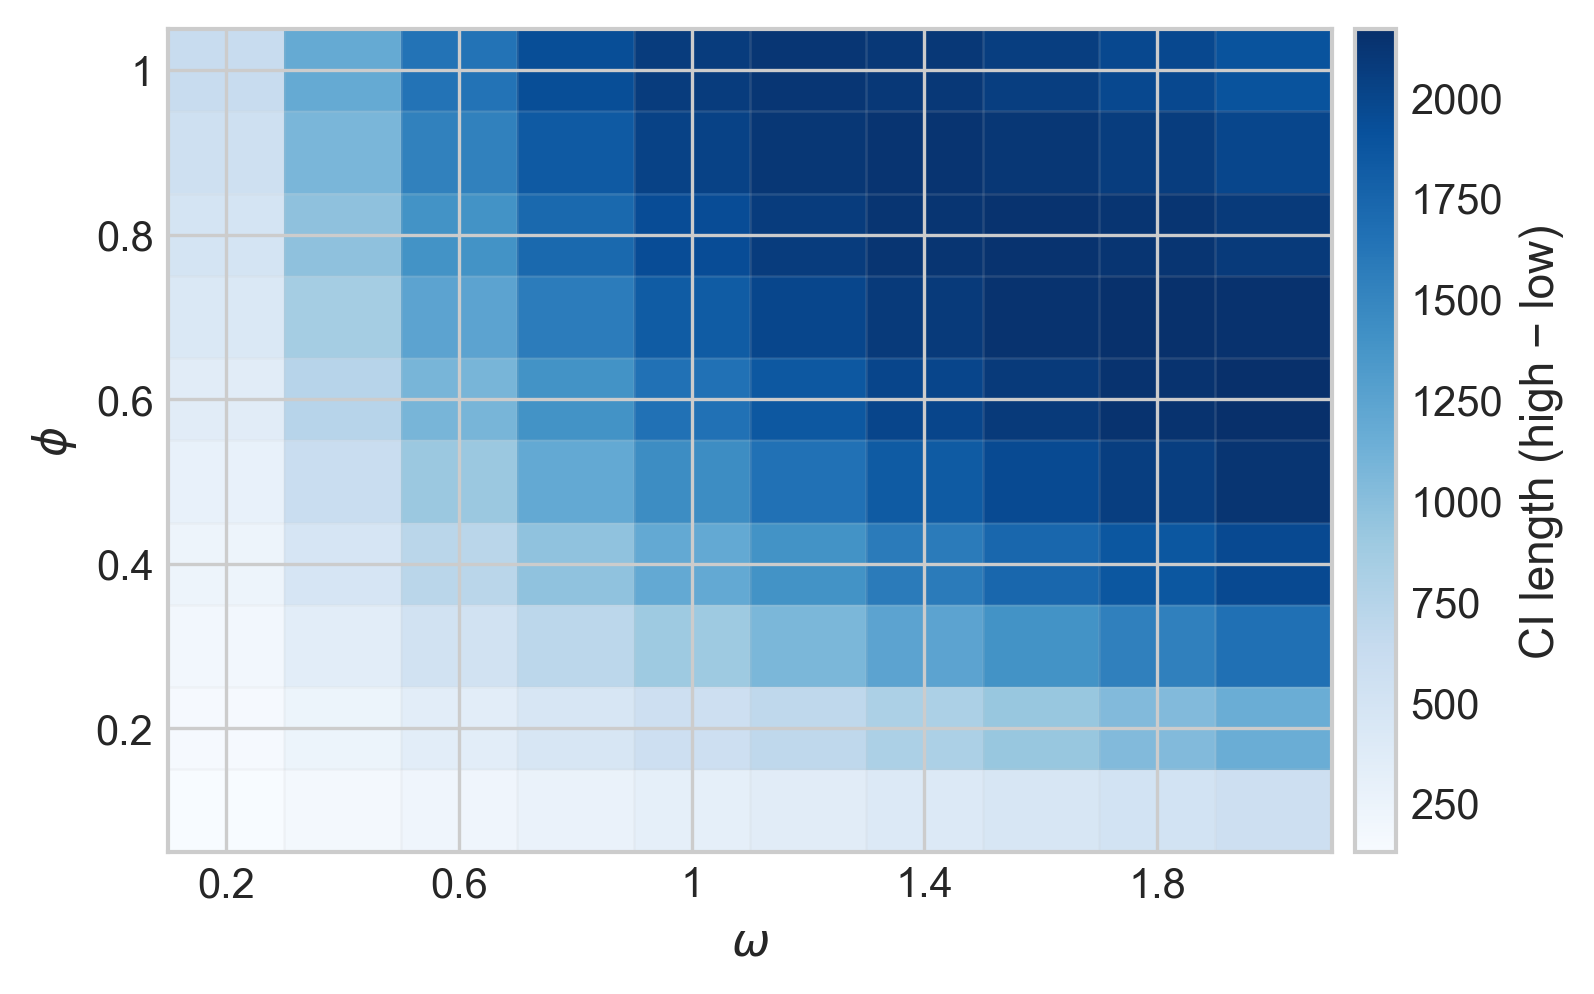

In [ ]:
# Figure 4-F - Impact of phi and omega on CI

"""
Phi–Omega grid with CI length shown as color (blue shades).
Interpretation of "3D plot where 3rd dimension is color":
- x-axis: omega
- y-axis: phi
- color: CI length = ci_high - ci_low
Uses ehp for each (phi, omega) combination.
"""

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from ehpmarkrecap import ehp


def plot_ci_length_phi_omega_colormap(
    data=(100, 50, 5),
    K=3000,
    ci_level=0.95,
    ci_method="mode_expand",
    mt_tail_cutoff=1e-12,  # set 0 for max accuracy (slower)
    phi_values=(1, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1),
    omega_values=(0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8, 2),
    figsize=(5.2, 3.2),
    dpi=300,
    max_xtick_labels=6,   # reduce labels for small panels
    max_ytick_labels=6,
    outpath=None,     
    show=True
):
    alpha = 1.0 - float(ci_level)

    phi_vals = np.asarray(phi_values, dtype=float)
    omega_vals = np.asarray(omega_values, dtype=float)

    Z = np.empty((len(phi_vals), len(omega_vals)), dtype=float)  # CI length

    # Compute CI length for every combination
    for i, phi in enumerate(phi_vals):
        for j, omega in enumerate(omega_vals):
            res = ehp(
                data,
                K=K,
                phi=float(phi),
                omega=float(omega),
                alpha=alpha,
                ci_method=ci_method,
                mt_tail_cutoff=mt_tail_cutoff,
            )
            Z[i, j] = float(res["ci_high"]) - float(res["ci_low"])

    # Style
    rc = {
        "font.size": 11,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.linewidth": 1.0,
        "figure.dpi": dpi,
        "savefig.dpi": dpi,
    }

    with mpl.rc_context(rc):
        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

        # Colormap (blue shades)
        im = ax.imshow(
            Z,
            cmap="Blues",
            origin="upper",     # puts phi=1 at the top row (matches list order)
            aspect="auto",
            interpolation="nearest",
        )

        # Labels
        ax.set_xlabel("$\omega$")
        ax.set_ylabel("$\phi$")

        # Tick placement: use index positions, label with actual values
        ax.set_xticks(np.arange(len(omega_vals)))
        ax.set_yticks(np.arange(len(phi_vals)))

        # Reduce tick label clutter by showing every k-th label
        def _sparse_labels(values, max_labels):
            n = len(values)
            if n <= max_labels:
                return np.arange(n), [f"{v:g}" for v in values]
            step = int(np.ceil(n / max_labels))
            idx = np.arange(0, n, step)
            return idx, [f"{values[k]:g}" for k in idx]

        xt_idx, xt_lab = _sparse_labels(omega_vals, max_xtick_labels)
        yt_idx, yt_lab = _sparse_labels(phi_vals, max_ytick_labels)

        ax.set_xticks(xt_idx)
        ax.set_xticklabels(xt_lab)
        ax.set_yticks(yt_idx)
        ax.set_yticklabels(yt_lab)

        ax.set_xticks(np.arange(-0.5, len(omega_vals), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, len(phi_vals), 1), minor=True)
        ax.grid(which="minor", linestyle="-", linewidth=0.6, alpha=0.15)
        ax.tick_params(which="minor", bottom=False, left=False)

        # Colorbar
        cbar = fig.colorbar(im, ax=ax, pad=0.02)
        cbar.set_label("CI length (high − low)")
        cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))

        if outpath:
            fig.savefig(outpath, bbox_inches="tight")

        if show:
            plt.show()

    return fig, ax, Z


if __name__ == "__main__":
    phi_values = [1, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]
    omega_values = [0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.4, 1.6, 1.8, 2]

    plot_ci_length_phi_omega_colormap(
        data=(100, 50, 5),
        K=3000,
        ci_level=0.95,
        ci_method="mode_expand",  # or "hpd"
        mt_tail_cutoff=1e-12,     # set 0 for max accuracy (slower)
        phi_values=phi_values,
        omega_values=omega_values,
        figsize=(5.2, 3.2),
        dpi=300,
        max_xtick_labels=6,
        max_ytick_labels=6,
        outpath=None,
        show=True,
    )


In [30]:
# Table 4

from ehpmarkrecap import ehp

def change(data, K, f, o):
    res1=ehp(data,K)
    res2=ehp(data, K=K, phi=f, omega=o, alpha=0.05)
    L1 = res1["ci_high"] - res1["ci_low"]
    L2 = res2["ci_high"] - res2["ci_low"]
    RL1 = L1 / res1["mode"]
    RL2 = L2 / res2["mode"]
    R = RL2/RL1
    C = (R-1) * 100
    return C

# For mode switch to mC/r if needed
# Columns
print("Relative CI width = CI width / mode. K=5000")
print("m,C,r","|","phi", "|", "omega","|","Mode","|","Mean","|","Median","|","CI","|","Change in normalized CI width vs. phi,omega=1 (%)")
print("-"*100)

m, C, r, K, f, o = 200, 100, 20, 5000, 1, 1
data=(m,C,r)
res = ehp(data, K=K, phi=f, omega=o, alpha=0.05)
print(data, "|", f, "|", o, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", "--")

m, C, r, K, f, o = 200, 100, 20, 5000, 0.8, 1
data=(m,C,r)
res = ehp(data, K=K, phi=f, omega=o, alpha=0.05)
print(data, "|", f, "|", o, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data,K,f,o))

m, C, r, K, f, o = 200, 100, 20, 5000, 0.5, 1
data=(m,C,r)
res = ehp(data, K=K, phi=f, omega=o, alpha=0.05)
print(data, "|", f, "|", o, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data,K,f,o))

m, C, r, K, f, o = 200, 100, 20, 5000, 1, 0.8
data=(m,C,r)
res = ehp(data, K=K, phi=f, omega=o, alpha=0.05)
print(data, "|", f, "|", o, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data,K,f,o))

m, C, r, K, f, o = 200, 100, 20, 5000, 1, 1.5
data=(m,C,r)
res = ehp(data, K=K, phi=f, omega=o, alpha=0.05)
print(data, "|", f, "|", o, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data,K,f,o))

m, C, r, K, f, o = 200, 100, 20, 5000, 1, 2
data=(m,C,r)
res = ehp(data, K=K, phi=f, omega=o, alpha=0.05)
print(data, "|", f, "|", o, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data,K,f,o))


###########################

m, C, r, K, f, o = 200, 100, 20, 5000, 0.8, 0.8
data=(m,C,r)
res = ehp(data, K=K, phi=f, omega=o, alpha=0.05)
print(data, "|", f, "|", o, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data,K,f,o))

m, C, r, K, f, o = 200, 100, 20, 5000, 0.8, 1.25
data=(m,C,r)
res = ehp(data, K=K, phi=f, omega=o, alpha=0.05)
print(data, "|", f, "|", o, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data,K,f,o))

m, C, r, K, f, o = 200, 100, 20, 5000, 0.5, 2
data=(m,C,r)
res = ehp(data, K=K, phi=f, omega=o, alpha=0.05)
print(data, "|", f, "|", o, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data,K,f,o))

m, C, r, K, f, o = 200, 100, 20, 5000, 0.2, 3
data=(m,C,r)
res = ehp(data, K=K, phi=f, omega=o, alpha=0.05)
print(data, "|", f, "|", o, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data,K,f,o))

m, C, r, K, f, o = 200, 100, 20, 5000, 0.7, 5
data=(m,C,r)
res = ehp(data, K=K, phi=f, omega=o, alpha=0.05)
print(data, "|", f, "|", o, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data,K,f,o))

m, C, r, K, f, o = 200, 100, 20, 5000, 0.3, 0.1
data=(m,C,r)
res = ehp(data, K=K, phi=f, omega=o, alpha=0.05)
print(data, "|", f, "|", o, "|", res["mode"], "|", res["mean"], "|", res["median"], "|", (res["ci_low"], res["ci_high"]), "|", change(data,K,f,o))


Relative CI width = CI width / mode. K=5000
m,C,r | phi | omega | Mode | Mean | Median | CI | Change in normalized CI width vs. phi,omega=1 (%)
----------------------------------------------------------------------------------------------------
(200, 100, 20) | 1 | 1 | 999 | 1094.4999707723282 | 1061 | (704, 1552) | --
(200, 100, 20) | 0.8 | 1 | 800 | 875.5999992181851 | 848 | (563, 1243) | 0.13561320754718054
(200, 100, 20) | 0.5 | 1 | 500 | 547.2674057177887 | 530 | (350, 779) | 1.0780660377358586
(200, 100, 20) | 1 | 0.8 | 855 | 931.2957146496644 | 904 | (619, 1298) | -6.443644488579936
(200, 100, 20) | 1 | 1.5 | 1360 | 1502.510367253634 | 1452 | (919, 2187) | 9.837333518312995
(200, 100, 20) | 1 | 2 | 1720 | 1910.2099733695088 | 1842 | (1134, 2822) | 15.614853005704266
(200, 100, 20) | 0.8 | 0.8 | 688 | 748.2188796445604 | 727 | (497, 1043) | -6.508131307591047
(200, 100, 20) | 0.8 | 1.25 | 940 | 1034.8301061424793 | 1001 | (645, 1493) | 6.276595744680846
(200, 100, 20) | 0.5 | 2 |

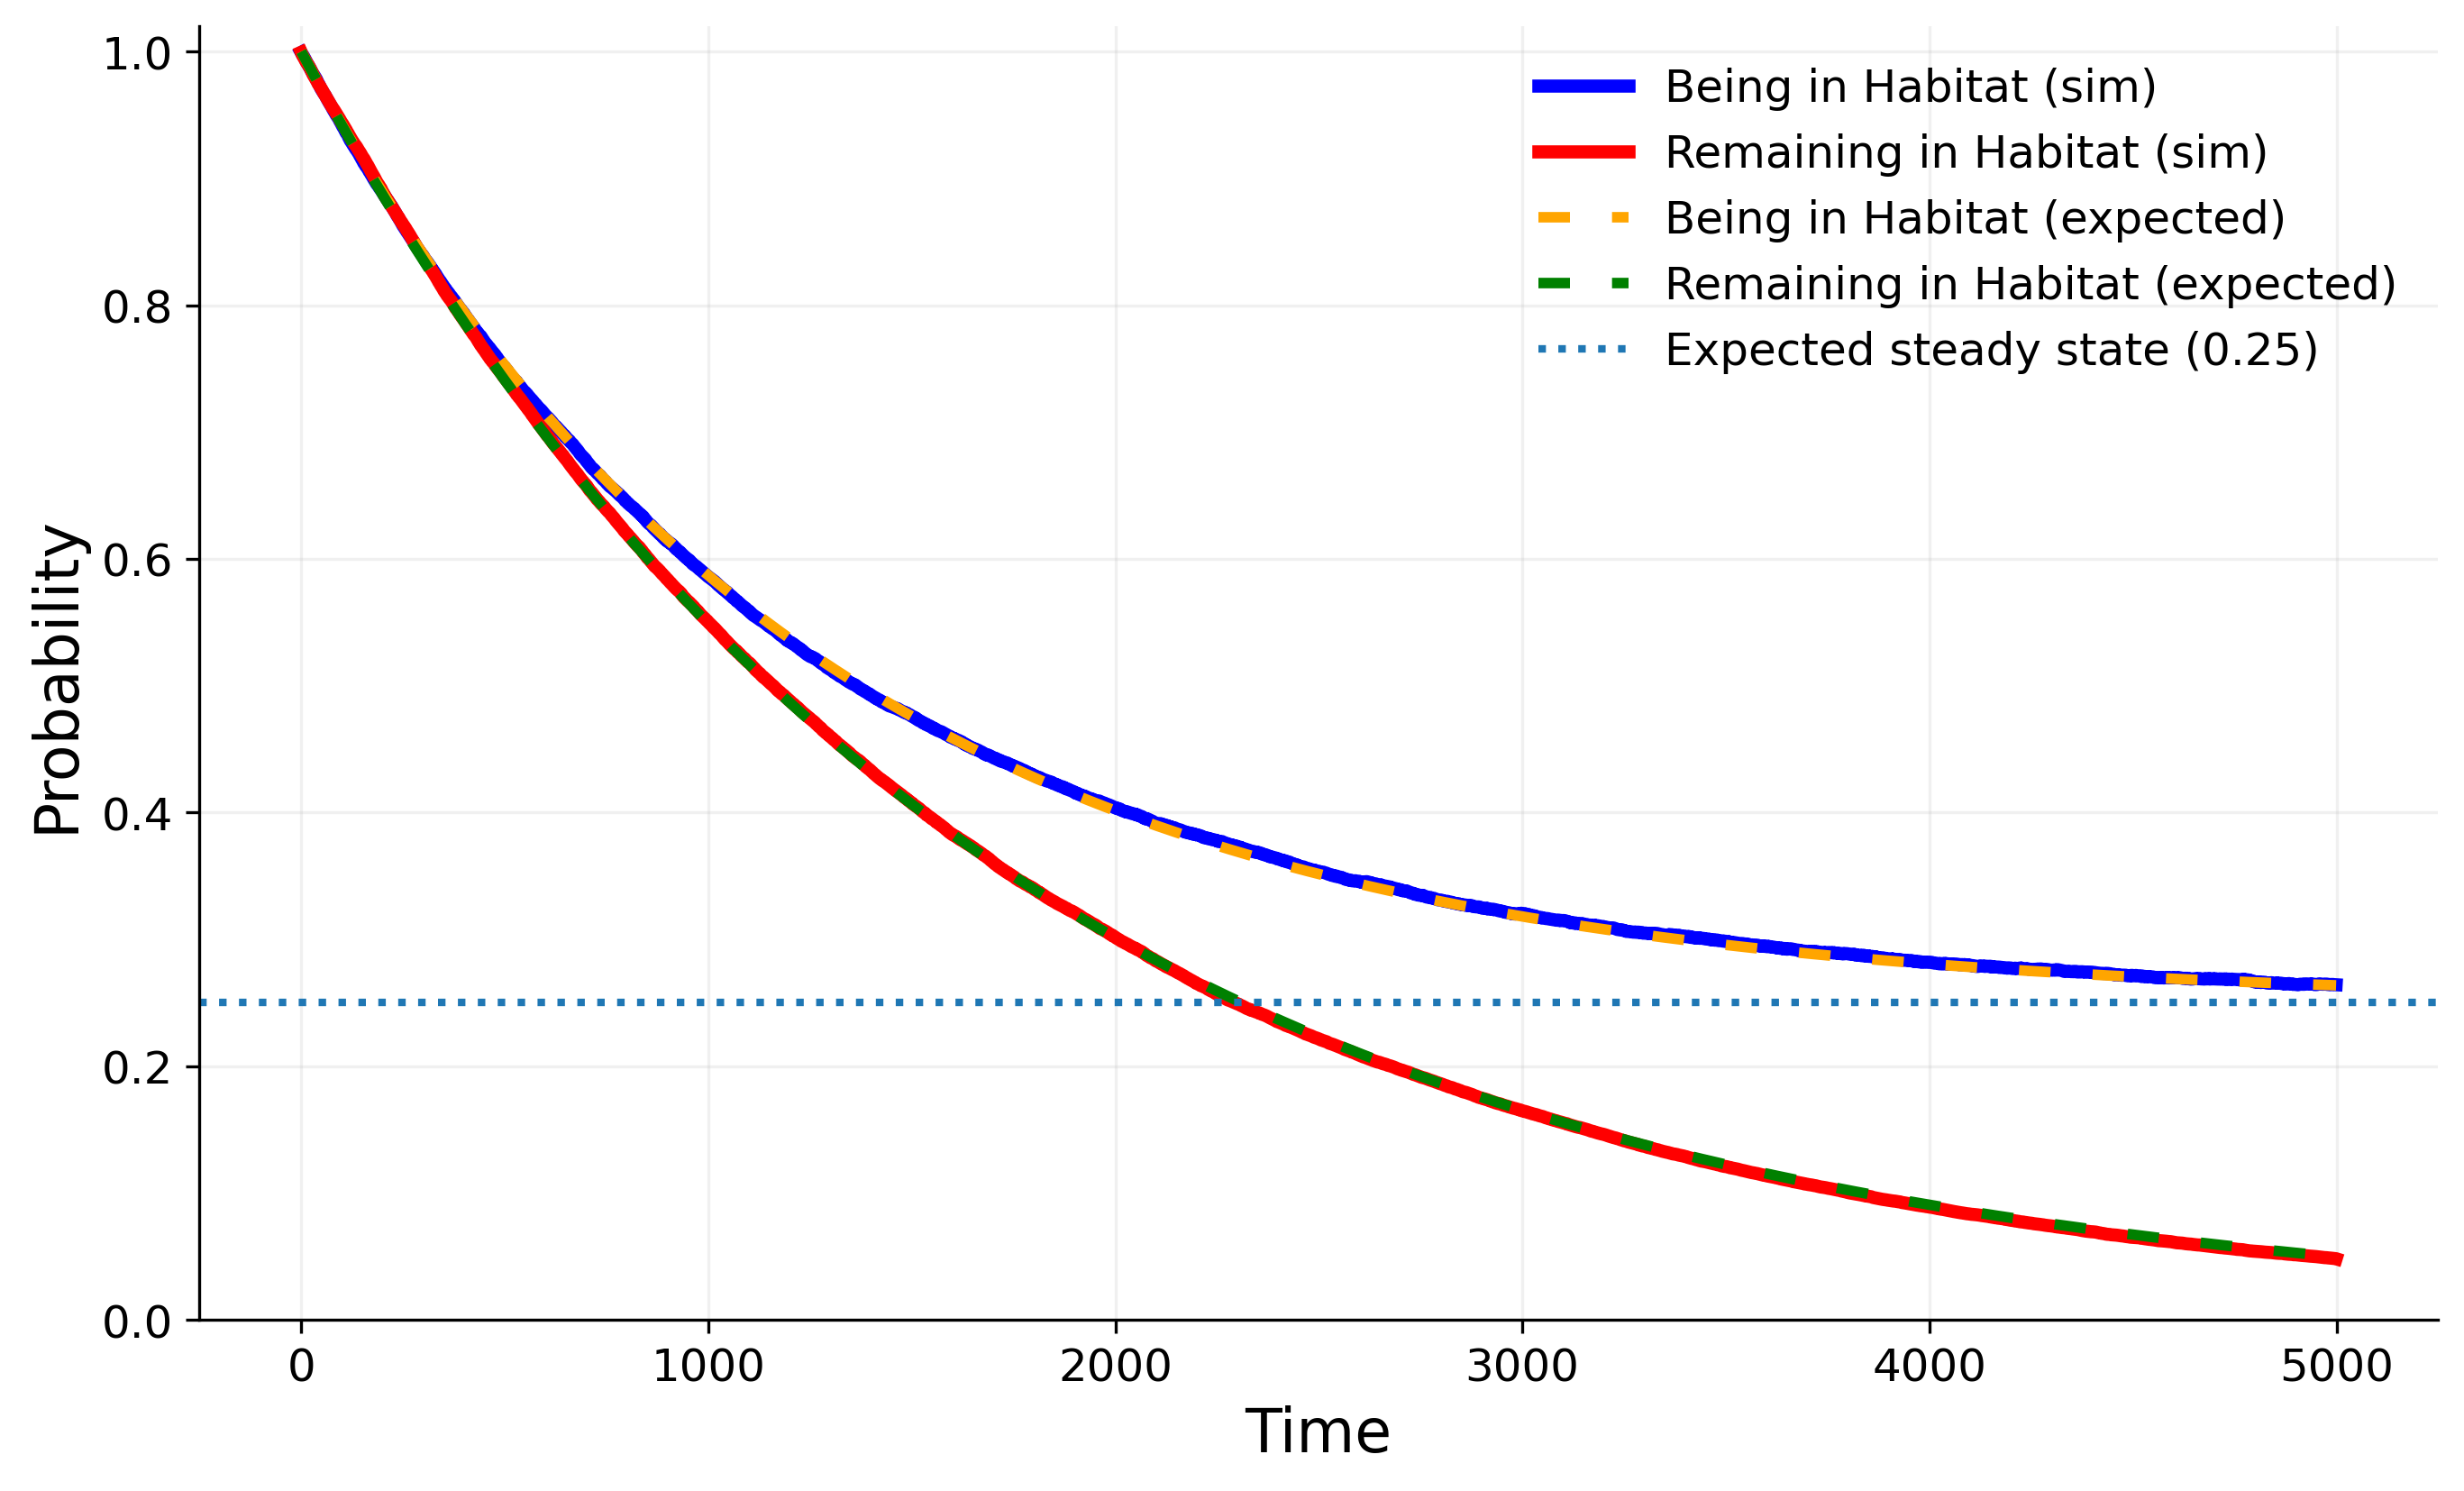

In [16]:
# Figure 5-A — Two-state Markov occupancy model + analytic expectations

from __future__ import annotations

from dataclasses import dataclass
from typing import List, Tuple

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def _validate_positive(name: str, value: float) -> None:
    if value <= 0:
        raise ValueError(f"{name} must be > 0. Got {value}.")


@dataclass(frozen=True)
class Geometry2D:
    """
    Concentric disks:
      - Inner disk (habitat) radius R_inner, area A1 = pi R_inner^2
      - Outer disk radius R_outer, total area At = pi R_outer^2
      - Accessible outside area A2 = At - A1
      - Interface length (habitat boundary) b = 2 pi R_inner
    """
    R_outer: float
    R_inner: float

    @property
    def A1(self) -> float:
        return np.pi * self.R_inner**2

    @property
    def At(self) -> float:
        return np.pi * self.R_outer**2

    @property
    def A2(self) -> float:
        return self.At - self.A1

    @property
    def b(self) -> float:
        return 2.0 * np.pi * self.R_inner

    @property
    def steady_state(self) -> float:
        return self.A1 / self.At


@dataclass
class TwoStateMarkovSim:
    """
    Discrete-time simulation of a continuous-time 2-state Markov process.

    Transitions per timestep dt:
      in  -> out with probability p_out = 1 - exp(-k_out dt)
      out -> in  with probability p_in  = 1 - exp(-k_in  dt)
    """
    k_out: float
    k_in: float
    dt: float
    n_particles: int
    n_steps: int
    seed: int = 0

    def __post_init__(self) -> None:
        _validate_positive("k_out", self.k_out)
        _validate_positive("k_in", self.k_in)
        _validate_positive("dt", self.dt)
        if self.n_particles <= 0 or self.n_steps <= 0:
            raise ValueError("n_particles and n_steps must be positive integers.")

        self.rng = np.random.default_rng(self.seed)

        # State: True=in habitat, False=outside
        self.in_habitat = np.ones(self.n_particles, dtype=bool)

        # For "remaining" (never exited): track absorption once they leave
        self.has_exited = np.zeros(self.n_particles, dtype=bool)

        # Transition probabilities for each dt (exact from CTMC)
        self.p_out = 1.0 - np.exp(-self.k_out * self.dt)
        self.p_in = 1.0 - np.exp(-self.k_in * self.dt)

    def run_being_in_habitat(self) -> List[float]:
        """Re-entry allowed: fraction currently in habitat over time."""
        frac_in: List[float] = []

        in_state = self.in_habitat.copy()
        for _ in range(self.n_steps):
            # leave events
            leave = in_state & (self.rng.random(self.n_particles) < self.p_out)
            in_state[leave] = False

            # enter events
            enter = (~in_state) & (self.rng.random(self.n_particles) < self.p_in)
            in_state[enter] = True

            frac_in.append(float(in_state.mean()))

        return frac_in

    def run_remaining_in_habitat(self) -> List[float]:
        """
        No re-entry metric: fraction that have never exited habitat up to time t.
        Modeled as absorption on first exit with hazard k_out.
        """
        frac_never_exited: List[float] = []

        exited = self.has_exited.copy()  # absorbed flag
        for _ in range(self.n_steps):
            # Only those not yet exited are "at risk" of exiting this step
            at_risk = ~exited
            exit_now = at_risk & (self.rng.random(self.n_particles) < self.p_out)
            exited[exit_now] = True

            frac_never_exited.append(float((~exited).mean()))

        return frac_never_exited


def expected_curves(
    t: np.ndarray,
    A1: float,
    A2: float,
    k_out: float,
    k_in: float,
) -> Tuple[np.ndarray, np.ndarray, float]:
    """
    Analytic expectations:
      - Being in habitat with re-entry: C(t) = pi + (1-pi) exp(-(k_out+k_in)t),
        where pi = k_in/(k_out+k_in) = A1/(A1+A2) given the geometric rate choice.
      - Remaining (never exited): exp(-k_out t)
    """
    beta = k_out + k_in
    pi_in = k_in / beta  # should equal A1/(A1+A2) for k_out=b*s*fP/A1, k_in=b*s*fP/A2
    C_being = pi_in + (1.0 - pi_in) * np.exp(-beta * t)
    C_remaining = np.exp(-k_out * t)
    steady_state = A1 / (A1 + A2)
    return C_being, C_remaining, steady_state


def plot_fig(
    t: np.ndarray,
    being_sim: np.ndarray,
    remaining_sim: np.ndarray,
    being_exp: np.ndarray,
    remaining_exp: np.ndarray,
    steady_state: float,
    title: str | None = "Habitat occupancy (two-state Markov model)",
    savepath: str | None = None,
) -> None:
    rc = {
        "figure.dpi": 300,
        "savefig.dpi": 600,
        "font.size": 14,
        "axes.titlesize": 15,
        "axes.labelsize": 16,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.18,
    }

    with mpl.rc_context(rc):
        fig, ax = plt.subplots(figsize=(9, 5.4), constrained_layout=True)

        # Simulations (solid)
        ax.plot(t, being_sim, linewidth=3.5, label="Being in Habitat (sim)", color="blue")
        ax.plot(t, remaining_sim, linewidth=3.5, label="Remaining in Habitat (sim)", color="red")

        # Expectations (dashed)
        ax.plot(t, being_exp, linewidth=2.8, linestyle=(0, (3, 4)), label="Being in Habitat (expected)", color="orange")
        ax.plot(t, remaining_exp, linewidth=2.8, linestyle=(0, (3, 4)), label="Remaining in Habitat (expected)", color="green")


        # Steady-state reference
        ax.axhline(
            steady_state,
            linestyle=":",
            linewidth=2.0,
            label=f"Expected steady state ({steady_state:.2f})",
        )

        if title:
            ax.set_title(title)

        ax.set_xlabel("Time")
        ax.set_ylabel("Probability")

        ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

        ax.set_ylim(0.0, 1.02)
        ax.legend(frameon=False, loc="upper right")

        if savepath:
            fig.savefig(savepath, bbox_inches="tight")
        plt.show()


def main() -> None:
    # --- Geometry (same as your random-walk figure) ---
    geo = Geometry2D(R_outer=100.0, R_inner=50.0)

    # Movement / model scale parameters
    # In the paper-style rate: k_out = b*s*fP/A1, k_in = b*s*fP/A2
    # Choose s and fP (:= f * P(b)) to set the timescale of exponential relaxation.
    s = 1.0
    fP = 0.015  # tweak this to match your desired relaxation speed (smaller => slower)

    k_out = geo.b * s * fP / geo.A1
    k_in = geo.b * s * fP / geo.A2

    # Simulation settings
    dt = 1.0
    n_steps = 5000
    n_particles_being = 50_000
    n_particles_remaining = 50_000
    seed = 42

    # Run simulations ---
    sim = TwoStateMarkovSim(k_out=k_out, k_in=k_in, dt=dt,
                           n_particles=n_particles_being, n_steps=n_steps, seed=seed)
    being_sim = np.asarray(sim.run_being_in_habitat(), dtype=float)

    sim2 = TwoStateMarkovSim(k_out=k_out, k_in=k_in, dt=dt,
                            n_particles=n_particles_remaining, n_steps=n_steps, seed=seed + 1)
    remaining_sim = np.asarray(sim2.run_remaining_in_habitat(), dtype=float)

    # Analytic expectations
    t = np.arange(n_steps) * dt
    being_exp, remaining_exp, steady_state = expected_curves(
        t=t, A1=geo.A1, A2=geo.A2, k_out=k_out, k_in=k_in
    )

    # Plot
    plot_fig(
        t=t,
        being_sim=being_sim,
        remaining_sim=remaining_sim,
        being_exp=being_exp,
        remaining_exp=remaining_exp,
        steady_state=steady_state,
        title=None,
        savepath=None,
    )


if __name__ == "__main__":
    main()


Optimized A=0.5500, k=0.0136, R²=0.9491


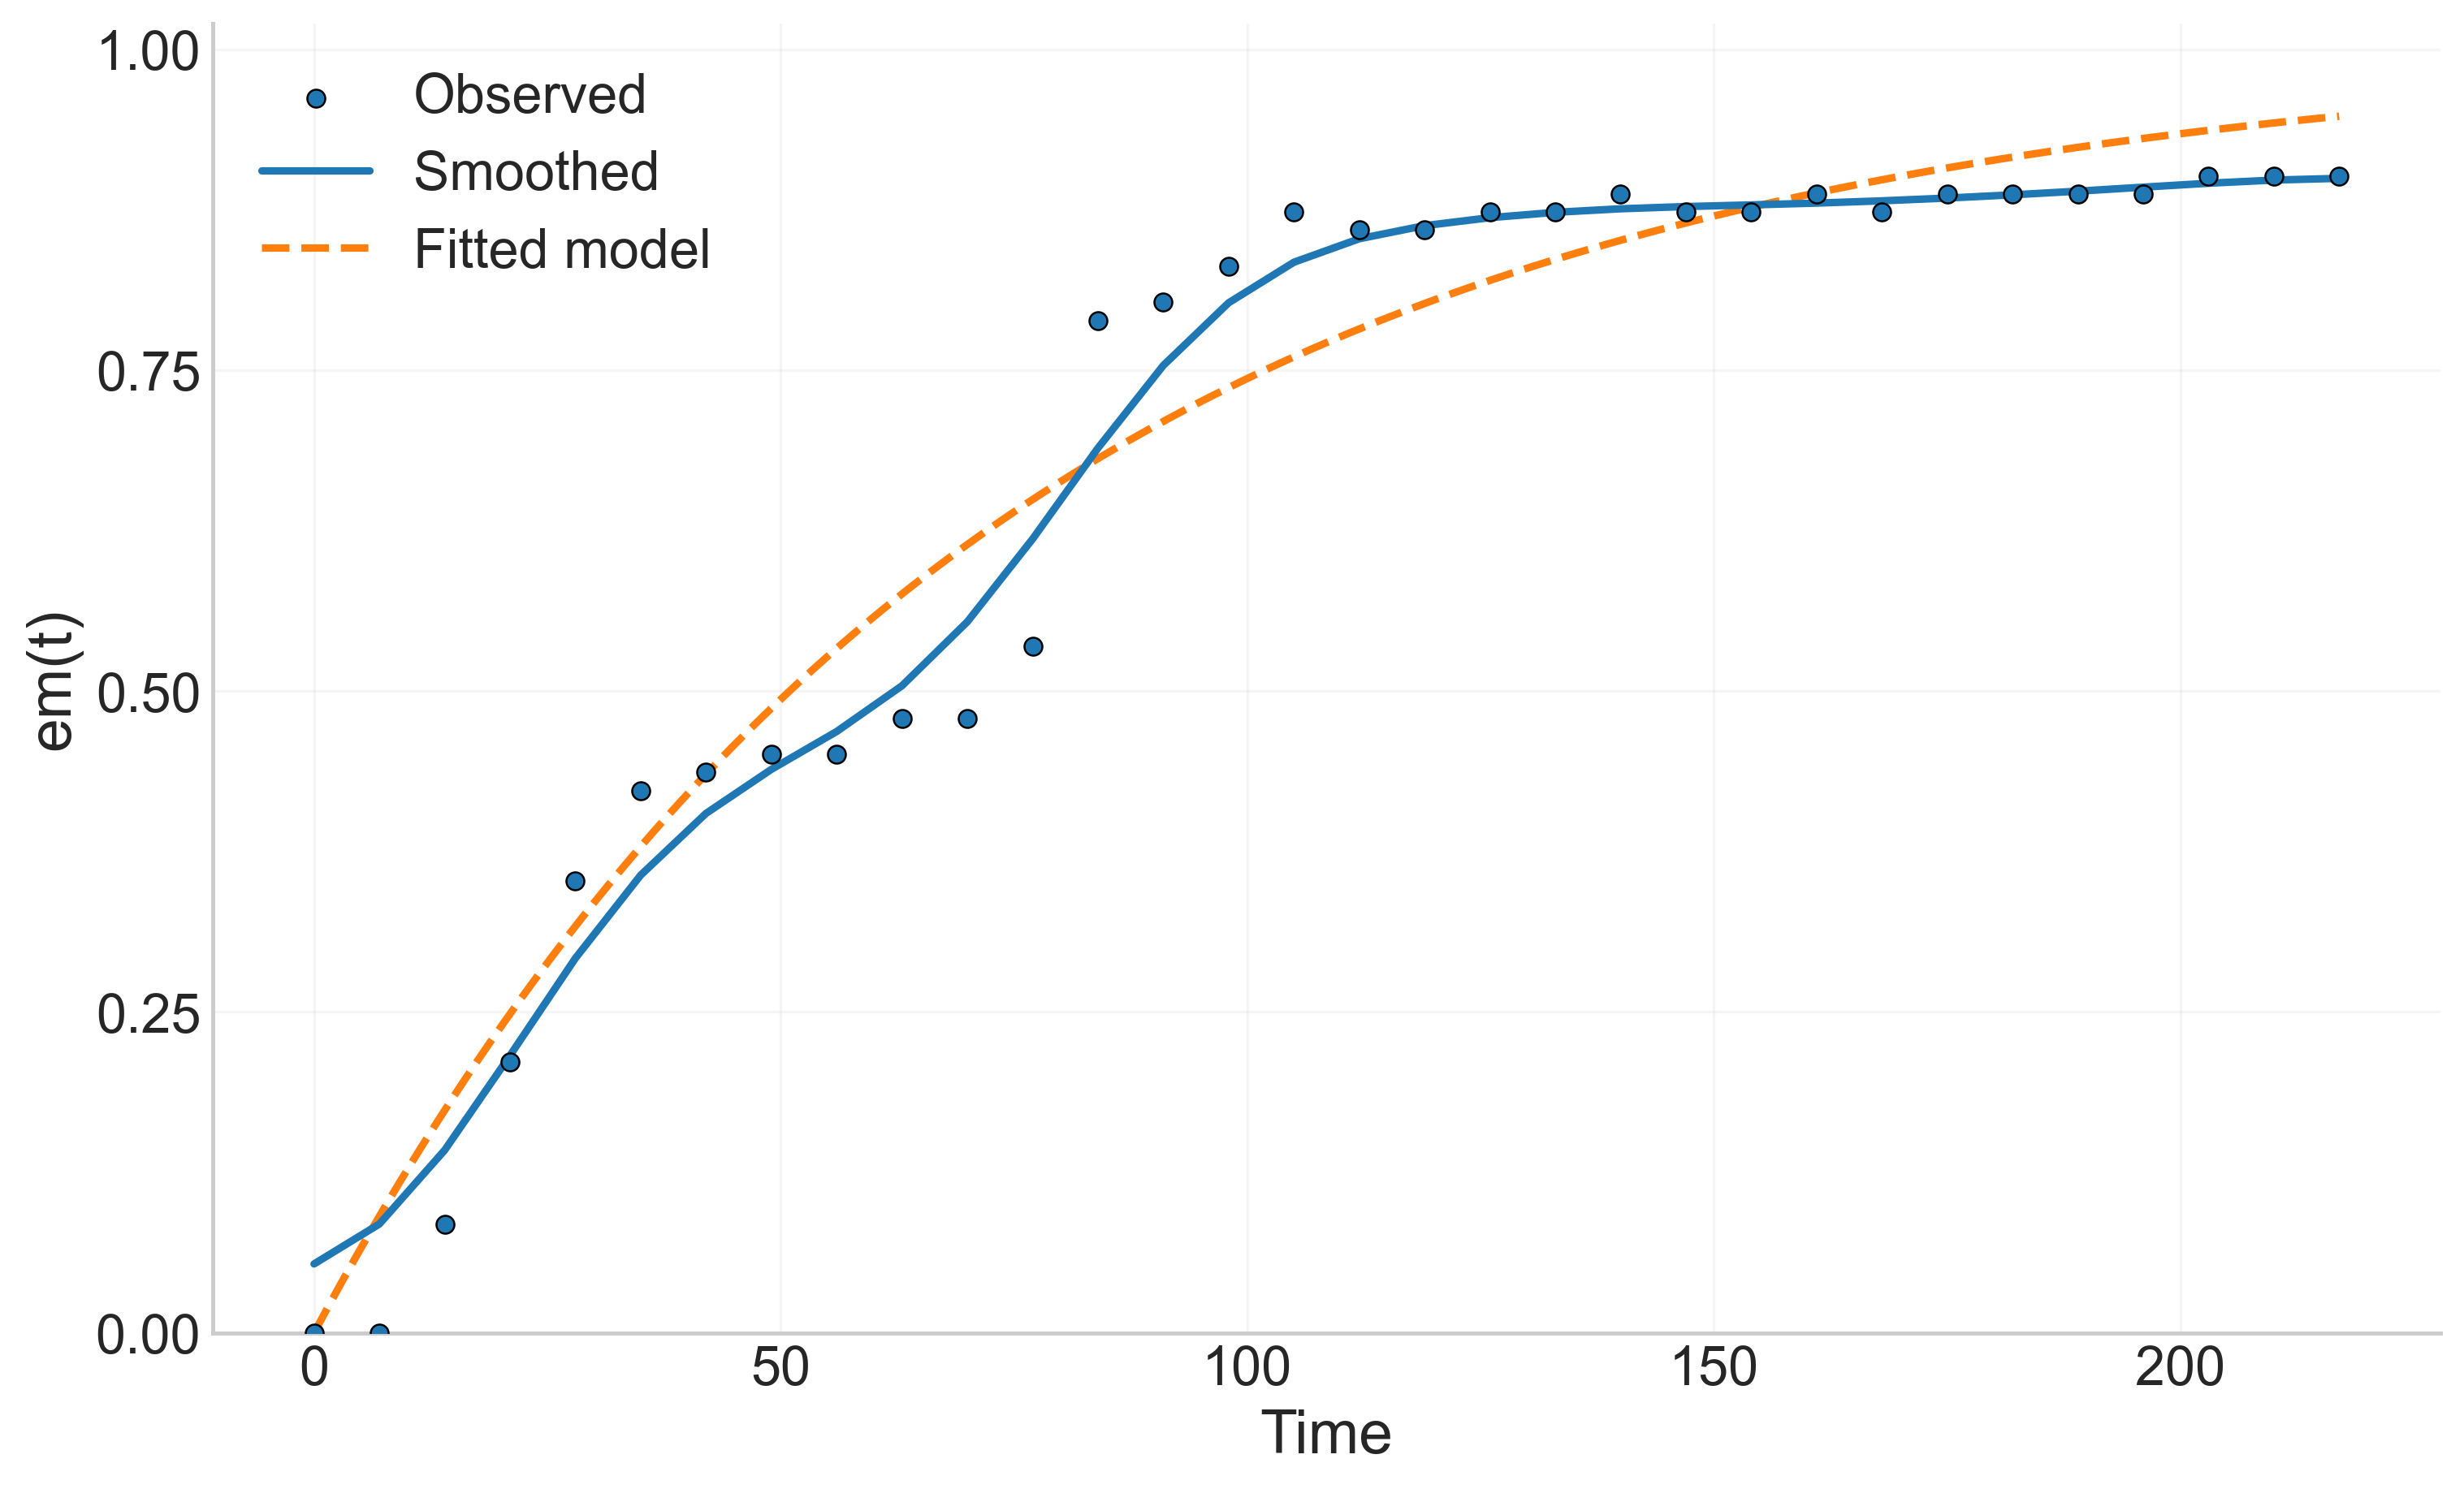

Figure saved to: A:\Research\1\Latex Versions\Manuscrpt 4.0\Main\Used Data\Rhinoceros Auklet North American Pacific Coast (GLS)-tracks.png


In [19]:
# Figure 5-B — Emigration dynamics from an initial convex-hull habitat.
"""
1) Loads tracking data with columns:
   - timestamp (datetime)
   - location-long, location-lat (floats)
   - individual-local-identifier (string/id)
2) Chooses a start time interval (e.g., week). Builds a convex hull from points in that interval.
3) Treats individuals inside that hull at the start as the "initial cohort".
4) For each interval in [start, end], computes the fraction of the initial cohort that is still
   inside the hull (a retention / "emigration rate" proxy).
5) Smooths the observed series and fits an exponential approach-to-asymptote model.

"""

from __future__ import annotations

import pathlib
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.ticker import MaxNLocator
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit
from scipy.spatial import ConvexHull


# Data loading


def load_and_preprocess(file_path: pathlib.Path, interval: str = "W") -> pd.DataFrame:
    """
    Load CSV data and create a pandas Period column for time binning.
    """
    df = pd.read_csv(file_path, parse_dates=["timestamp"])

    required = {"timestamp", "location-long", "location-lat", "individual-local-identifier"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    df["time_interval"] = df["timestamp"].dt.to_period(interval)
    return df


# Geometry + cohorts


def compute_initial_hull(
    df: pd.DataFrame, start_interval: pd.Period
) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    """
    Build the convex hull from points in the start interval and identify the initial cohort.

    The "initial cohort" is defined as unique individual IDs whose points (in the start interval)
    fall inside the convex-hull polygon.
    """
    start_df = df[df["time_interval"] == start_interval].copy()
    if start_df.empty:
        raise ValueError(f"No data found for start interval: {start_interval}")

    pts = start_df[["location-long", "location-lat"]].to_numpy(dtype=float)
    if len(pts) < 3:
        raise ValueError("Need at least 3 points to compute a convex hull.")

    hull = ConvexHull(pts)
    hull_pts = pts[hull.vertices]
    poly = Path(hull_pts)

    inside_mask = start_df.apply(
        lambda r: poly.contains_point((r["location-long"], r["location-lat"])),
        axis=1,
    )
    initial_ids = (
        start_df.loc[inside_mask, "individual-local-identifier"].astype(str).unique().tolist()
    )

    if len(initial_ids) == 0:
        raise ValueError("Initial cohort is empty (no individuals inside the start hull).")

    return pts, hull_pts, initial_ids


def retention_over_time(
    df: pd.DataFrame,
    hull_pts: np.ndarray,
    initial_ids: List[str],
    start: pd.Period,
    end: pd.Period,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute retention of the initial cohort inside the fixed hull over time.

    For each interval, retention = (# initial IDs observed inside hull) / (# initial IDs)
    """
    poly = Path(hull_pts)
    initial_set = set(initial_ids)
    total_initial = len(initial_set)

    dates: List[np.datetime64] = []
    retention: List[float] = []

    # Group by interval; assumes df is not necessarily sorted.
    for period, group in df.groupby("time_interval"):
        if period < start or period > end:
            continue

        inside = group.apply(
            lambda r: poly.contains_point((r["location-long"], r["location-lat"])),
            axis=1,
        )
        inside_ids = set(group.loc[inside, "individual-local-identifier"].astype(str).unique())
        keep = len(initial_set.intersection(inside_ids)) / total_initial

        dates.append(np.datetime64(period.start_time.to_datetime64()))
        retention.append(float(keep))

    if not dates:
        raise ValueError("No intervals found in the requested [start, end] range.")

    # Ensure chronological order
    order = np.argsort(np.asarray(dates))
    return np.asarray(dates)[order], np.asarray(retention)[order]


# Model fit


def fit_retention_model(days: np.ndarray, y: np.ndarray) -> Tuple[Tuple[float, float], float, np.ndarray]:
    def model(t_days: np.ndarray, A: float, k: float) -> np.ndarray:
        return 1 - np.exp(-k * t_days)

    best_r2 = -np.inf
    best_params: Tuple[float, float] | None = None
    best_pred: np.ndarray | None = None

    # Multi-start grid for robustness
    for A0 in np.linspace(0.05, 0.95, 10):
        for k0 in np.linspace(0.0005, 0.2, 12):
            try:
                popt, _ = curve_fit(
                    model,
                    days,
                    y,
                    p0=[A0, k0],
                    bounds=([0.0, 0.0], [1.0, np.inf]),
                    maxfev=20_000,
                )
                pred = model(days, *popt)
                ss_res = float(np.sum((y - pred) ** 2))
                ss_tot = float(np.sum((y - y.mean()) ** 2))
                r2 = 1.0 - (ss_res / ss_tot if ss_tot > 0 else np.inf)

                if r2 > best_r2:
                    best_r2 = r2
                    best_params = (float(popt[0]), float(popt[1]))
                    best_pred = pred
            except RuntimeError:
                continue

    if best_params is None or best_pred is None:
        raise RuntimeError("Model fitting failed for all initializations.")

    return best_params, float(best_r2), best_pred


# Plotting
@dataclass(frozen=True)
class PlotStyle:
    """A small bundle of plot styling defaults."""
    dpi: int = 300
    font_size: int = 18
    title_size: int = 20
    label_size: int = 18
    tick_size: int = 16
    legend_size: int = 16
    n_ticks: int = 5


def plot_retention(
    days: np.ndarray,
    retention: np.ndarray,
    smoothed: np.ndarray,
    t_fit: np.ndarray,
    y_fit: np.ndarray,
    save_path: pathlib.Path | None = None,
    title: str = "Figure 4-B: Retention inside initial hull",
    style: PlotStyle = PlotStyle(),
) -> None:
    """
    Single-panel plot (observed, smoothed, fitted model).
    """
    rc = {
        "figure.dpi": style.dpi,
        "font.size": style.font_size,
        "axes.titlesize": style.title_size,
        "axes.labelsize": style.label_size,
        "xtick.labelsize": style.tick_size,
        "ytick.labelsize": style.tick_size,
        "legend.fontsize": style.legend_size,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }

    with mpl.rc_context(rc):
        fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

        ax.scatter(days, 1-retention, s=28, edgecolor="k", linewidth=0.6, label="Observed", zorder=3)
        ax.plot(days, smoothed, linewidth=2.2, label="Smoothed", zorder=2)
        ax.plot(t_fit, y_fit, linestyle="--", linewidth=2.2, label="Fitted model", zorder=1)
        ax.set_xlabel("Time")
        ax.set_ylabel("em(t)")
        ax.set_ylim(0.0, 1.02)

        # fewer, nicer ticks
        ax.xaxis.set_major_locator(MaxNLocator(nbins=style.n_ticks))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=style.n_ticks))

        ax.grid(True, which="major", alpha=0.18)
        ax.legend(frameon=False, loc="best")

        if save_path is not None:
            save_path.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(save_path, bbox_inches="tight")

        plt.show()


# Main
def main() -> None:
    data_file = pathlib.Path(r"A:\Research\1\Latex Versions\Manuscrpt 4.0\Main\Used Data\Rhinoceros Auklet North American Pacific Coast (GLS)-tracks.csv")
    output_figure = pathlib.Path(r"A:\Research\1\Latex Versions\Manuscrpt 4.0\Main\Used Data\Rhinoceros Auklet North American Pacific Coast (GLS)-tracks.png")

    # Index bounds for the chosen interval window (as in your original code)
    start_idx, end_idx = 49, 80

    df = load_and_preprocess(data_file, interval="W")
    intervals = df["time_interval"].unique()
    if end_idx >= len(intervals) or start_idx < 0:
        raise IndexError("start_idx/end_idx out of range for available intervals.")

    start_period, end_period = intervals[start_idx], intervals[end_idx]

    _, hull_pts, initial_ids = compute_initial_hull(df, start_period)
    dates, retention = retention_over_time(df, hull_pts, initial_ids, start_period, end_period)

    # Smooth the observed series
    smoothed = gaussian_filter1d(1-retention, sigma=2)

    # Convert dates to day offsets for modeling/plotting
    days = (dates - dates[0]).astype("timedelta64[D]").astype(int)

    (A_opt, k_opt), r2, _ = fit_retention_model(days, 1-retention)
    print(f"Optimized A={A_opt:.4f}, k={k_opt:.4f}, R²={r2:.4f}")

    t_fit = np.linspace(days.min(), days.max(), 300)
    y_fit = 1 - np.exp(-k_opt * t_fit)

    plot_retention(
        days=days,
        retention=retention,
        smoothed=smoothed,
        t_fit=t_fit,
        y_fit=y_fit,
        save_path=output_figure,
    )
    print(f"Figure saved to: {output_figure}")


if __name__ == "__main__":
    main()


In [93]:
# Simulation of death and emigration rate for recaptures
import numpy as np

t1 = 10  # Marking period length
t2 = 10  # Gap period length
t3 = 10  # Recapture period length
k = 0.03  # Rate parameter for death distribution
N = 10000  # Number of individuals to simulate

m = np.random.uniform(0, t1, N)

u = np.random.uniform(0, t3, N)

T = (t1 - m) + t2 + u

death_probs = k * T

random_values = np.random.uniform(0, 1, N)
died = random_values < death_probs

simulated_bar_d = np.mean(died)

theoretical_bar_d = k * (t1/2 + t2 + t3/2)

# Death
print(simulated_bar_d, theoretical_bar_d)

death_probs = 1 - np.exp(-k * T)

random_values = np.random.uniform(0, 1, N)
died = random_values < death_probs

simulated_bar_em = np.mean(died)

term1 = 1 - np.exp(-k * t3)
term2 = np.exp(-k * t2) - np.exp(-k * (t1 + t2))
theoretical_bar_em = 1 - (term1 * term2) / (k**2 * t1 * t3)

#Emigration
print(simulated_bar_em, theoretical_bar_em)

0.5953 0.6
0.4392 0.4470599085081767


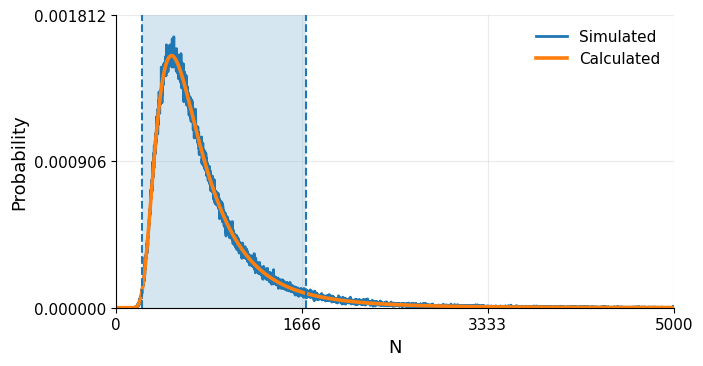


Category A – Scenario 1
Input datasets: [(50, 50, 5)]
Settings: CI_LEVEL=0.950, S=5000, K=5000, SEED=12345
* Simulation posterior (from PMF over N)
CI95%: (232, 1706)
Mode: 520 | Median: 662 | Mean: 793.03
* EHP
CI95%: (232, 1704)
Mode: 499 | Median: 662 | Mean: 792.824
* Established methods
LP point: 500.0
Chapman point: 432.5
Chapman log CI: (224.6237578346339, 832.7536312419332)
Exact hypergeom CI: (243, 1466.0)
* Distribution agreement (Simulation vs Calculated)
L1(sim, calc): 0.0442505
JS(sim, calc): 0.00106985
* Point-estimate comparisons (reference = Simulation mode)
Calculated (mode): est=499 | abs_err=21 | rel_err=0.0403846
Simulated (mode): est=520 | abs_err=0 | rel_err=0
LP point: est=500 | abs_err=20 | rel_err=0.0384615
Chapman point: est=432.5 | abs_err=87.5 | rel_err=0.168269
* CI comparisons (reference = Simulation CI)
Calculated CI: CI=(232.0, 1704.0) | width=1472 | width_ratio=0.998643 | overlap=1472 | jaccard=0.998643
Chapman log CI: CI=(224.6237578346339, 832.753631

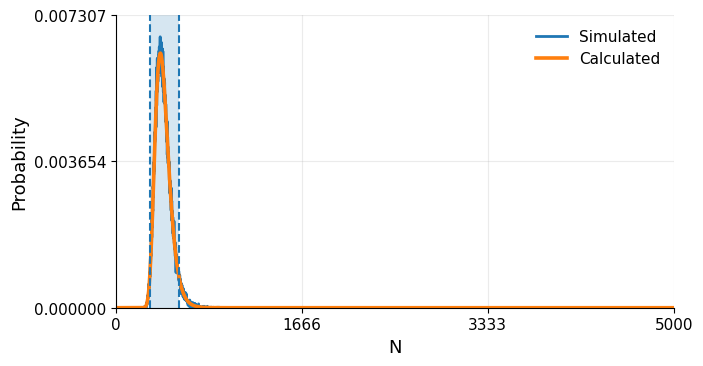


Category A – Scenario 2
Input datasets: [(100, 100, 25)]
Settings: CI_LEVEL=0.950, S=5000, K=5000, SEED=12345
* Simulation posterior (from PMF over N)
CI95%: (304, 564)
Mode: 398 | Median: 417 | Mean: 426.057
* EHP
CI95%: (305, 566)
Mode: 399 | Median: 417 | Mean: 426.13
* Established methods
LP point: 400.0
Chapman point: 391.34615384615387
Chapman log CI: (295.53322600277676, 518.2219752466633)
Exact hypergeom CI: (304, 569.0)
* Distribution agreement (Simulation vs Calculated)
L1(sim, calc): 0.045712
JS(sim, calc): 0.000946552
* Point-estimate comparisons (reference = Simulation mode)
Calculated (mode): est=399 | abs_err=1 | rel_err=0.00251256
Simulated (mode): est=398 | abs_err=0 | rel_err=0
LP point: est=400 | abs_err=2 | rel_err=0.00502513
Chapman point: est=391.346 | abs_err=6.65385 | rel_err=0.0167182
* CI comparisons (reference = Simulation CI)
Calculated CI: CI=(305.0, 566.0) | width=261 | width_ratio=1.00385 | overlap=259 | jaccard=0.98855
Chapman log CI: CI=(295.5332260027

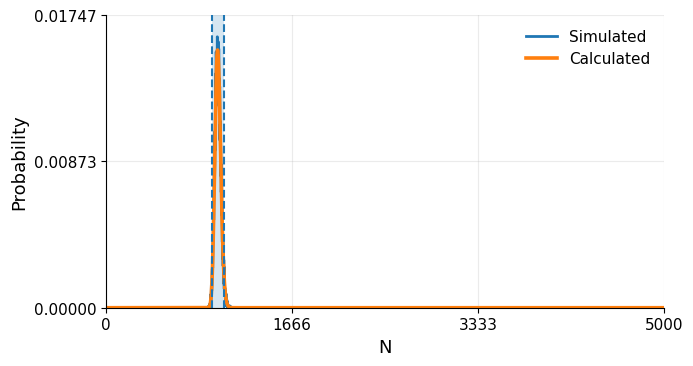


Category A – Scenario 3
Input datasets: [(500, 600, 300)]
Settings: CI_LEVEL=0.950, S=5000, K=5000, SEED=12345
* Simulation posterior (from PMF over N)
CI95%: (952, 1053)
Mode: 997 | Median: 1002 | Mean: 1002.79
* EHP
CI95%: (953, 1055)
Mode: 999 | Median: 1002 | Mean: 1003.02
* Established methods
LP point: 1000.0
Chapman point: 999.3355481727575
Chapman log CI: (950.2207467929557, 1050.988984625219)
Exact hypergeom CI: (953, 1057.0)
* Distribution agreement (Simulation vs Calculated)
L1(sim, calc): 0.0674336
JS(sim, calc): 0.00150882
* Point-estimate comparisons (reference = Simulation mode)
Calculated (mode): est=999 | abs_err=2 | rel_err=0.00200602
Simulated (mode): est=997 | abs_err=0 | rel_err=0
LP point: est=1000 | abs_err=3 | rel_err=0.00300903
Chapman point: est=999.336 | abs_err=2.33555 | rel_err=0.00234258
* CI comparisons (reference = Simulation CI)
Calculated CI: CI=(953.0, 1055.0) | width=102 | width_ratio=1.0099 | overlap=100 | jaccard=0.970874
Chapman log CI: CI=(950.2

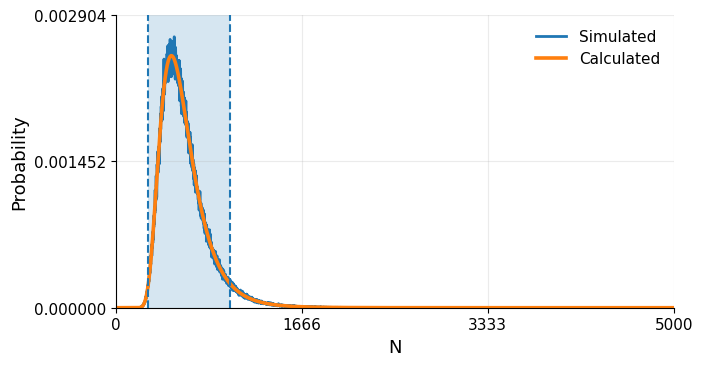


Category B – Scenario 1
Input datasets: [(50, 50, 5), (50, 50, 5)]
Settings: CI_LEVEL=0.950, S=5000, K=5000, SEED=12345
* Simulation posterior (from PMF over N)
CI95%: (291, 1028)
Mode: 525 | Median: 569 | Mean: 612.309
* EHP
CI95%: (293, 1029)
Mode: 499 | Median: 569 | Mean: 612.31
* Established methods
Schnabel point: 500.0
Schumacher–Eschmeyer point: 500.0
Schnabel Poisson CI: (271.8816312515178, 1042.6683459533924)
Schumacher–Eschmeyer t CI: (nan, nan)
* Distribution agreement (Simulation vs Calculated)
L1(sim, calc): 0.0391441
JS(sim, calc): 0.000352639
* Point-estimate comparisons (reference = Simulation mode)
Calculated (mode): est=499 | abs_err=26 | rel_err=0.0495238
Simulated (mode): est=525 | abs_err=0 | rel_err=0
Schnabel point: est=500 | abs_err=25 | rel_err=0.047619
Schumacher–Eschmeyer point: est=500 | abs_err=25 | rel_err=0.047619
* CI comparisons (reference = Simulation CI)
Calculated CI: CI=(293.0, 1029.0) | width=736 | width_ratio=0.998643 | overlap=735 | jaccard=0.9

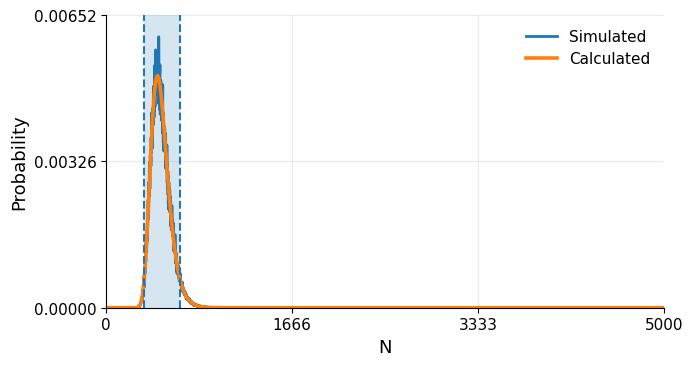


Category B – Scenario 2
Input datasets: [(70, 60, 10), (60, 50, 8), (80, 70, 10)]
Settings: CI_LEVEL=0.950, S=5000, K=5000, SEED=12345
* Simulation posterior (from PMF over N)
CI95%: (342, 660)
Mode: 471 | Median: 480 | Mean: 490.745
* EHP
CI95%: (341, 659)
Mode: 460 | Median: 480 | Mean: 490.315
* Established methods
Schnabel point: 457.14285714285717
Schumacher–Eschmeyer point: 465.65656565656565
Schnabel Poisson CI: (316.30089313350106, 687.9576422743644)
Schumacher–Eschmeyer t CI: (147.237283896173, inf)
* Distribution agreement (Simulation vs Calculated)
L1(sim, calc): 0.0581656
JS(sim, calc): 0.000717562
* Point-estimate comparisons (reference = Simulation mode)
Calculated (mode): est=460 | abs_err=11 | rel_err=0.0233546
Simulated (mode): est=471 | abs_err=0 | rel_err=0
Schnabel point: est=457.143 | abs_err=13.8571 | rel_err=0.0294207
Schumacher–Eschmeyer point: est=465.657 | abs_err=5.34343 | rel_err=0.0113449
* CI comparisons (reference = Simulation CI)
Calculated CI: CI=(341.

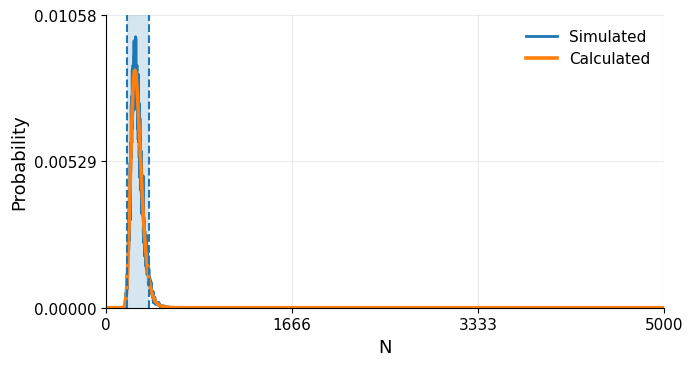


Category B – Scenario 3
Input datasets: [(50, 60, 8), (30, 70, 10), (20, 20, 4)]
Settings: CI_LEVEL=0.950, S=5000, K=5000, SEED=12345
* Simulation posterior (from PMF over N)
CI95%: (192, 386)
Mode: 264 | Median: 272 | Mean: 279.773
* EHP
CI95%: (190, 384)
Mode: 259 | Median: 273 | Mean: 280
* Established methods
Schnabel point: 250.0
Schumacher–Eschmeyer point: 283.3333333333333
Schnabel Poisson CI: (165.1241846791013, 398.91834025383764)
Schumacher–Eschmeyer t CI: (42.67428418156229, inf)
* Distribution agreement (Simulation vs Calculated)
L1(sim, calc): 0.0989566
JS(sim, calc): 0.00227395
* Point-estimate comparisons (reference = Simulation mode)
Calculated (mode): est=259 | abs_err=5 | rel_err=0.0189394
Simulated (mode): est=264 | abs_err=0 | rel_err=0
Schnabel point: est=250 | abs_err=14 | rel_err=0.0530303
Schumacher–Eschmeyer point: est=283.333 | abs_err=19.3333 | rel_err=0.0732323
* CI comparisons (reference = Simulation CI)
Calculated CI: CI=(190.0, 384.0) | width=194 | width

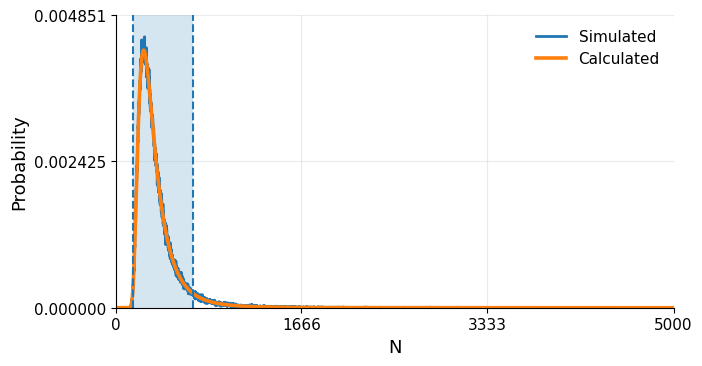


Category C – Scenario 1
Input datasets: [(50, 60, 5)]  | omega=0.3
Settings: CI_LEVEL=0.950, S=5000, K=5000, SEED=12345
* Simulation posterior (from PMF over N)
CI95%: (154, 691)
Mode: 260 | Median: 311 | Mean: 360.665
* EHP
CI95%: (154, 694)
Mode: 252 | Median: 311 | Mean: 360.904
* Established methods
Chao point: 605.0
NCHG MLE point: 252
Chao normal CI: (122.91260268288016, 1087.08739731712)
NCHG profile CI: (164, 545)
* Distribution agreement (Simulation vs Calculated)
L1(sim, calc): 0.0437768
JS(sim, calc): 0.00159691
* Point-estimate comparisons (reference = Simulation mode)
Calculated (mode): est=252 | abs_err=8 | rel_err=0.0307692
Simulated (mode): est=260 | abs_err=0 | rel_err=0
Chao point: est=605 | abs_err=345 | rel_err=1.32692
NCHG MLE point: est=252 | abs_err=8 | rel_err=0.0307692
* CI comparisons (reference = Simulation CI)
Calculated CI: CI=(154.0, 694.0) | width=540 | width_ratio=1.00559 | overlap=537 | jaccard=0.994444
Chao normal CI: CI=(122.91260268288016, 1087.0873

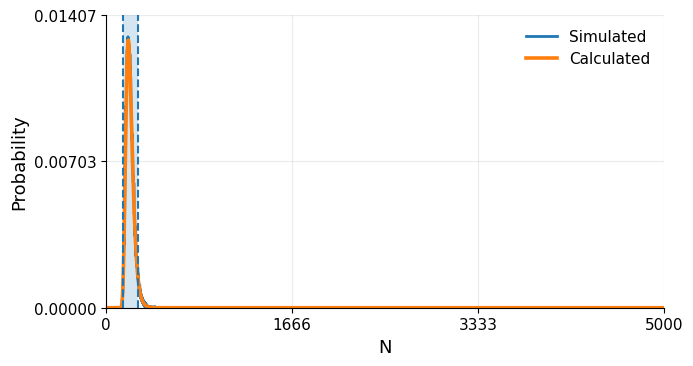


Category C – Scenario 2
Input datasets: [(60, 70, 20)]  | omega=0.9
Settings: CI_LEVEL=0.950, S=5000, K=5000, SEED=12345
* Simulation posterior (from PMF over N)
CI95%: (154, 285)
Mode: 197 | Median: 209 | Mean: 214.525
* EHP
CI95%: (155, 286)
Mode: 199 | Median: 209 | Mean: 214.448
* Established methods
Chao point: 211.25
NCHG MLE point: 199
Chao normal CI: (147.1542892203375, 275.3457107796625)
NCHG profile CI: (156, 279)
* Distribution agreement (Simulation vs Calculated)
L1(sim, calc): 0.0414513
JS(sim, calc): 0.000846503
* Point-estimate comparisons (reference = Simulation mode)
Calculated (mode): est=199 | abs_err=2 | rel_err=0.0101523
Simulated (mode): est=197 | abs_err=0 | rel_err=0
Chao point: est=211.25 | abs_err=14.25 | rel_err=0.072335
NCHG MLE point: est=199 | abs_err=2 | rel_err=0.0101523
* CI comparisons (reference = Simulation CI)
Calculated CI: CI=(155.0, 286.0) | width=131 | width_ratio=1 | overlap=130 | jaccard=0.984848
Chao normal CI: CI=(147.1542892203375, 275.345

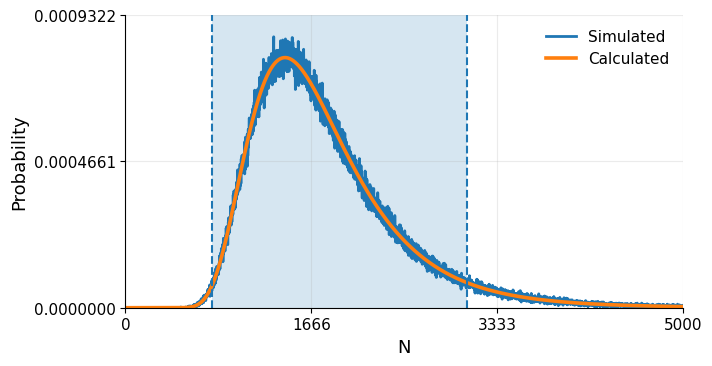


Category C – Scenario 3
Input datasets: [(100, 80, 10)]  | omega=2.0
Settings: CI_LEVEL=0.950, S=5000, K=5000, SEED=12345
* Simulation posterior (from PMF over N)
CI95%: (776, 3065)
Mode: 1329 | Median: 1647 | Mean: 1775.5
* EHP
CI95%: (785, 3071)
Mode: 1430 | Median: 1648 | Mean: 1775.92
* Established methods
Chao point: 810.0
NCHG MLE point: 1430
Chao normal CI: (363.74757674071566, 1256.2524232592843)
NCHG profile CI: (824, 2843)
* Distribution agreement (Simulation vs Calculated)
L1(sim, calc): 0.045139
JS(sim, calc): 0.000650229
* Point-estimate comparisons (reference = Simulation mode)
Calculated (mode): est=1430 | abs_err=101 | rel_err=0.075997
Simulated (mode): est=1329 | abs_err=0 | rel_err=0
Chao point: est=810 | abs_err=519 | rel_err=0.390519
NCHG MLE point: est=1430 | abs_err=101 | rel_err=0.075997
* CI comparisons (reference = Simulation CI)
Calculated CI: CI=(785.0, 3071.0) | width=2286 | width_ratio=0.998689 | overlap=2280 | jaccard=0.993464
Chao normal CI: CI=(363.7475

In [1]:
# Figure 6 + Table 6

import math
import numpy as np
import matplotlib.pyplot as plt

# Imports from ready to use functions
from ehpmarkrecap import ehp  # DeepMR
from Simulation import simulate_r_values, normalized_probabilities_for_r  # simulation
from OtherMethods import (
    # Single-dataset classic
    lp_mle_point, chapman_point, chapman_log_ci, exact_hypergeom_ci,
    # Multiple datasets (sequential MR estimators)
    schnabel_point, schumacher_eschmeyer_point, schnabel_poisson_ci, schumacher_eschmeyer_t_ci,
    # Heterogeneity comparators
    chao_point_two_sample, chao_normal_ci_two_sample,
    nchypergeom_mle_point, nchypergeom_profile_ci,
)

# SETTINGS
CI_LEVEL = 0.95
S = 5000           # simulation replicates per scenario (per dataset, per N)
K = 5000           # max N (support 0..K)
SEED = 12345       # reproducibility

# list of indices per category (1-based indices)
SCENARIOS_TO_RUN = {
    "A": [1, 2, 3],
    "B": [1, 2, 3],
    "C": [1, 2, 3],
}

STYLE = {
    # Fonts
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,

    # Lines / alpha
    "lw_sim": 2.0,
    "lw_calc": 2.6,
    "lw_ci": 1.5,
    "alpha_ci": 0.18,

    # Figure
    "figsize": (7.2, 3.8),

    # Numeric stability
    "eps_sim": 1e-12,      # smoothing for Monte Carlo p_hat across N
    "eps_log": 1e-300,     # to avoid log(0) in products / divergences
}

# Apply global matplotlib styling
plt.rcParams.update({
    "font.size": STYLE["font.size"],
    "axes.labelsize": STYLE["axes.labelsize"],
    "xtick.labelsize": STYLE["xtick.labelsize"],
    "ytick.labelsize": STYLE["ytick.labelsize"],
    "legend.fontsize": STYLE["legend.fontsize"],
})



# Helpers

def logsumexp(a: np.ndarray) -> float:
    a = np.asarray(a, dtype=float)
    m = np.max(a)
    if not np.isfinite(m):
        return -np.inf
    return float(m + np.log(np.sum(np.exp(a - m))))

def ci_mode_expand_from_pmf(domain: np.ndarray, pmf: np.ndarray, alpha: float) -> tuple[int, int]:
    """
    Contiguous greedy mode-expansion CI (matches the approach used in ehp for bounded pmfs).
    """
    domain = np.asarray(domain, dtype=int)
    pmf = np.asarray(pmf, dtype=float)
    pmf = pmf / pmf.sum() if pmf.sum() > 0 else pmf

    idx_mode = int(np.argmax(pmf))
    L = U = idx_mode
    cum = float(pmf[idx_mode])
    target = 1.0 - alpha

    while cum < target - 1e-15:
        p_left = pmf[L - 1] if L > 0 else -1.0
        p_right = pmf[U + 1] if U < len(pmf) - 1 else -1.0

        if p_left < 0 and p_right < 0:
            break

        if p_left >= p_right:
            L -= 1
            cum += float(pmf[L])
        else:
            U += 1
            cum += float(pmf[U])

        if L == 0 and U == len(pmf) - 1:
            break

    return int(domain[L]), int(domain[U])

def pmf_summaries(domain: np.ndarray, pmf: np.ndarray, alpha: float) -> dict:
    domain = np.asarray(domain, dtype=int)
    pmf = np.asarray(pmf, dtype=float)
    s = float(pmf.sum())
    pmf = pmf / s if s > 0 else pmf

    idx_mode = int(np.argmax(pmf))
    mode = int(domain[idx_mode])
    mean = float(np.sum(domain * pmf))
    cdf = np.cumsum(pmf)
    median = int(domain[np.searchsorted(cdf, 0.5)])
    ci_low, ci_high = ci_mode_expand_from_pmf(domain, pmf, alpha=alpha)

    return {
        "mode": mode,
        "mean": mean,
        "median": median,
        "ci": (ci_low, ci_high),
        "pmf_sum": float(pmf.sum()),
    }

def pad_to_full_support(domain_part: np.ndarray, pmf_part: np.ndarray, K: int) -> np.ndarray:
    full = np.zeros(K + 1, dtype=float)
    domain_part = np.asarray(domain_part, dtype=int)
    pmf_part = np.asarray(pmf_part, dtype=float)
    mask = (domain_part >= 0) & (domain_part <= K)
    full[domain_part[mask]] = pmf_part[mask]
    return full

def interval_metrics(ci: tuple[float, float], ref_ci: tuple[float, float]) -> dict:
    a, b = ci
    r1, r2 = ref_ci
    width = (b - a) if (np.isfinite(a) and np.isfinite(b)) else math.inf
    ref_width = (r2 - r1) if (np.isfinite(r1) and np.isfinite(r2)) else math.inf

    # overlap
    if not (np.isfinite(a) and np.isfinite(b) and np.isfinite(r1) and np.isfinite(r2)):
        overlap = math.nan
        jaccard = math.nan
    else:
        inter = max(0.0, min(b, r2) - max(a, r1))
        union = max(b, r2) - min(a, r1)
        overlap = inter
        jaccard = (inter / union) if union > 0 else math.nan

    return {
        "width": width,
        "ref_width": ref_width,
        "width_ratio": (width / ref_width) if (ref_width not in (0.0, math.inf) and np.isfinite(width)) else math.nan,
        "overlap": overlap,
        "jaccard": jaccard,
    }

def js_divergence(p: np.ndarray, q: np.ndarray, eps: float) -> float:
    """
    Jensen–Shannon divergence (base-e).
    """
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    p = p / p.sum() if p.sum() > 0 else p
    q = q / q.sum() if q.sum() > 0 else q

    p = np.clip(p, eps, None)
    q = np.clip(q, eps, None)
    p = p / p.sum()
    q = q / q.sum()

    m = 0.5 * (p + q)
    return 0.5 * float(np.sum(p * np.log(p / m))) + 0.5 * float(np.sum(q * np.log(q / m)))

def l1_distance(p: np.ndarray, q: np.ndarray) -> float:
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    p = p / p.sum() if p.sum() > 0 else p
    q = q / q.sum() if q.sum() > 0 else q
    return float(np.sum(np.abs(p - q)))

def safe_float(x):
    try:
        if x is None:
            return math.nan
        x = float(x)
        return x
    except Exception:
        return math.nan


# Simulation -> posterior pmf over N

_sim_cache = {}  # cache dataset-level simulated posterior over N (full length K+1)

def simulated_pmf_single_dataset(m: int, C: int, r: int, *, phi: float, omega: float, K: int, S: int, seed: int) -> np.ndarray:
    """
    Returns pmf over N=0..K from simulation, normalized across feasible N.
    Uses a tiny epsilon smoothing on p_hat(N) to avoid all-zero issues.
    """
    key = (m, C, r, float(phi), float(omega), K, S, seed)
    if key in _sim_cache:
        return _sim_cache[key].copy()

    N_min = m + C - r
    r_by_N = simulate_r_values(
        N_min=N_min, K=K,
        m=m, C=C,
        phi=phi, omega=omega,
        Simulations=S,
        Seed=seed,
    )
    Ns, p_norm, p_hat = normalized_probabilities_for_r(r_by_N, r_target=r)

    # Smooth using p_hat (MC estimate of P(r|N)) then renormalize
    p_smooth = p_hat + STYLE["eps_sim"]
    p_smooth = p_smooth / p_smooth.sum() if p_smooth.sum() > 0 else p_smooth

    pmf_full = np.zeros(K + 1, dtype=float)
    pmf_full[Ns] = p_smooth  # Ns are in [N_min..K]

    _sim_cache[key] = pmf_full.copy()
    return pmf_full

def combine_normalized_pmfs(pmfs_full: list[np.ndarray], N_min: int, K: int) -> np.ndarray:
    """
    Combine normalized PMFs by multiplying (in log space) and renormalizing once more.
    """
    logp = np.zeros(K + 1, dtype=float)
    for p in pmfs_full:
        p = np.asarray(p, dtype=float)
        logp += np.log(np.clip(p, STYLE["eps_log"], None))

    logp[:N_min] = -np.inf  # enforce common feasibility support
    z = logsumexp(logp[N_min:])
    if not np.isfinite(z):
        # Fallback: uniform over [N_min..K]
        out = np.zeros(K + 1, dtype=float)
        out[N_min:] = 1.0 / (K - N_min + 1)
        return out

    out = np.zeros(K + 1, dtype=float)
    out[N_min:] = np.exp(logp[N_min:] - z)
    return out


# Scenarios

SCENARIOS = {
    "A": [
        {"datasets": [(50, 50, 5)], "omega": 1.0},     # A1
        {"datasets": [(100, 100, 25)], "omega": 1.0},  # A2
        {"datasets": [(500, 600, 300)], "omega": 1.0}, # A3
    ],
    "B": [
        {"datasets": [(50, 50, 5), (50, 50, 5)], "omega": 1.0},  # B1
        {"datasets": [(70, 60, 10), (60, 50, 8), (80, 70, 10)], "omega": 1.0},  # B2
        {"datasets": [(50, 60, 8), (30, 70, 10), (20, 20, 4)], "omega": 1.0},   # B3
    ],
    "C": [
        {"datasets": [(50, 60, 5)], "omega": 0.3},   # C1
        {"datasets": [(60, 70, 20)], "omega": 0.9},  # C2
        {"datasets": [(100, 80, 10)], "omega": 2.0}, # C3
    ],
}


# Plot + print per scenario

def plot_one_panel(
    category: str,
    scen_idx_1based: int,
    datasets: list[tuple[int, int, int]],
    omega: float,
    *,
    K: int,
    S: int,
    base_seed: int,
    alpha: float,
):
    # Common support lower bound (matches ehp: max(m+C-r) across datasets)
    N_min = max(m + C - r for (m, C, r) in datasets)
    x_full = np.arange(0, K + 1, dtype=int)

    # Simulation PMF-
    # For classic & hetero scenarios, phi=1.0 (not provided in your scenarios)
    phi = 1.0

    # cache identical dataset simulations within a scenario (e.g., B1)
    pmfs = []
    for j, (m, C, r) in enumerate(datasets):
        seed_j = base_seed + 10_000 * (hash((category, scen_idx_1based)) % 10_000) + 97 * j
        pmf_j = simulated_pmf_single_dataset(m, C, r, phi=phi, omega=omega, K=K, S=S, seed=seed_j)
        pmfs.append(pmf_j)

    if len(pmfs) == 1:
        pmf_sim_full = pmfs[0]
    else:
        pmf_sim_full = combine_normalized_pmfs(pmfs, N_min=N_min, K=K)

    sim_stats = pmf_summaries(x_full[N_min:], pmf_sim_full[N_min:], alpha=alpha)

    # ehp
    if category in ("A", "B"):
        res_calc = ehp(datasets[0] if len(datasets) == 1 else datasets, K=K, alpha=alpha)
    else:  # "C"
        # heterogeneity uses omega; phi -> default to 1
        res_calc = ehp(datasets[0], K=K, omega=float(omega), alpha=alpha)

    pmf_calc_full = pad_to_full_support(res_calc["domain"], res_calc["pmf"], K=K)
    calc_stats = {
        "mode": int(res_calc["mode"]),
        "mean": float(res_calc["mean"]),
        "median": int(res_calc["median"]),
        "ci": (int(res_calc["ci_low"]), int(res_calc["ci_high"])),
    }

    # Plot
    fig, ax = plt.subplots(figsize=STYLE["figsize"])

    ax.plot(x_full, pmf_sim_full, linewidth=STYLE["lw_sim"], label="Simulated")
    ax.plot(x_full, pmf_calc_full, linewidth=STYLE["lw_calc"], label="Calculated")

    # Simulation CI: dashed lines + shaded vertical band
    ciL, ciU = sim_stats["ci"]
    ax.axvspan(ciL, ciU, alpha=STYLE["alpha_ci"])
    ax.axvline(ciL, linestyle="--", linewidth=STYLE["lw_ci"])
    ax.axvline(ciU, linestyle="--", linewidth=STYLE["lw_ci"])

    # Labels, limits, ticks (per requirements)
    ax.set_xlabel("N")
    ax.set_ylabel("Probability")
    ax.set_xlim(0, K)

    # x ticks: 3–4 ticks
    xt = np.linspace(0, K, 4, dtype=int)
    ax.set_xticks(xt)

    # y ticks: 2–3 ticks
    ymax = max(float(np.max(pmf_sim_full)), float(np.max(pmf_calc_full)))
    ax.set_ylim(0, ymax * 1.08 if ymax > 0 else 1.0)

    # choose ~3 y ticks
    ax.set_yticks(np.linspace(0, ax.get_ylim()[1], 3))

    # professional-ish styling
    ax.grid(True, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False)

    # No title
    plt.show()

    # Established methods
    established = {}

    if category == "A":
        (m, C, r) = datasets[0]

        established["LP point"] = lp_mle_point(m, C, r)
        established["Chapman point"] = chapman_point(m, C, r)

        established["Chapman log CI"] = chapman_log_ci(m, C, r, alpha=alpha)
        # pass K as K_max so upper isn't infinite in bounded setting
        established["Exact hypergeom CI"] = exact_hypergeom_ci(m, C, r, alpha=alpha, K_max=K)

    elif category == "B":
        ms = [d[0] for d in datasets]
        Cs = [d[1] for d in datasets]
        rs = [d[2] for d in datasets]

        established["Schnabel point"] = schnabel_point(ms, Cs, rs)
        established["Schumacher–Eschmeyer point"] = schumacher_eschmeyer_point(ms, Cs, rs)

        # CI methods
        try:
            established["Schnabel Poisson CI"] = schnabel_poisson_ci(ms, Cs, rs, alpha=alpha)
        except Exception:
            established["Schnabel Poisson CI"] = (math.nan, math.nan)

        try:
            established["Schumacher–Eschmeyer t CI"] = schumacher_eschmeyer_t_ci(ms, Cs, rs, alpha=alpha)
        except Exception:
            # Note: function requires >=3 occasions; B1 has 2.
            established["Schumacher–Eschmeyer t CI"] = (math.nan, math.nan)

    else:  # category == "C"
        (m, C, r) = datasets[0]

        established["Chao point"] = chao_point_two_sample(m, C, r)
        try:
            established["NCHG MLE point"] = nchypergeom_mle_point(m, C, r, omega=float(omega), K=K)
        except Exception:
            established["NCHG MLE point"] = math.nan

        established["Chao normal CI"] = chao_normal_ci_two_sample(m, C, r, alpha=alpha)
        try:
            established["NCHG profile CI"] = nchypergeom_profile_ci(m, C, r, omega=float(omega), K=K, alpha=alpha)
        except Exception:
            established["NCHG profile CI"] = (math.nan, math.nan)

    # Comparison metrics
    dist_metrics = {
        "L1(sim, calc)": l1_distance(pmf_sim_full[N_min:], pmf_calc_full[N_min:]),
        "JS(sim, calc)": js_divergence(pmf_sim_full[N_min:], pmf_calc_full[N_min:], eps=STYLE["eps_log"]),
    }

    # point estimate comparisons (use sim mode as the reference point estimate)
    def point_err(name: str, est_val: float) -> dict:
        est = safe_float(est_val)
        if not np.isfinite(est):
            return {"method": name, "est": est, "abs_err_vs_sim_mode": math.nan, "rel_err_vs_sim_mode": math.nan}
        abs_err = abs(est - sim_stats["mode"])
        rel_err = abs_err / sim_stats["mode"] if sim_stats["mode"] != 0 else math.nan
        return {"method": name, "est": est, "abs_err_vs_sim_mode": abs_err, "rel_err_vs_sim_mode": rel_err}

    point_comparisons = []
    # My method point estimate: mode
    point_comparisons.append(point_err("Calculated (mode)", calc_stats["mode"]))
    point_comparisons.append(point_err("Simulated (mode)", sim_stats["mode"]))

    # Established point estimators
    for kname, val in established.items():
        if "point" in kname.lower():
            point_comparisons.append(point_err(kname, val))

    # CI comparisons (compare any CI methods to simulation CI)
    ci_comparisons = []
    sim_ci = sim_stats["ci"]
    for kname, val in established.items():
        if "ci" in kname.lower():
            try:
                ci = (float(val[0]), float(val[1]))
            except Exception:
                ci = (math.nan, math.nan)
            m = interval_metrics(ci, sim_ci)
            ci_comparisons.append((kname, ci, m))

    # Also compare my method CI to simulation CI
    ci_comparisons.insert(0, ("Calculated CI", (float(calc_stats["ci"][0]), float(calc_stats["ci"][1])),
                              interval_metrics((float(calc_stats["ci"][0]), float(calc_stats["ci"][1])), sim_ci)))

    # Print summary
    print("\n" + "=" * 90)
    print(f"Category {category} – Scenario {scen_idx_1based}")
    if category == "C":
        print(f"Input datasets: {datasets}  | omega={omega}")
    else:
        print(f"Input datasets: {datasets}")
    print(f"Settings: CI_LEVEL={1-alpha:.3f}, S={S}, K={K}, SEED={base_seed}")

    print("* Simulation posterior (from PMF over N)")
    print(f"CI{int((1-alpha)*100)}%: {sim_stats['ci']}")
    print(f"Mode: {sim_stats['mode']} | Median: {sim_stats['median']} | Mean: {sim_stats['mean']:.6g}")

    print("* EHP")
    print(f"CI{int((1-alpha)*100)}%: {calc_stats['ci']}")
    print(f"Mode: {calc_stats['mode']} | Median: {calc_stats['median']} | Mean: {calc_stats['mean']:.6g}")

    print("* Established methods")
    for kname, val in established.items():
        print(f"{kname}: {val}")

    print("* Distribution agreement (Simulation vs Calculated)")
    for kname, val in dist_metrics.items():
        print(f"{kname}: {val:.6g}")

    print("* Point-estimate comparisons (reference = Simulation mode)")
    for row in point_comparisons:
        est = row["est"]
        est_str = "inf" if est == math.inf else (f"{est:.6g}" if np.isfinite(est) else "nan")
        print(f"{row['method']}: est={est_str} | abs_err={row['abs_err_vs_sim_mode']:.6g} | rel_err={row['rel_err_vs_sim_mode']:.6g}")

    print("* CI comparisons (reference = Simulation CI)")
    for (name, ci, metr) in ci_comparisons:
        print(
            f"{name}: CI={ci} | width={metr['width']:.6g} | width_ratio={metr['width_ratio']:.6g} | "
            f"overlap={metr['overlap']:.6g} | jaccard={metr['jaccard']:.6g}"
        )

    return {
        "category": category,
        "scenario": scen_idx_1based,
        "datasets": datasets,
        "omega": omega if category == "C" else None,
        "N_min": N_min,
        "sim_mode": sim_stats["mode"],
        "sim_mean": sim_stats["mean"],
        "sim_median": sim_stats["median"],
        "sim_ci": sim_stats["ci"],
        "calc_mode": calc_stats["mode"],
        "calc_mean": calc_stats["mean"],
        "calc_median": calc_stats["median"],
        "calc_ci": calc_stats["ci"],
        "L1_sim_calc": dist_metrics["L1(sim, calc)"],
        "JS_sim_calc": dist_metrics["JS(sim, calc)"],
        "established": established,
    }


# Main
def main():
    alpha = 1.0 - CI_LEVEL
    all_rows = []

    for cat in ["A", "B", "C"]:
        to_run = SCENARIOS_TO_RUN.get(cat, [])
        for idx_1based in to_run:
            scen = SCENARIOS[cat][idx_1based - 1]
            row = plot_one_panel(
                category=cat,
                scen_idx_1based=idx_1based,
                datasets=scen["datasets"],
                omega=float(scen["omega"]),
                K=K,
                S=S,
                base_seed=SEED,
                alpha=alpha,
            )
            all_rows.append(row)

    # Final consolidated comparison (all 9)
    print("\n" + "#" * 90)
    print("FINAL CONSOLIDATED COMPARISON (all scenarios)")
    print("#" * 90)

    # Compact table-like print
    header = (
        "Cat Scen | omega | Nmin | "
        "Sim(mode, CI) | Calc(mode, CI) | L1 | JS"
    )
    print(header)
    print("-" * len(header))

    for r in all_rows:
        om = r["omega"]
        om_str = f"{om:.3g}" if (om is not None and np.isfinite(om)) else "-"
        print(
            f"{r['category']:>3} {r['scenario']:>4} | {om_str:>5} | {r['N_min']:>4} | "
            f"{r['sim_mode']:>5}, {r['sim_ci']} | {r['calc_mode']:>5}, {r['calc_ci']} | "
            f"{r['L1_sim_calc']:.4g} | {r['JS_sim_calc']:.4g}"
        )

    # highlight largest disagreement scenarios to check
    worst_js = max(all_rows, key=lambda z: z["JS_sim_calc"])
    worst_l1 = max(all_rows, key=lambda z: z["L1_sim_calc"])
    print("\nMost divergent by JS:", (worst_js["category"], worst_js["scenario"]), "JS=", worst_js["JS_sim_calc"])
    print("Most divergent by L1:", (worst_l1["category"], worst_l1["scenario"]), "L1=", worst_l1["L1_sim_calc"])


if __name__ == "__main__":
    main()


In [1]:
# Table 7

import json
import math
import time
from dataclasses import dataclass
from typing import Any, Dict, List, Sequence, Tuple, Optional

import numpy as np
import pandas as pd

# Import ready to use functions
from ehpmarkrecap import ehp
from Simulation import simulate_r_values, normalized_probabilities_for_r
from OtherMethods import (
    chapman_log_ci,
    exact_hypergeom_ci,
    schnabel_poisson_ci,
    schumacher_eschmeyer_t_ci,
    chao_normal_ci_two_sample,
    nchypergeom_profile_ci,
)

# 0) SETTINGS
# Study size
N_SCENARIOS_PER_CATEGORY = 100
# Simulation
SIMULATIONS = 2000
SEED = 12345
# Random ranges / constraints (single + heterogeneity)
M_RANGE = (2, 200)   # inclusive
C_RANGE = (2, 200)   # inclusive
R_RANGE = (2, 200)   # inclusive
MAX_RATIO_MC_OVER_R = 1000.0
# Multiple-datasets constraints (keep simulations valid)
MULTI_M_RANGE = (2, 50)   # inclusive
MULTI_C_RANGE = (2, 50)   # inclusive
MULTI_R_RANGE = (2, 50)   # inclusive
# Multiple: scenario composition
MULTI_SET_COUNTS = [2, 3, 4]
MULTI_SET_COUNT_PROPORTIONS = {2: 0.34, 3: 0.33, 4: 0.33}  # must sum to 1
# Heterogeneity
OMEGA_RANGE = (0.5, 2.0)  # uniform
# K rule: K = max( K_MIN, ceil(K_MULTIPLIER * (m*C/r)) )
K_MIN = 1000
K_MULTIPLIER = 5.0
# Credible interval level
CI_LEVEL = 0.95  # (1 - alpha)
# Numerical/stability knobs
EPS_PMF = 1e-12   # smoothing to avoid all-zeros
EPS_LOG = 1e-300  # for log computations
# Output
OUTPUT_CSV = "ci_efficiency_all_results.csv"


# 1) Helpers: CI from PMF (mode-expansion), sanitization, metrics
def ci_mode_expand_from_pmf(domain: np.ndarray, pmf: np.ndarray, alpha: float) -> Tuple[int, int]:
    """
    Greedy contiguous expansion from the mode until mass >= 1-alpha.
    (Matches the "mode expansion" philosophy used in ehp.)
    """
    domain = np.asarray(domain, dtype=int)
    pmf = np.asarray(pmf, dtype=float)
    s = pmf.sum()
    if s <= 0 or not np.isfinite(s):
        return (int(domain[0]), int(domain[-1]))
    pmf = pmf / s

    idx_mode = int(np.argmax(pmf))
    L = U = idx_mode
    cum = float(pmf[idx_mode])
    target = 1.0 - alpha

    while cum < target - 1e-15:
        left_mass = pmf[L - 1] if L > 0 else -1.0
        right_mass = pmf[U + 1] if U < len(pmf) - 1 else -1.0
        if left_mass < 0 and right_mass < 0:
            break

        if left_mass >= right_mass:
            L -= 1
            cum += float(pmf[L])
        else:
            U += 1
            cum += float(pmf[U])

        if L == 0 and U == len(pmf) - 1:
            break

    return int(domain[L]), int(domain[U])

def sanitize_ci(ci: Tuple[Any, Any], N_min: int, K: int) -> Tuple[Tuple[float, float], bool, bool]:
    """
    Returns:
      - sanitized CI (L,U) with clipping to [N_min, K] where possible
      - clipped flag
      - valid flag (finite and L<=U)
    """
    clipped = False
    try:
        L = float(ci[0])
        U = float(ci[1])
    except Exception:
        return ((math.nan, math.nan), False, False)

    if not np.isfinite(L) and not np.isfinite(U):
        return ((math.nan, math.nan), False, False)

    # Replace -inf/inf with bounds
    if not np.isfinite(L):
        L = float(N_min)
        clipped = True
    if not np.isfinite(U):
        U = float(K)
        clipped = True

    # Clip to feasible [N_min, K]
    if L < N_min:
        L = float(N_min)
        clipped = True
    if U > K:
        U = float(K)
        clipped = True
    if L < 0:
        L = 0.0
        clipped = True

    if not (np.isfinite(L) and np.isfinite(U)) or L > U:
        return ((math.nan, math.nan), clipped, False)

    return ((L, U), clipped, True)

def interval_metrics_vs_ref(ci: Tuple[float, float], ref: Tuple[float, float]) -> Dict[str, float]:
    L, U = ci
    rL, rU = ref
    if not (np.isfinite(L) and np.isfinite(U) and np.isfinite(rL) and np.isfinite(rU)):
        return {
            "width": math.nan,
            "width_ratio": math.nan,
            "jaccard": math.nan,
            "overlap": math.nan,
            "endpoint_abs_err": math.nan,
            "center_abs_err": math.nan,
        }

    width = U - L
    ref_width = rU - rL
    width_ratio = width / ref_width if ref_width > 0 else math.nan

    inter = max(0.0, min(U, rU) - max(L, rL))
    union = max(U, rU) - min(L, rL)
    jaccard = inter / union if union > 0 else math.nan

    endpoint_abs_err = abs(L - rL) + abs(U - rU)
    center_abs_err = abs(((L + U) / 2.0) - ((rL + rU) / 2.0))

    return {
        "width": width,
        "width_ratio": width_ratio,
        "jaccard": jaccard,
        "overlap": inter,
        "endpoint_abs_err": endpoint_abs_err,
        "center_abs_err": center_abs_err,
    }

def k_from_ratio(ratio: float) -> int:
    return int(max(K_MIN, math.ceil(K_MULTIPLIER * ratio)))

def mc_over_r(m: int, C: int, r: int) -> float:
    return (m * C) / float(r)

def rng_int_inclusive(rng: np.random.Generator, lo: int, hi: int) -> int:
    return int(rng.integers(lo, hi + 1))

# 2) Scenario generation
@dataclass
class Scenario:
    category: str  # "single" | "multiple" | "heterogeneity"
    datasets: List[Tuple[int, int, int]]  # list of (m,C,r)
    omega: float
    K: int

def sample_single_like(
    rng: np.random.Generator,
    m_range: Tuple[int, int],
    C_range: Tuple[int, int],
    r_range: Tuple[int, int],
    max_ratio: float,
    omega: float,
    max_tries: int = 200000,
) -> Scenario:
    for _ in range(max_tries):
        m = rng_int_inclusive(rng, *m_range)
        C = rng_int_inclusive(rng, *C_range)
        r = rng_int_inclusive(rng, *r_range)

        if r >= m or r >= C:
            continue
        ratio = mc_over_r(m, C, r)
        if ratio >= max_ratio:
            continue

        K = k_from_ratio(ratio)
        # must also allow feasibility: N_min <= K
        N_min = m + C - r
        if N_min > K:
            K = N_min  # keep feasible (still ok)
        return Scenario(category="single", datasets=[(m, C, r)], omega=omega, K=K)

    raise RuntimeError("Failed to sample a valid single-like scenario.")

def sample_multiple(
    rng: np.random.Generator,
    n_sets: int,
    max_ratio: float,
    max_tries: int = 200000,
) -> Scenario:
    # omega=1 for multiple (per your setup)
    omega = 1.0

    for _ in range(max_tries):
        ds: List[Tuple[int, int, int]] = []
        ratios: List[float] = []
        nmins: List[int] = []

        ok = True
        for _j in range(n_sets):
            m = rng_int_inclusive(rng, *MULTI_M_RANGE)
            C = rng_int_inclusive(rng, *MULTI_C_RANGE)
            r = rng_int_inclusive(rng, *MULTI_R_RANGE)

            if r >= m or r >= C:
                ok = False
                break
            ratio = mc_over_r(m, C, r)
            if ratio >= max_ratio:
                ok = False
                break

            ds.append((m, C, r))
            ratios.append(ratio)
            nmins.append(m + C - r)

        if not ok:
            continue

        # K should accommodate all datasets; follow rule per dataset and take max
        K = max(k_from_ratio(max(ratios)), max(nmins), K_MIN)
        return Scenario(category="multiple", datasets=ds, omega=omega, K=int(K))

    raise RuntimeError("Failed to sample a valid multiple scenario.")

def sample_heterogeneity(
    rng: np.random.Generator,
    max_ratio: float,
) -> Scenario:
    omega = float(rng.uniform(OMEGA_RANGE[0], OMEGA_RANGE[1]))
    # same (m,C,r) constraints as single
    scen = sample_single_like(
        rng=rng,
        m_range=M_RANGE,
        C_range=C_RANGE,
        r_range=R_RANGE,
        max_ratio=max_ratio,
        omega=omega,
    )
    scen.category = "heterogeneity"
    scen.omega = omega
    return scen

def build_scenarios(rng: np.random.Generator) -> List[Scenario]:
    scenarios: List[Scenario] = []

    # Single
    for _ in range(N_SCENARIOS_PER_CATEGORY):
        scenarios.append(sample_single_like(
            rng=rng,
            m_range=M_RANGE,
            C_range=C_RANGE,
            r_range=R_RANGE,
            max_ratio=MAX_RATIO_MC_OVER_R,
            omega=1.0,
        ))

    # Multiple
    counts = []
    for n in MULTI_SET_COUNTS:
        counts += [n] * int(round(N_SCENARIOS_PER_CATEGORY * MULTI_SET_COUNT_PROPORTIONS[n]))
    # Ensure exact length = N_SCENARIOS_PER_CATEGORY
    counts = counts[:N_SCENARIOS_PER_CATEGORY]
    while len(counts) < N_SCENARIOS_PER_CATEGORY:
        counts.append(MULTI_SET_COUNTS[-1])

    rng.shuffle(counts)
    for n_sets in counts:
        s = sample_multiple(rng=rng, n_sets=n_sets, max_ratio=MAX_RATIO_MC_OVER_R)
        scenarios.append(s)

    # Heterogeneity
    for _ in range(N_SCENARIOS_PER_CATEGORY):
        scenarios.append(sample_heterogeneity(rng=rng, max_ratio=MAX_RATIO_MC_OVER_R))

    return scenarios


# 3) Simulation posterior over N, combination for multiple datasets
def simulated_posterior_pmf_single_dataset(
    m: int,
    C: int,
    r: int,
    K: int,
    omega: float,
    simulations: int,
    seed: int,
) -> Tuple[int, np.ndarray]:
    """
    Returns (N_min, pmf_full[0..K]) where pmf is normalized over N in [N_min..K].
    """
    N_min = m + C - r

    r_by_N = simulate_r_values(
        N_min=N_min,
        K=K,
        m=m,
        C=C,
        phi=1.0,
        omega=float(omega),
        Simulations=simulations,
        Seed=seed,
    )

    Ns, p_norm, p_hat = normalized_probabilities_for_r(r_by_N, r_target=r)

    # Use p_norm but smooth slightly so combination doesn't zero-out
    p = np.asarray(p_norm, dtype=float)
    p = p + EPS_PMF
    p = p / p.sum() if p.sum() > 0 else p

    pmf_full = np.zeros(K + 1, dtype=float)
    pmf_full[Ns] = p
    return N_min, pmf_full

def combine_normalized_pmfs_then_renormalize(pmfs_full: List[np.ndarray], N_min_common: int, K: int) -> np.ndarray:
    """
    Multiply normalized pmfs in log-space, then renormalize once.
    """
    logp = np.zeros(K + 1, dtype=float)
    for p in pmfs_full:
        p = np.asarray(p, dtype=float)
        logp += np.log(np.clip(p, EPS_LOG, None))

    logp[:N_min_common] = -np.inf
    # normalize over [N_min_common..K]
    tail = logp[N_min_common:]
    m = np.max(tail)
    if not np.isfinite(m):
        out = np.zeros(K + 1, dtype=float)
        out[N_min_common:] = 1.0 / (K - N_min_common + 1)
        return out
    z = m + np.log(np.sum(np.exp(tail - m)))
    out = np.zeros(K + 1, dtype=float)
    out[N_min_common:] = np.exp(tail - z)
    return out

# 4) CI methods per category

def ci_calc_mr(category: str, datasets: List[Tuple[int, int, int]], omega: float, K: int, alpha: float) -> Tuple[float, float]:
    if category == "multiple":
        out = ehp(datasets, K=K, alpha=alpha, ci_method="mode_expand")
    elif category == "heterogeneity":
        out = ehp(datasets[0], K=K, omega=float(omega), alpha=alpha, ci_method="mode_expand")
    else:
        out = ehp(datasets[0], K=K, alpha=alpha, ci_method="mode_expand")
    return (out["ci_low"], out["ci_high"])

def ci_established_1(category: str, datasets: List[Tuple[int, int, int]], omega: float, K: int, alpha: float) -> Tuple[Any, Any]:
    # First established CI per category
    if category == "single":
        m, C, r = datasets[0]
        return chapman_log_ci(m, C, r, alpha=alpha)
    if category == "multiple":
        ms = [d[0] for d in datasets]
        Cs = [d[1] for d in datasets]
        rs = [d[2] for d in datasets]
        return schnabel_poisson_ci(ms, Cs, rs, alpha=alpha)
    # heterogeneity
    m, C, r = datasets[0]
    return chao_normal_ci_two_sample(m, C, r, alpha=alpha)

def ci_established_2(category: str, datasets: List[Tuple[int, int, int]], omega: float, K: int, alpha: float) -> Tuple[Any, Any]:
    # Second established CI per category
    if category == "single":
        m, C, r = datasets[0]
        return exact_hypergeom_ci(m, C, r, alpha=alpha, K_max=K)
    if category == "multiple":
        ms = [d[0] for d in datasets]
        Cs = [d[1] for d in datasets]
        rs = [d[2] for d in datasets]
        # Note: typically needs >=3 capture occasions; may fail for 2
        return schumacher_eschmeyer_t_ci(ms, Cs, rs, alpha=alpha)
    # heterogeneity
    m, C, r = datasets[0]
    return nchypergeom_profile_ci(m, C, r, omega=float(omega), K=K, alpha=alpha)


# 5) Main run: generate scenarios, compute all CIs, save CSV, print summary table
def run_study() -> None:
    rng = np.random.default_rng(SEED)
    alpha = 1.0 - CI_LEVEL

    scenarios = build_scenarios(rng)

    rows: List[Dict[str, Any]] = []

    # Method registry -> (pretty_name, function)
    methods = {
        "ehp CI": ci_calc_mr,
        "Established CI #1": ci_established_1,
        "Established CI #2": ci_established_2,
    }

    for i, scen in enumerate(scenarios):
        category = scen.category
        datasets = scen.datasets
        omega = scen.omega
        K = int(scen.K)
        N_min_common = max(m + C - r for (m, C, r) in datasets)

        # Simulation posterior (common reference)
        t0 = time.perf_counter()

        pmfs_full = []
        for j, (m, C, r) in enumerate(datasets):
            seed_ij = SEED + 100000 * i + 101 * j
            _, pmf_full = simulated_posterior_pmf_single_dataset(
                m=m, C=C, r=r, K=K, omega=omega, simulations=SIMULATIONS, seed=seed_ij
            )
            pmfs_full.append(pmf_full)

        if len(pmfs_full) == 1:
            pmf_sim = pmfs_full[0]
        else:
            pmf_sim = combine_normalized_pmfs_then_renormalize(pmfs_full, N_min_common=N_min_common, K=K)

        # Simulation CI via mode expansion (reference CI)
        dom = np.arange(N_min_common, K + 1, dtype=int)
        pmf_tail = pmf_sim[N_min_common:]
        sim_ci = ci_mode_expand_from_pmf(dom, pmf_tail, alpha=alpha)
        sim_ci_s, sim_clipped, sim_valid = sanitize_ci(sim_ci, N_min=N_min_common, K=K)

        sim_time_ms = (time.perf_counter() - t0) * 1000.0
        sim_width = (sim_ci_s[1] - sim_ci_s[0]) if sim_valid else math.nan

        rows.append({
            "scenario_id": i,
            "category": category,
            "datasets_json": json.dumps(datasets),
            "omega": omega,
            "K": K,
            "N_min": N_min_common,
            "method": "Simulation (reference)",
            "ci_low": sim_ci_s[0],
            "ci_high": sim_ci_s[1],
            "ci_width": sim_width,
            "clipped": sim_clipped,
            "valid": sim_valid,
            "runtime_ms": sim_time_ms,
            # comparison metrics vs itself
            "width_ratio_vs_sim": 1.0,
            "jaccard_vs_sim": 1.0,
            "overlap_vs_sim": sim_width,
            "endpoint_abs_err_vs_sim": 0.0,
            "center_abs_err_vs_sim": 0.0,
        })

        # Other CI methods: compare to simulation CI
        for method_name, fn in methods.items():
            t1 = time.perf_counter()
            try:
                ci_raw = fn(category, datasets, omega, K, alpha)
            except Exception:
                ci_raw = (math.nan, math.nan)
            runtime_ms = (time.perf_counter() - t1) * 1000.0

            ci_s, clipped, valid = sanitize_ci(ci_raw, N_min=N_min_common, K=K)

            metr = interval_metrics_vs_ref(ci_s, sim_ci_s) if (valid and sim_valid) else {
                "width": math.nan,
                "width_ratio": math.nan,
                "jaccard": math.nan,
                "overlap": math.nan,
                "endpoint_abs_err": math.nan,
                "center_abs_err": math.nan,
            }

            rows.append({
                "scenario_id": i,
                "category": category,
                "datasets_json": json.dumps(datasets),
                "omega": omega,
                "K": K,
                "N_min": N_min_common,
                "method": method_name,
                "ci_low": ci_s[0],
                "ci_high": ci_s[1],
                "ci_width": metr["width"],
                "clipped": clipped,
                "valid": valid,
                "runtime_ms": runtime_ms,

                "width_ratio_vs_sim": metr["width_ratio"],
                "jaccard_vs_sim": metr["jaccard"],
                "overlap_vs_sim": metr["overlap"],
                "endpoint_abs_err_vs_sim": metr["endpoint_abs_err"],
                "center_abs_err_vs_sim": metr["center_abs_err"],
            })

    df = pd.DataFrame(rows)

    # 2) Save ALL generated data to CSV
    df.to_csv(OUTPUT_CSV, index=False)
    print(f"\nSaved scenario-level results to: {OUTPUT_CSV}")

    # 3) Print the 9-row summary table (3 categories × 3 CI methods)
    #    Metrics: success rate, clipping rate, width ratio vs sim, jaccard vs sim, endpoint error, runtime
    summary = (
        df[df["method"].isin(["ehp CI", "Established CI #1", "Established CI #2"])]
        .groupby(["category", "method"], as_index=False)
        .agg(
            scenarios=("scenario_id", "nunique"),
            success_rate=("valid", "mean"),
            clipped_rate=("clipped", "mean"),
            mean_width_ratio_vs_sim=("width_ratio_vs_sim", "mean"),
            median_width_ratio_vs_sim=("width_ratio_vs_sim", "median"),
            mean_jaccard_vs_sim=("jaccard_vs_sim", "mean"),
            median_jaccard_vs_sim=("jaccard_vs_sim", "median"),
            mean_endpoint_abs_err_vs_sim=("endpoint_abs_err_vs_sim", "mean"),
            median_endpoint_abs_err_vs_sim=("endpoint_abs_err_vs_sim", "median"),
            mean_runtime_ms=("runtime_ms", "mean"),
            median_runtime_ms=("runtime_ms", "median"),
        )
    )

    # Pretty ordering
    cat_order = ["single", "multiple", "heterogeneity"]
    meth_order = ["ehp CI", "Established CI #1", "Established CI #2"]
    summary["category"] = pd.Categorical(summary["category"], categories=cat_order, ordered=True)
    summary["method"] = pd.Categorical(summary["method"], categories=meth_order, ordered=True)
    summary = summary.sort_values(["category", "method"]).reset_index(drop=True)

    cols = [
        "method",
        "scenarios",
        "success_rate",
        "clipped_rate",
        "mean_width_ratio_vs_sim",
        "median_width_ratio_vs_sim",
        "mean_jaccard_vs_sim",
        "median_jaccard_vs_sim",
        "mean_endpoint_abs_err_vs_sim",
        "median_endpoint_abs_err_vs_sim",
        "mean_runtime_ms",
        "median_runtime_ms",
    ]

    for cat in cat_order:
        sub = summary[summary["category"] == cat].copy()
        title = {
            "single": "SINGLE DATASET",
            "multiple": "MULTIPLE DATASETS",
            "heterogeneity": "SINGLE DATASET WITH HETEROGENEITY",
        }[cat]
        print(f"\n--- {title} ---")
        # friendly formatting
        with pd.option_context("display.max_columns", None, "display.width", 180):
            print(sub[cols].to_string(index=False, float_format=lambda x: f"{x:.4g}"))

if __name__ == "__main__":
    run_study()



Saved scenario-level results to: ci_efficiency_all_results.csv

--- SINGLE DATASET ---
           method  scenarios  success_rate  clipped_rate  mean_width_ratio_vs_sim  median_width_ratio_vs_sim  mean_jaccard_vs_sim  median_jaccard_vs_sim  mean_endpoint_abs_err_vs_sim  median_endpoint_abs_err_vs_sim  mean_runtime_ms  median_runtime_ms
           ehp CI        100             1             0                        1                          1                0.978                 0.9847                           2.9                               2           0.9521             0.7528
Established CI #1        100             1             0                   0.8806                     0.9195               0.7992                 0.8326                         51.74                           14.21           0.2176             0.1953
Established CI #2        100             1             0                    1.048                      1.037               0.9469                 0.9551       